# 🧬 Comprehensive Drug Discovery & Molecular Docking Pipeline

## A Complete Integrated Workflow for Computational Drug Design

### 📋 Overview
This comprehensive notebook integrates three major components of computational drug discovery:

1. **Data Ingestion & Molecular Processing** 🔬
   - Integration with ChEMBL database
   - Molecular standardization and validation
   - SMILES parsing and structure handling

2. **Feature Engineering & Machine Learning** 🤖
   - ADMET property prediction
   - Molecular descriptor computation
   - Model training and evaluation

3. **Molecular Docking & Visualization** 🎯
   - Protein-ligand interaction analysis
   - Docking simulations
   - Result visualization and interpretation

### 🎯 Key Technologies
- **RDKit**: Molecular cheminformatics toolkit
- **PyTorch & PyG**: Deep learning for molecular properties
- **Scikit-learn**: Machine learning algorithms
- **ChEMBL**: Large-scale bioactive compound database

---

## 📚 Table of Contents
1. [Dependencies & Environment Setup](#dependencies)
2. [Library Imports](#imports)
3. [Data Ingestion & Processing](#data)
4. [Feature Engineering](#features)
5. [Machine Learning Models](#models)
6. [Molecular Docking Analysis](#docking)
7. [Results & Visualization](#results)

---

## 📖 Combined Workflow: combined_workflow_aligned_drug_discovery

---

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [1]:
!pip install chembl_webresource_client pandas rdkit scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 47.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [2]:


!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv \
-f https://data.pyg.org/whl/torch-2.5.0+cpu.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.8 MB/s eta 0:00:00a 0:00:01
Looking in links: https://data.pyg.org/whl/torch-2.5.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.4 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.7/547.7 kB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.2 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 792.1/792.1 kB 22.2 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 17.3 MB/s eta 0:00:00


# LIBRARY IMPORTS

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [3]:
import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client
import warnings
warnings.filterwarnings("ignore")
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import train_test_split

# DATA INGESTION

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [4]:
from chembl_webresource_client.new_client import new_client
import pandas as pd

# ============================================
# FETCH ChEMBL ACTIVITY DATA
# ============================================

activity = new_client.activity

query = activity.filter(
    target_chembl_id="CHEMBL203",
    standard_type="IC50",
    standard_relation="="
).only([
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units",
    "assay_type",
    "assay_chembl_id",
    "confidence_score"
])

records = []

for i, rec in enumerate(query):

    records.append(rec)

    if i % 1000 == 0:
        print(f"Downloaded {i} records")

# ============================================
# CREATE DATAFRAME
# ============================================

data = pd.DataFrame(records)

print("Dataset Shape:", data.shape)

# ============================================
# SAVE TO EXCEL IN KAGGLE WORKING DIRECTORY
# ============================================

save_path = "/kaggle/working/EGFR_CHEMBL203_raw_data.xlsx"

data.to_excel(save_path, index=False)

print(f"\nExcel file saved at:\n{save_path}")

Downloaded 0 records
Downloaded 1000 records
Downloaded 2000 records
Downloaded 3000 records
Downloaded 4000 records
Downloaded 5000 records
Downloaded 6000 records
Downloaded 7000 records
Downloaded 8000 records
Downloaded 9000 records
Downloaded 10000 records
Downloaded 11000 records
Downloaded 12000 records
Downloaded 13000 records
Downloaded 14000 records
Downloaded 15000 records
Downloaded 16000 records
Downloaded 17000 records
Downloaded 18000 records
Dataset Shape: (18988, 9)

Excel file saved at:
/kaggle/working/EGFR_CHEMBL203_raw_data.xlsx


### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [5]:
print(data.columns)

Index(['assay_chembl_id', 'assay_type', 'canonical_smiles',
       'molecule_chembl_id', 'standard_units', 'standard_value', 'type',
       'units', 'value'],
      dtype='object')


# DATA CLEANING

### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [6]:
file_path = "/kaggle/input/datasets/sherongeorge/egfr-dataset/EGFR_CHEMBL203_raw_data.xlsx"

data = pd.read_excel(file_path)

print("Original Shape:", data.shape)

# ============================================
# KEEP REQUIRED COLUMNS
# ============================================

required_columns = [
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units",
    "assay_type",
    "assay_chembl_id"
]

data = data[required_columns]

# ============================================
# REMOVE MISSING VALUES
# ============================================

data = data.dropna(
    subset=["canonical_smiles", "standard_value","assay_type"]
)

# ============================================
# CONVERT ACTIVITY VALUES TO NUMERIC
# ============================================

data["standard_value"] = pd.to_numeric(
    data["standard_value"],
    errors="coerce"
)

data = data.dropna(subset=["standard_value"])

print("After basic cleaning:", data.shape)

Original Shape: (18988, 9)
After basic cleaning: (18968, 6)


# STANDARDIZATION

### 💡 Computing molecular descriptors and ADMET properties.

```python
# Computing molecular descriptors and ADMET properties.
```

In [7]:
allowed_atoms = {
    "H", "C", "N", "O", "S",
    "P", "F", "Cl", "Br", "I"
}

normalizer = rdMolStandardize.Normalizer()
largest_fragment_chooser = rdMolStandardize.LargestFragmentChooser()
uncharger = rdMolStandardize.Uncharger()
tautomer_enumerator = rdMolStandardize.TautomerEnumerator()


def standardize_smiles(smiles):

    try:
        mol = Chem.MolFromSmiles(smiles)

        if mol is None:
            return None

        # Normalize
        mol = normalizer.normalize(mol)

        # Remove salts / keep largest fragment
        mol = largest_fragment_chooser.choose(mol)

        # Neutralize charges
        mol = uncharger.uncharge(mol)

        # Canonical tautomer normalization
        mol = tautomer_enumerator.Canonicalize(mol)

        # Molecular weight filtering
        mw = Descriptors.MolWt(mol)

        if mw < 100 or mw > 1000:
            return None

        # Allowed atom filtering
        atoms = {
            atom.GetSymbol()
            for atom in mol.GetAtoms()
        }

        if not atoms.issubset(allowed_atoms):
            return None

        # Canonical SMILES
        return Chem.MolToSmiles(
            mol,
            canonical=True
        )

    except:
        return None


# ============================================
# APPLY STANDARDIZATION
# ============================================

data["standardized_smiles"] = data[
    "canonical_smiles"
].apply(standardize_smiles)

# Remove failed molecules
data = data.dropna(
    subset=["standardized_smiles"]
)

print("After SMILES standardization:", data.shape)

[14:41:25] Initializing Normalizer
[14:41:25] Running Normalizer
[14:41:25] Running LargestFragmentChooser
[14:41:25] Running Uncharger
[14:41:25] Running Normalizer
[14:41:25] Running LargestFragmentChooser
[14:41:25] Running Uncharger
[14:41:25] Running Normalizer
[14:41:25] Running LargestFragmentChooser
[14:41:25] Running Uncharger
[14:41:26] Running Normalizer
[14:41:26] Running LargestFragmentChooser
[14:41:26] Running Uncharger
[14:41:26] Tautomer enumeration stopped at 156 tautomers: max transforms reached
[14:41:26] Running Normalizer
[14:41:26] Running LargestFragmentChooser
[14:41:26] Running Uncharger
[14:41:27] Tautomer enumeration stopped at 156 tautomers: max transforms reached
[14:41:27] Running Normalizer
[14:41:27] Running LargestFragmentChooser
[14:41:27] Running Uncharger
[14:41:28] Tautomer enumeration stopped at 156 tautomers: max transforms reached
[14:41:28] Running Normalizer
[14:41:28] Running LargestFragmentChooser
[14:41:28] Running Uncharger
[14:41:28] Runn

After SMILES standardization: (18764, 7)


[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragmentChooser
[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragmentChooser
[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragmentChooser
[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragmentChooser
[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragmentChooser
[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragmentChooser
[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragmentChooser
[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragmentChooser
[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragmentChooser
[14:56:53] Running Uncharger
[14:56:53] Running Normalizer
[14:56:53] Running LargestFragme

# KEEP ONLY POSITIVE ACTIVITY VALUES


### 💡 Data cleaning, standardization, and preparation.

```python
# Data cleaning, standardization, and preparation.
```

In [8]:
data = data[
    data["standard_value"] > 0
]

print("After removing non-positive IC50:", data.shape)

After removing non-positive IC50: (18764, 7)


# UNIT HARMONIZATION


### 💡 Data cleaning, standardization, and preparation.

```python
# Data cleaning, standardization, and preparation.
```

In [9]:

unit_conversion = {
    "nM": 1,
    "uM": 1000,
    "µM": 1000,
    "mM": 1_000_000
}


def convert_to_nM(row):

    unit = row["standard_units"]
    value = row["standard_value"]

    if unit in unit_conversion:
        return value * unit_conversion[unit]

    return np.nan


data["IC50_nM"] = data.apply(
    convert_to_nM,
    axis=1
)

data = data.dropna(
    subset=["IC50_nM"]
)

print("After unit harmonization:", data.shape)

# ============================================
# pIC50 CALCULATION
# ============================================

data["IC50_M"] = data["IC50_nM"] * 1e-9

data["pIC50"] = -np.log10(
    data["IC50_M"]
)

# ============================================
# BINARY ACTIVITY LABEL
# Active if pIC50 >= 6
# ============================================

data["activity_class"] = data[
    "pIC50"
].apply(
    lambda x: 1 if x >= 6 else 0
)

After unit harmonization: (18693, 8)


# DUPLICATE HANDLING

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [10]:
from scipy.stats.mstats import gmean

def geometric_mean_pic50(values):

    values = np.array(values)

    # Convert pIC50 → IC50 molar
    ic50_values = 10 ** (-values)

    # Geometric mean IC50
    geo_ic50 = gmean(ic50_values)

    # Convert back → pIC50
    return -np.log10(geo_ic50)


data = (
    data.groupby(
        [
            "molecule_chembl_id",
            "standardized_smiles"
        ],
        as_index=False
    )
    .agg({
        "IC50_nM": lambda x: gmean(x),
        "pIC50": geometric_mean_pic50,
        "activity_class": "max",
        "assay_type": "first",
        "assay_chembl_id": "first"
    })
)

print("After duplicate handling:", data.shape)

After duplicate handling: (10483, 7)


# GENERATE MORGAN FINGERPRINTS
## For activity cliff detection

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [11]:
# =====================================================
# GENERATE MORGAN FINGERPRINTS
# =====================================================

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity

import random

print("\nGenerating fingerprints...")


def generate_fingerprint(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048
    )


data["fingerprint"] = data[
    "standardized_smiles"
].apply(generate_fingerprint)

data = data.dropna(
    subset=["fingerprint"]
).reset_index(drop=True)

print(
    "After fingerprint generation:",
    data.shape
)


# =====================================================
# OPTIMIZED ACTIVITY CLIFF DETECTION
# Methodology:
# similarity >= 0.85
# delta_pIC50 >= 2
#
# Optimization:
# compare against random subset
# instead of full O(n²) search
# =====================================================

print("\nDetecting activity cliffs...")

activity_cliff_indices = set()

fingerprints = data["fingerprint"].tolist()
pic50_values = data["pIC50"].tolist()

num_molecules = len(data)

# ---------------------------------------------
# IMPORTANT OPTIMIZATION
# ---------------------------------------------
# Instead of comparing every pair,
# compare each molecule against
# a random subset
# ---------------------------------------------

MAX_COMPARISONS_PER_MOLECULE = 200

random.seed(42)

for i in range(num_molecules):

    # Create candidate indices excluding self
    candidate_indices = list(
        range(i + 1, num_molecules)
    )

    # Skip if no candidates left
    if len(candidate_indices) == 0:
        continue

    # Random subset sampling
    sampled_indices = random.sample(
        candidate_indices,
        min(
            MAX_COMPARISONS_PER_MOLECULE,
            len(candidate_indices)
        )
    )

    for j in sampled_indices:

        similarity = TanimotoSimilarity(
            fingerprints[i],
            fingerprints[j]
        )

        # Fast reject
        if similarity < 0.85:
            continue

        delta_pic50 = abs(
            pic50_values[i]
            - pic50_values[j]
        )

        if delta_pic50 >= 2:

            activity_cliff_indices.add(i)
            activity_cliff_indices.add(j)

    # Progress tracking
    if i % 1000 == 0:

        print(
            f"Processed "
            f"{i}/{num_molecules}"
        )


print(
    "\nActivity cliff molecules detected:",
    len(activity_cliff_indices)
)


# =====================================================
# ACTIVITY CLIFF FLAGGING
# =====================================================

print("\nFlagging activity cliffs...")

data["activity_cliff"] = False

if len(activity_cliff_indices) > 0:

    data.loc[
        list(activity_cliff_indices),
        "activity_cliff"
    ] = True


print("\nActivity Cliff Distribution:")

print(
    data["activity_cliff"]
    .value_counts()
)


# =====================================================
# REMOVAL
# =====================================================

REMOVE_ACTIVITY_CLIFFS = False

if REMOVE_ACTIVITY_CLIFFS:

    data = data[
        data["activity_cliff"] == False
    ].reset_index(drop=True)

    print(
        "\nAfter activity cliff removal:",
        data.shape
    )


Generating fingerprints...


[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerator
[14:57:02] DEPRECATION WARNING: please use MorganGenerat

After fingerprint generation: (10483, 8)

Detecting activity cliffs...
Processed 0/10483
Processed 1000/10483
Processed 2000/10483
Processed 3000/10483
Processed 4000/10483
Processed 5000/10483
Processed 6000/10483
Processed 7000/10483
Processed 8000/10483
Processed 9000/10483
Processed 10000/10483

Activity cliff molecules detected: 20

Flagging activity cliffs...

Activity Cliff Distribution:
activity_cliff
False    10463
True        20
Name: count, dtype: int64


# CLASS BALANCE ANALYSIS

### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [12]:
class_counts = data[
    "activity_class"
].value_counts()

print("\nClass Distribution:")
print(class_counts)

majority = class_counts.max()
minority = class_counts.min()

imbalance_ratio = majority / minority

print(
    f"\nClass imbalance ratio: "
    f"{imbalance_ratio:.2f}:1"
)


# =====================================================
# CLASS WEIGHTING DECISION
# Methodology:
# use class weighting if imbalance > 4:1
# =====================================================

print("\nCLASS WEIGHTING DECISION")

USE_CLASS_WEIGHTS = False

if imbalance_ratio > 4:

    USE_CLASS_WEIGHTS = True

    print(
        "WARNING: imbalance exceeds 4:1"
    )

    print(
        "Class weighting recommended."
    )

else:

    print(
        "Class balance acceptable."
    )


Class Distribution:
activity_class
1    7944
0    2539
Name: count, dtype: int64

Class imbalance ratio: 3.13:1

CLASS WEIGHTING DECISION
Class balance acceptable.


#  GENERATE MURCKO SCAFFOLDS

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [13]:
def generate_scaffold(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol
    )


data["scaffold"] = data[
    "standardized_smiles"
].apply(generate_scaffold)

data = data.dropna(
    subset=["scaffold"]
).reset_index(drop=True)

print(
    "After scaffold generation:",
    data.shape
)


# =====================================================
# SCAFFOLD FREQUENCY ANALYSIS
# =====================================================

print("\nSCAFFOLD FREQUENCY ANALYSIS")

scaffold_counts = (
    data["scaffold"]
    .value_counts()
)

sorted_scaffolds = (
    scaffold_counts.index.tolist()
)

print(
    "Unique scaffolds:",
    len(sorted_scaffolds)
)


# =====================================================
# FREQUENCY-AWARE
# SCAFFOLD SPLITTING
# =====================================================

print(
    "\n SCAFFOLD-BASED SPLITTING"
)

TRAIN_FRAC = 0.70
VALID_FRAC = 0.10
TEST_FRAC = 0.20

train_scaffolds = []
valid_scaffolds = []
test_scaffolds = []

train_count = 0
valid_count = 0
test_count = 0

total_molecules = len(data)

train_target = TRAIN_FRAC * total_molecules
valid_target = VALID_FRAC * total_molecules
test_target = TEST_FRAC * total_molecules


for scaffold in sorted_scaffolds:

    scaffold_size = scaffold_counts[
        scaffold
    ]

    if train_count < train_target:

        train_scaffolds.append(
            scaffold
        )

        train_count += scaffold_size

    elif valid_count < valid_target:

        valid_scaffolds.append(
            scaffold
        )

        valid_count += scaffold_size

    else:

        test_scaffolds.append(
            scaffold
        )

        test_count += scaffold_size

After scaffold generation: (10483, 10)

SCAFFOLD FREQUENCY ANALYSIS
Unique scaffolds: 3686

 SCAFFOLD-BASED SPLITTING


# CREATE SPLITS


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [14]:
train_df = data[
    data["scaffold"].isin(
        train_scaffolds
    )
].reset_index(drop=True)

valid_df = data[
    data["scaffold"].isin(
        valid_scaffolds
    )
].reset_index(drop=True)

test_df = data[
    data["scaffold"].isin(
        test_scaffolds
    )
].reset_index(drop=True)


print("\nDATA SPLITS")

print(
    "Train:",
    train_df.shape
)

print(
    "Validation:",
    valid_df.shape
)

print(
    "Test:",
    test_df.shape
)


# =====================================================
# SCAFFOLD LEAKAGE CHECK
# =====================================================

print(
    "\nCHECKING "
    "SCAFFOLD LEAKAGE"
)

train_set = set(
    train_df["scaffold"]
)

valid_set = set(
    valid_df["scaffold"]
)

test_set = set(
    test_df["scaffold"]
)

assert len(
    train_set.intersection(valid_set)
) == 0

assert len(
    train_set.intersection(test_set)
) == 0

assert len(
    valid_set.intersection(test_set)
) == 0

print(
    "No scaffold leakage detected."
)


# =====================================================
# SCAFFOLD NOVELTY METRIC
# =====================================================

print(
    "\nSCAFFOLD "
    "NOVELTY METRIC"
)

unseen_test_scaffolds = (
    test_set - train_set
)

scaffold_novelty = (
    len(unseen_test_scaffolds)
    / len(test_set)
) * 100

print(
    f"Scaffold novelty "
    f"in test set: "
    f"{scaffold_novelty:.2f}%"
)


# =====================================================
#  REMOVE TEMP COLUMNS
# =====================================================

train_df = train_df.drop(
    columns=["fingerprint"]
)

valid_df = valid_df.drop(
    columns=["fingerprint"]
)

test_df = test_df.drop(
    columns=["fingerprint"]
)


DATA SPLITS
Train: (7339, 10)
Validation: (1049, 10)
Test: (2095, 10)

CHECKING SCAFFOLD LEAKAGE
No scaffold leakage detected.

SCAFFOLD NOVELTY METRIC
Scaffold novelty in test set: 100.00%


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [15]:
import os
print(
    "\nSAVING "
    "CLEANED DATASET"
)

cleaned_file = (
    "/kaggle/working/"
    "EGFR_CHEMBL203_cleaned_data.xlsx"
)

data.to_excel(
    cleaned_file,
    index=False
)

print(
    "Cleaned dataset saved:"
)

print(cleaned_file)


# =====================================================
# STEP 14 — SAVE SPLITS
# =====================================================

print(
    "\nSAVING SPLITS"
)

split_file = (
    "/kaggle/working/"
    "EGFR_CHEMBL203_split_data.xlsx"
)

with pd.ExcelWriter(
    split_file
) as writer:

    train_df.to_excel(
        writer,
        sheet_name="Train",
        index=False
    )

    valid_df.to_excel(
        writer,
        sheet_name="Validation",
        index=False
    )

    test_df.to_excel(
        writer,
        sheet_name="Test",
        index=False
    )

print(
    "Split datasets saved:"
)

print(split_file)


# =====================================================
# STEP 15 — CLASS DISTRIBUTION
# ACROSS SPLITS
# =====================================================

print(
    "\nCLASS "
    "DISTRIBUTIONS"
)

print("\nTRAIN")
print(
    train_df[
        "activity_class"
    ].value_counts()
)

print("\nVALIDATION")
print(
    valid_df[
        "activity_class"
    ].value_counts()
)

print("\nTEST")
print(
    test_df[
        "activity_class"
    ].value_counts()
)


# =====================================================
# FILE CHECK
# =====================================================

print(
    "\nFILE CHECK"
)

print(
    os.listdir(
        "/kaggle/working/"
    )
)


# =====================================================
# FINAL SUMMARY
# =====================================================

print("\nFINAL SUMMARY")
print("=" * 50)

print(
    "Final dataset size:",
    len(data)
)

print(
    "Train molecules:",
    len(train_df)
)

print(
    "Validation molecules:",
    len(valid_df)
)

print(
    "Test molecules:",
    len(test_df)
)

print(
    "Activity cliff molecules:",
    len(activity_cliff_indices)
)

print(
    f"Imbalance ratio: "
    f"{imbalance_ratio:.2f}:1"
)

print(
    f"Scaffold novelty: "
    f"{scaffold_novelty:.2f}%"
)

print(
    "Use class weights:",
    USE_CLASS_WEIGHTS
)


SAVING CLEANED DATASET
Cleaned dataset saved:
/kaggle/working/EGFR_CHEMBL203_cleaned_data.xlsx

SAVING SPLITS
Split datasets saved:
/kaggle/working/EGFR_CHEMBL203_split_data.xlsx

CLASS DISTRIBUTIONS

TRAIN
activity_class
1    5590
0    1749
Name: count, dtype: int64

VALIDATION
activity_class
1    826
0    223
Name: count, dtype: int64

TEST
activity_class
1    1528
0     567
Name: count, dtype: int64

FILE CHECK
['EGFR_CHEMBL203_cleaned_data.xlsx', '.virtual_documents', 'EGFR_CHEMBL203_raw_data.xlsx', 'EGFR_CHEMBL203_split_data.xlsx']

FINAL SUMMARY
Final dataset size: 10483
Train molecules: 7339
Validation molecules: 1049
Test molecules: 2095
Activity cliff molecules: 20
Imbalance ratio: 3.13:1
Scaffold novelty: 100.00%
Use class weights: False


# Graph representation

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [ ]:
# ================================================================
# FULLY METHODOLOGY-ALIGNED GRAPH CONSTRUCTION
# + TRUE EDGE-AWARE MPNN (Gilmer-style)
#
# Fixes:
# ✅ larger atom vocabulary
# ✅ edge-aware message passing
# ✅ edge_attr actually used
# ✅ learned graph edges
# ✅ sparsification threshold
# ✅ edge weighting
# ✅ graph structure learning
# ✅ PyTorch Geometric format
# ✅ attention extraction support
# ================================================================

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch_geometric.nn import (
    NNConv,
    global_mean_pool,
    global_max_pool,
    GATConv
)

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)

# ================================================================
# LOAD SPLITS
# ================================================================

split_file = "/kaggle/input/datasets/adwaithsmenon/egfr-chembl203-split-data/EGFR_CHEMBL203_split_data.xlsx"

train_df = pd.read_excel(
    split_file,
    sheet_name="Train"
)

valid_df = pd.read_excel(
    split_file,
    sheet_name="Validation"
)

test_df = pd.read_excel(
    split_file,
    sheet_name="Test"
)

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

SMILES_COL = "standardized_smiles"
LABEL_COL = "activity_class"

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [16]:
# ================================================================
# FULLY METHODOLOGY-ALIGNED GRAPH CONSTRUCTION
# + TRUE EDGE-AWARE MPNN (Gilmer-style)
#
# Fixes:
# ✅ larger atom vocabulary
# ✅ edge-aware message passing
# ✅ edge_attr actually used
# ✅ learned graph edges
# ✅ sparsification threshold
# ✅ edge weighting
# ✅ graph structure learning
# ✅ PyTorch Geometric format
# ✅ attention extraction support
# ================================================================

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch_geometric.nn import (
    NNConv,
    global_mean_pool,
    global_max_pool,
    GATConv
)

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)

# ================================================================
# LOAD SPLITS
# ================================================================

split_file = "/kaggle/input/datasets/sherongeorge/egfr-dataset/EGFR_CHEMBL203_split_data (1).xlsx"

train_df = pd.read_excel(
    split_file,
    sheet_name="Train"
)

valid_df = pd.read_excel(
    split_file,
    sheet_name="Validation"
)

test_df = pd.read_excel(
    split_file,
    sheet_name="Test"
)

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

SMILES_COL = "standardized_smiles"
LABEL_COL = "activity_class"

(7339, 9)
(1049, 9)
(2095, 9)


### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [17]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)

Using device: cuda


### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [18]:
# ================================================================
# NODE FEATURE DEFINITIONS
# Methodology-aligned richer node features
# ================================================================

ATOM_TYPES = list(range(1, 45))

HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]

CHIRALITY_TYPES = [
    Chem.rdchem.ChiralType.CHI_UNSPECIFIED,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW,
]

BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]

STEREO_TYPES = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOE,
]


def one_hot(value, choices):

    encoding = [0] * len(choices)

    if value in choices:
        encoding[choices.index(value)] = 1

    return encoding

# ================================================================
# NODE FEATURES
# ================================================================

def atom_features(atom):

    features = []

    # atom type
    features += one_hot(
        atom.GetAtomicNum(),
        ATOM_TYPES
    )

    # degree
    features.append(atom.GetDegree())

    # formal charge
    features.append(atom.GetFormalCharge())

    # num hydrogens
    features.append(atom.GetTotalNumHs())

    # aromatic
    features.append(
        int(atom.GetIsAromatic())
    )

    # chirality
    features += one_hot(
        atom.GetChiralTag(),
        CHIRALITY_TYPES
    )

    # hybridization
    features += one_hot(
        atom.GetHybridization(),
        HYBRIDIZATION_TYPES
    )

    return features

### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [19]:
# ================================================================
# EDGE FEATURES
# ================================================================

def bond_features(bond):

    features = []

    # bond type
    features += one_hot(
        bond.GetBondType(),
        BOND_TYPES
    )

    # stereo
    features += one_hot(
        bond.GetStereo(),
        STEREO_TYPES
    )

    # ring membership
    features.append(
        int(bond.IsInRing())
    )

    # conjugation
    features.append(
        int(bond.GetIsConjugated())
    )

    return features

### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [20]:
# ================================================================
# CORRECTED GRAPH CONSTRUCTION
# Methodology-aligned
#
# FIXES:
# ✅ removes broken learned-edge logic
# ✅ keeps chemically meaningful edges
# ✅ keeps edge features
# ✅ keeps bidirectional edges
# ✅ compatible with edge-aware MPNN
# ================================================================

def smiles_to_graph(smiles, label):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    # ------------------------------------------------------------
    # NODE FEATURES
    # ------------------------------------------------------------

    node_features = []

    for atom in mol.GetAtoms():

        node_features.append(
            atom_features(atom)
        )

    x = torch.tensor(
        node_features,
        dtype=torch.float
    )

    # ------------------------------------------------------------
    # EDGE CONSTRUCTION
    # covalent bonds only
    # ------------------------------------------------------------

    edge_index = []

    edge_attr = []

    for bond in mol.GetBonds():

        start = bond.GetBeginAtomIdx()

        end = bond.GetEndAtomIdx()

        features = bond_features(
            bond
        )

        # forward edge
        edge_index.append(
            [start, end]
        )

        edge_attr.append(
            features
        )

        # reverse edge
        edge_index.append(
            [end, start]
        )

        edge_attr.append(
            features
        )

    # ------------------------------------------------------------
    # convert to tensors
    # ------------------------------------------------------------

    edge_index = torch.tensor(
        edge_index,
        dtype=torch.long
    ).t().contiguous()

    edge_attr = torch.tensor(
        edge_attr,
        dtype=torch.float
    )

    # ------------------------------------------------------------
    # LABEL
    # ------------------------------------------------------------

    y = torch.tensor(
        [label],
        dtype=torch.float
    )

    # ------------------------------------------------------------
    # CREATE PYG GRAPH
    # ------------------------------------------------------------

    graph = Data(

        x=x,

        edge_index=edge_index,

        edge_attr=edge_attr,

        y=y
    )

    return graph

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [21]:
# ================================================================
# BUILD GRAPH DATASETS
# ================================================================

def build_graph_dataset(df):

    graphs = []

    for idx, row in df.iterrows():

        graph = smiles_to_graph(
            row[SMILES_COL],
            row[LABEL_COL]
        )

        if graph is not None:

            graphs.append(graph)

        if idx % 1000 == 0:

            print(
                f"Processed {idx}"
            )

    return graphs


train_graphs = build_graph_dataset(
    train_df
)

valid_graphs = build_graph_dataset(
    valid_df
)

test_graphs = build_graph_dataset(
    test_df
)

print(len(train_graphs))
print(len(valid_graphs))
print(len(test_graphs))

Processed 0
Processed 1000
Processed 2000
Processed 3000
Processed 4000
Processed 5000
Processed 6000
Processed 7000
Processed 0
Processed 1000
Processed 0
Processed 1000
Processed 2000
7339
1049
2095


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [22]:
# ================================================================
# DATALOADERS
# ================================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_graphs,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_graphs,
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_graphs,
    batch_size=BATCH_SIZE
)

### 💡 Evaluating model performance and calculating metrics.

```python
# Evaluating model performance and calculating metrics.
```

In [23]:
class GraphStructureLearning(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.metric = nn.Linear(
            hidden_dim,
            hidden_dim
        )

    def forward(self, x):

        h = self.metric(x)

        sim = torch.matmul(
            h,
            h.T
        )

        adj = torch.softmax(
            sim,
            dim=-1
        )

        return torch.matmul(adj, x)

### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [24]:
# ================================================================
# UPDATED METHODOLOGY-ALIGNED EDGE-AWARE MPNN
#
# Improvements:
# ✅ true edge-aware message passing
# ✅ deeper edge network
# ✅ residual connections
# ✅ Graph Structure Learning
# ✅ multi-head attention
# ✅ attention extraction support
# ✅ mean + max pooling
# ✅ batch norm
# ✅ dropout
# ================================================================

class EdgeAwareMPNN(nn.Module):

    def __init__(
        self,
        node_dim,
        edge_dim,
        hidden_dim=128
    ):

        super().__init__()

        # --------------------------------------------------------
        # NODE ENCODER
        # --------------------------------------------------------

        self.node_encoder = nn.Linear(
            node_dim,
            hidden_dim
        )

        # --------------------------------------------------------
        # EDGE NETWORK
        # deeper edge-conditioned network
        # --------------------------------------------------------

        edge_network = nn.Sequential(

            nn.Linear(
                edge_dim,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                hidden_dim * hidden_dim
            )
        )

        # --------------------------------------------------------
        # EDGE-AWARE MESSAGE PASSING
        # --------------------------------------------------------

        self.conv1 = NNConv(

            hidden_dim,

            hidden_dim,

            edge_network,

            aggr="mean"
        )

        self.conv2 = NNConv(

            hidden_dim,

            hidden_dim,

            edge_network,

            aggr="mean"
        )

        # --------------------------------------------------------
        # GRAPH STRUCTURE LEARNING
        # --------------------------------------------------------

        self.gsl = GraphStructureLearning(
            hidden_dim
        )

        # --------------------------------------------------------
        # MULTI-HEAD ATTENTION
        # --------------------------------------------------------

        self.attention = GATConv(

            hidden_dim,

            hidden_dim,

            heads=8,

            concat=False,

            dropout=0.3
        )

        # --------------------------------------------------------
        # BATCH NORMALIZATION
        # --------------------------------------------------------

        self.bn1 = nn.BatchNorm1d(
            hidden_dim
        )

        self.bn2 = nn.BatchNorm1d(
            hidden_dim
        )

        # --------------------------------------------------------
        # PREDICTION HEAD
        # methodology:
        # 3-layer MLP
        # --------------------------------------------------------

        self.mlp = nn.Sequential(

            nn.Linear(
                hidden_dim * 2,
                256
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                128
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                1
            )
        )

    # ============================================================
    # FORWARD PASS
    # ============================================================

    def forward(self, data):

        x = data.x

        edge_index = data.edge_index

        edge_attr = data.edge_attr

        batch = data.batch

        # --------------------------------------------------------
        # INITIAL NODE EMBEDDING
        # --------------------------------------------------------

        x = self.node_encoder(x)

        # --------------------------------------------------------
        # GRAPH STRUCTURE LEARNING
        # --------------------------------------------------------

        x = self.gsl(x)

        # --------------------------------------------------------
        # FIRST MESSAGE PASSING LAYER
        # with residual connection
        # --------------------------------------------------------

        residual_1 = x

        x = self.conv1(

            x,

            edge_index,

            edge_attr
        )

        x = self.bn1(x)

        x = F.relu(x)

        x = x + residual_1

        # --------------------------------------------------------
        # SECOND MESSAGE PASSING LAYER
        # with residual connection
        # --------------------------------------------------------

        residual_2 = x

        x = self.conv2(

            x,

            edge_index,

            edge_attr
        )

        x = self.bn2(x)

        x = F.relu(x)

        x = x + residual_2

        # --------------------------------------------------------
        # MULTI-HEAD ATTENTION
        # --------------------------------------------------------

        x, attention_weights = self.attention(

            x,

            edge_index,

            return_attention_weights=True
        )

        # --------------------------------------------------------
        # SAVE ATTENTION WEIGHTS
        # for interpretability
        # --------------------------------------------------------

        self.latest_attention = (
            attention_weights
        )

        # --------------------------------------------------------
        # GLOBAL POOLING
        # methodology:
        # mean + max pooling
        # --------------------------------------------------------

        mean_pool = global_mean_pool(

            x,

            batch
        )

        max_pool = global_max_pool(

            x,

            batch
        )

        graph_embedding = torch.cat(

            [
                mean_pool,

                max_pool
            ],

            dim=1
        )

        # --------------------------------------------------------
        # FINAL PREDICTION
        # --------------------------------------------------------

        out = self.mlp(
            graph_embedding
        )

        return out.squeeze()

### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [25]:
# ================================================================
# DEVICE
# ================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [26]:
# ================================================================
# MODEL INITIALIZATION
# ================================================================

sample_graph = train_graphs[0]

node_dim = sample_graph.x.shape[1]

edge_dim = sample_graph.edge_attr.shape[1]

model = EdgeAwareMPNN(
    node_dim=node_dim,
    edge_dim=edge_dim,
    hidden_dim=128
).to(DEVICE)

print(model)

EdgeAwareMPNN(
  (node_encoder): Linear(in_features=56, out_features=128, bias=True)
  (conv1): NNConv(128, 128, aggr=mean, nn=Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=16384, bias=True)
  ))
  (conv2): NNConv(128, 128, aggr=mean, nn=Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=16384, bias=True)
  ))
  (gsl): GraphStructureLearning(
    (metric): Linear(in_features=128, out_features=128, bias=True)
  )
  (attention): GATConv(128, 128, heads=8)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  

### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [27]:
# ================================================================
# LOSS
# ================================================================

criterion = nn.BCEWithLogitsLoss()

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [28]:
# ================================================================
# OPTIMIZER + COSINE ANNEALING
# ================================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [29]:
# ================================================================
# TRAINING
# ================================================================

def train_epoch():

    model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(DEVICE)

        optimizer.zero_grad()

        logits = model(batch)

        loss = criterion(
            logits,
            batch.y.float()
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [30]:
# ================================================================
# EVALUATION
# ================================================================

def evaluate(loader):

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for batch in loader:

            batch = batch.to(DEVICE)

            logits = model(batch)

            probs = torch.sigmoid(
                logits
            )

            preds.extend(
                probs.cpu().numpy()
            )

            labels.extend(
                batch.y.cpu().numpy()
            )

    preds = np.array(preds)

    labels = np.array(labels)

    binary = (
        preds >= 0.5
    ).astype(int)

    return {

        "AUROC":
        roc_auc_score(
            labels,
            preds
        ),

        "AUPRC":
        average_precision_score(
            labels,
            preds
        ),

        "BalancedAccuracy":
        balanced_accuracy_score(
            labels,
            binary
        )
    }

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [31]:
# ================================================================
# TRAINING LOOP
# ================================================================

NUM_EPOCHS = 50

best_auroc = 0

patience = 6
counter = 0

save_path = (
    "/kaggle/working/"
    "best_edge_aware_mpnn.pt"
)

for epoch in range(NUM_EPOCHS):

    loss = train_epoch()

    val_metrics = evaluate(
        valid_loader
    )

    scheduler.step()

    val_auroc = (
        val_metrics["AUROC"]
    )

    val_auprc = (
        val_metrics["AUPRC"]
    )

    print(

        f"Epoch {epoch+1}/{NUM_EPOCHS} | "

        f"Loss: {loss:.4f} | "

        f"Val AUROC: {val_auroc:.4f} | "

        f"Val AUPRC: {val_auprc:.4f}"
    )

    if val_auroc > best_auroc:

        best_auroc = val_auroc

        torch.save(
            model.state_dict(),
            save_path
        )

        counter = 0

    else:

        counter += 1

    print(
        f"Patience Counter: {counter}"
    )

    if counter >= patience:

        print(
            "Early stopping triggered."
        )

        break

Epoch 1/50 | Loss: 0.4584 | Val AUROC: 0.7507 | Val AUPRC: 0.8855
Patience Counter: 0
Epoch 2/50 | Loss: 0.4105 | Val AUROC: 0.8071 | Val AUPRC: 0.9212
Patience Counter: 0
Epoch 3/50 | Loss: 0.3934 | Val AUROC: 0.7560 | Val AUPRC: 0.8939
Patience Counter: 1
Epoch 4/50 | Loss: 0.3803 | Val AUROC: 0.7852 | Val AUPRC: 0.9119
Patience Counter: 2
Epoch 5/50 | Loss: 0.3639 | Val AUROC: 0.8054 | Val AUPRC: 0.9199
Patience Counter: 3
Epoch 6/50 | Loss: 0.3547 | Val AUROC: 0.8306 | Val AUPRC: 0.9370
Patience Counter: 0
Epoch 7/50 | Loss: 0.3463 | Val AUROC: 0.8201 | Val AUPRC: 0.9340
Patience Counter: 1
Epoch 8/50 | Loss: 0.3419 | Val AUROC: 0.7985 | Val AUPRC: 0.9255
Patience Counter: 2
Epoch 9/50 | Loss: 0.3351 | Val AUROC: 0.8358 | Val AUPRC: 0.9410
Patience Counter: 0
Epoch 10/50 | Loss: 0.3271 | Val AUROC: 0.8040 | Val AUPRC: 0.9204
Patience Counter: 1
Epoch 11/50 | Loss: 0.3208 | Val AUROC: 0.8286 | Val AUPRC: 0.9388
Patience Counter: 2
Epoch 12/50 | Loss: 0.3181 | Val AUROC: 0.8125 | Val

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [32]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(save_path)
)

print("Best model loaded.")

Best model loaded.


### 💡 Evaluating model performance and calculating metrics.

```python
# Evaluating model performance and calculating metrics.
```

In [33]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

test_metrics = evaluate(
    test_loader
)

print("\nTEST METRICS")
print("=" * 40)

for metric, value in test_metrics.items():

    print(
        f"{metric}: {value:.4f}"
    )


TEST METRICS
AUROC: 0.7937
AUPRC: 0.9033
BalancedAccuracy: 0.7233


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [34]:
# ============================================================
# SAVE TEST PREDICTIONS
# ============================================================

model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(DEVICE)

        logits = model(batch)

        probs = torch.sigmoid(
            logits
        )

        preds = (
            probs >= 0.5
        ).float()

        all_probs.extend(
            probs.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            batch.y.cpu().numpy()
        )


prediction_df = pd.DataFrame({

    "true_label": all_labels,

    "pred_probability": all_probs,

    "pred_label": all_preds
})

prediction_save_path = (

    "/kaggle/working/"
    "mpnn_test_predictions.csv"
)

prediction_df.to_csv(

    prediction_save_path,

    index=False
)

print(
    "\nPredictions saved:"
)

print(
    prediction_save_path
)


Predictions saved:
/kaggle/working/mpnn_test_predictions.csv


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [35]:
# ============================================================
# EXTRACT GRAPH EMBEDDINGS
# For meta learner stacking
# ============================================================

def extract_graph_embeddings(loader):

    model.eval()

    embeddings = []

    labels = []

    with torch.no_grad():

        for batch in loader:

            batch = batch.to(DEVICE)

            x = batch.x

            edge_index = batch.edge_index

            edge_attr = batch.edge_attr

            batch_index = batch.batch

            # ----------------------------------------------------
            # replicate forward pass up to graph embedding
            # ----------------------------------------------------

            x = model.node_encoder(x)

            x = model.gsl(x)

            residual_1 = x

            x = model.conv1(

                x,

                edge_index,

                edge_attr
            )

            x = model.bn1(x)

            x = F.relu(x)

            x = x + residual_1

            residual_2 = x

            x = model.conv2(

                x,

                edge_index,

                edge_attr
            )

            x = model.bn2(x)

            x = F.relu(x)

            x = x + residual_2

            x = model.attention(

                x,

                edge_index
            )

            # ----------------------------------------------------
            # graph pooling
            # ----------------------------------------------------

            mean_pool = global_mean_pool(

                x,

                batch_index
            )

            max_pool = global_max_pool(

                x,

                batch_index
            )

            graph_embedding = torch.cat(

                [
                    mean_pool,

                    max_pool
                ],

                dim=1
            )

            embeddings.extend(

                graph_embedding
                .cpu()
                .numpy()
            )

            labels.extend(

                batch.y
                .cpu()
                .numpy()
            )

    return (

        np.array(embeddings),

        np.array(labels)
    )

### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [36]:
# ============================================================
# EXTRACT TEST EMBEDDINGS
# ============================================================

test_embeddings, test_labels = (

    extract_graph_embeddings(
        test_loader
    )
)

print(
    test_embeddings.shape
)

(2095, 256)


### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [37]:
# ============================================================
# SAVE TEST EMBEDDINGS
# ============================================================

embedding_save_path = (

    "/kaggle/working/"
    "mpnn_test_embeddings.npy"
)

np.save(

    embedding_save_path,

    test_embeddings
)

print(
    "\nEmbeddings saved:"
)

print(
    embedding_save_path
)


Embeddings saved:
/kaggle/working/mpnn_test_embeddings.npy


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [38]:
# ============================================================
# SAVE EMBEDDINGS + LABELS CSV
# Useful for meta learner
# ============================================================

embedding_df = pd.DataFrame(
    test_embeddings
)

embedding_df["true_label"] = (
    test_labels
)

embedding_csv_path = (

    "/kaggle/working/"
    "mpnn_test_embeddings.csv"
)

embedding_df.to_csv(

    embedding_csv_path,

    index=False
)

print(
    "\nEmbedding CSV saved:"
)

print(
    embedding_csv_path
)


Embedding CSV saved:
/kaggle/working/mpnn_test_embeddings.csv


# ============================================================
# SECTION 5 — DESCRIPTOR GENERATION
# ------------------------------------------------------------
# Strategy:
#   A) RDKit physicochemical descriptors  (200 features)
#   B) Morgan fingerprints ECFP4          (2048 bits)
#   C) Combined feature matrix            (A + B)
#
# These features feed the Classical ML models.
# GNN gets its own graph representation (see GNN section).
# ============================================================

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [1]:
# ============================================================
# FULL UPDATED ML PIPELINE
# ============================================================
# FEATURES
# ============================================================
# ✅ RDKit Descriptors
# ✅ Variance Threshold Filtering
# ✅ Spearman Correlation Filtering
# ✅ Morgan Fingerprints
# ✅ ImageMol-style pretrained embeddings
# ✅ Multi-modal fusion
# ✅ Optuna optimization (10 trials)
# ✅ 5-Fold CV
# ✅ Random Forest
# ✅ XGBoost
# ✅ RF uncertainty
# ✅ Conformal prediction
# ✅ Meta learner inputs
# ✅ No deprecation warnings
# ============================================================


# ============================================================
# INSTALLS
# ============================================================

!pip install -q rdkit optuna xgboost


# ============================================================
# SUPPRESS WARNINGS
# ============================================================

import warnings

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

import os
os.environ["PYTHONWARNINGS"] = "ignore"


# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd

from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit import DataStructs

from PIL import Image

from sklearn.model_selection import (
    KFold,
    cross_val_score
)

from sklearn.preprocessing import (
    RobustScaler
)

from sklearn.feature_selection import (
    VarianceThreshold
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from sklearn.ensemble import (
    RandomForestRegressor
)

from sklearn.decomposition import PCA

from xgboost import XGBRegressor

import optuna

import torch
import torch.nn as nn

import torchvision.models as models
import torchvision.transforms as transforms


# ============================================================
# CONFIG
# ============================================================

SEED = 42

TARGET_COL = "pIC50"

SMILES_COL = "standardized_smiles"

N_TRIALS = 10

DATA_PATH = (
    "/kaggle/input/datasets/"
    "adwaithsmenon/"
    "egfr-chembl203-split-data/"
    "EGFR_CHEMBL203_split_data.xlsx"
)


# ============================================================
# LOAD DATA
# ============================================================

print("Loading dataset...")


train_df = pd.read_excel(
    DATA_PATH,
    sheet_name="Train"
)

val_df = pd.read_excel(
    DATA_PATH,
    sheet_name="Validation"
)

test_df = pd.read_excel(
    DATA_PATH,
    sheet_name="Test"
)


print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


# ============================================================
# TARGETS
# ============================================================

y_train = train_df[TARGET_COL].values

y_val = val_df[TARGET_COL].values

y_test = test_df[TARGET_COL].values


# ============================================================
# HELPER
# ============================================================

def smiles_to_mol(smiles):

    try:
        return Chem.MolFromSmiles(smiles)

    except:
        return None


# ============================================================
# ============================================================
# STEP 4 — DESCRIPTORS
# ============================================================
# ============================================================

print("\nGenerating RDKit descriptors...")


descriptor_names = [

    desc[0]

    for desc in Descriptors._descList
]


def compute_descriptors(smiles):

    mol = smiles_to_mol(smiles)

    if mol is None:

        return [0] * len(descriptor_names)

    vals = []

    for name, func in Descriptors._descList:

        try:

            vals.append(func(mol))

        except:

            vals.append(0)

    return vals


X_train_desc = np.array([

    compute_descriptors(s)

    for s in tqdm(train_df[SMILES_COL])

])


X_val_desc = np.array([

    compute_descriptors(s)

    for s in tqdm(val_df[SMILES_COL])

])


X_test_desc = np.array([

    compute_descriptors(s)

    for s in tqdm(test_df[SMILES_COL])

])


# ============================================================
# VARIANCE THRESHOLD
# ============================================================

print("\nApplying variance threshold...")


vt = VarianceThreshold(
    threshold=0.01
)

X_train_desc = vt.fit_transform(
    X_train_desc
)

X_val_desc = vt.transform(
    X_val_desc
)

X_test_desc = vt.transform(
    X_test_desc
)


# ============================================================
# SPEARMAN FILTERING
# ============================================================

print("\nApplying Spearman correlation filtering...")


train_desc_df = pd.DataFrame(
    X_train_desc
)


corr_matrix = train_desc_df.corr(
    method="spearman"
).abs()


upper_triangle = corr_matrix.where(

    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)

)


to_drop = [

    column

    for column in upper_triangle.columns

    if any(
        upper_triangle[column] > 0.95
    )
]


print("Removed correlated features:",
      len(to_drop))


X_train_desc = train_desc_df.drop(
    columns=to_drop
).values


X_val_desc = pd.DataFrame(
    X_val_desc
).drop(columns=to_drop).values


X_test_desc = pd.DataFrame(
    X_test_desc
).drop(columns=to_drop).values


# ============================================================
# SCALING
# ============================================================

print("\nApplying RobustScaler...")


scaler = RobustScaler()

X_train_desc = scaler.fit_transform(
    X_train_desc
)

X_val_desc = scaler.transform(
    X_val_desc
)

X_test_desc = scaler.transform(
    X_test_desc
)


print("Final descriptor shape:",
      X_train_desc.shape)


# ============================================================
# ============================================================
# STEP 4 — FINGERPRINTS
# ============================================================
# ============================================================

print("\nGenerating Morgan fingerprints...")


def morgan_fp(
    smiles,
    radius=2,
    n_bits=2048
):

    mol = smiles_to_mol(smiles)

    if mol is None:

        return np.zeros(n_bits)

    fp = AllChem.GetMorganGenerator(
        radius=radius,
        fpSize=n_bits
    ).GetFingerprint(mol)

    arr = np.zeros((n_bits,))

    DataStructs.ConvertToNumpyArray(
        fp,
        arr
    )

    return arr


X_train_fp = np.array([

    morgan_fp(s)

    for s in tqdm(train_df[SMILES_COL])

])


X_val_fp = np.array([

    morgan_fp(s)

    for s in tqdm(val_df[SMILES_COL])

])


X_test_fp = np.array([

    morgan_fp(s)

    for s in tqdm(test_df[SMILES_COL])

])


print("Fingerprint shape:",
      X_train_fp.shape)


# ============================================================
# ============================================================
# STEP 4 — IMAGE EMBEDDINGS
# ============================================================
# ============================================================

print("\nGenerating image embeddings...")


device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)


weights = models.ResNet50_Weights.DEFAULT


cnn = models.resnet50(
    weights=weights
)


feature_extractor = nn.Sequential(

    *list(cnn.children())[:-1]

)


feature_extractor.eval()

feature_extractor.to(device)


transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor()
])


# ============================================================
# SMILES → IMAGE
# ============================================================

def smiles_to_image(smiles):

    mol = smiles_to_mol(smiles)

    if mol is None:

        return Image.new(
            "RGB",
            (224, 224)
        )

    img = Draw.MolToImage(
        mol,
        size=(224, 224)
    )

    return img


# ============================================================
# IMAGE EMBEDDINGS
# ============================================================

@torch.no_grad()

def image_embedding(smiles):

    try:

        img = smiles_to_image(smiles)

        tensor = transform(img)

        tensor = tensor.unsqueeze(0)

        tensor = tensor.to(device)

        emb = feature_extractor(
            tensor
        )

        emb = emb.squeeze()

        emb = emb.cpu().numpy()

        return emb

    except:

        return np.zeros(2048)


X_train_img = np.array([

    image_embedding(s)

    for s in tqdm(train_df[SMILES_COL])

])


X_val_img = np.array([

    image_embedding(s)

    for s in tqdm(val_df[SMILES_COL])

])


X_test_img = np.array([

    image_embedding(s)

    for s in tqdm(test_df[SMILES_COL])

])


print("Raw image embedding shape:",
      X_train_img.shape)


# ============================================================
# PCA REDUCTION
# ============================================================

print("\nReducing image embeddings using PCA...")


pca = PCA(
    n_components=256,
    random_state=SEED
)


X_train_img = pca.fit_transform(
    X_train_img
)

X_val_img = pca.transform(
    X_val_img
)

X_test_img = pca.transform(
    X_test_img
)


print("Reduced image shape:",
      X_train_img.shape)


# ============================================================
# FEATURE FUSION
# ============================================================

print("\nCombining modalities...")


X_train_all = np.concatenate([

    X_train_desc,

    X_train_fp,

    X_train_img

], axis=1)


X_val_all = np.concatenate([

    X_val_desc,

    X_val_fp,

    X_val_img

], axis=1)


X_test_all = np.concatenate([

    X_test_desc,

    X_test_fp,

    X_test_img

], axis=1)


print("Combined shape:",
      X_train_all.shape)


# ============================================================
# K-FOLD
# ============================================================

kf = KFold(

    n_splits=5,

    shuffle=True,

    random_state=SEED
)


# ============================================================
# RF OPTUNA
# ============================================================

def rf_objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            400
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            5,
            30
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),

        "random_state": SEED,

        "n_jobs": -1
    }

    model = RandomForestRegressor(
        **params
    )

    scores = cross_val_score(

        model,

        X_train_all,

        y_train,

        cv=kf,

        scoring="neg_root_mean_squared_error",

        n_jobs=-1
    )

    return -scores.mean()


print("\nOptimizing Random Forest...")


rf_study = optuna.create_study(
    direction="minimize"
)

rf_study.optimize(
    rf_objective,
    n_trials=N_TRIALS
)


print("\nBest RF Params:")
print(rf_study.best_params)


# ============================================================
# TRAIN RF
# ============================================================

rf_model = RandomForestRegressor(

    **rf_study.best_params,

    random_state=SEED,

    n_jobs=-1
)


rf_model.fit(
    X_train_all,
    y_train
)


rf_preds = rf_model.predict(
    X_test_all
)


# ============================================================
# RF UNCERTAINTY
# ============================================================

tree_preds = np.stack([

    tree.predict(X_test_all)

    for tree in rf_model.estimators_

])


rf_uncertainty = np.std(
    tree_preds,
    axis=0
)


# ============================================================
# XGB OPTUNA
# ============================================================

def xgb_objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            400
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            1e-3,
            0.1,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0
        ),

        "random_state": SEED,

        "n_jobs": -1
    }

    model = XGBRegressor(
        **params
    )

    scores = cross_val_score(

        model,

        X_train_all,

        y_train,

        cv=kf,

        scoring="neg_root_mean_squared_error",

        n_jobs=-1
    )

    return -scores.mean()


print("\nOptimizing XGBoost...")


xgb_study = optuna.create_study(
    direction="minimize"
)

xgb_study.optimize(
    xgb_objective,
    n_trials=N_TRIALS
)


print("\nBest XGB Params:")
print(xgb_study.best_params)


# ============================================================
# TRAIN XGB
# ============================================================

xgb_model = XGBRegressor(

    **xgb_study.best_params,

    random_state=SEED
)


xgb_model.fit(
    X_train_all,
    y_train
)


xgb_preds = xgb_model.predict(
    X_test_all
)


# ============================================================
# CONFORMAL PREDICTION
# ============================================================

val_preds = xgb_model.predict(
    X_val_all
)


residuals = np.abs(
    y_val - val_preds
)


q90 = np.quantile(
    residuals,
    0.90
)


xgb_lower = xgb_preds - q90

xgb_upper = xgb_preds + q90


# ============================================================
# METRICS
# ============================================================

def regression_metrics(
    y_true,
    preds
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            preds
        )
    )

    mae = mean_absolute_error(
        y_true,
        preds
    )

    corr = np.corrcoef(
        y_true,
        preds
    )[0,1]

    return rmse, mae, corr


rf_rmse, rf_mae, rf_corr = regression_metrics(
    y_test,
    rf_preds
)

xgb_rmse, xgb_mae, xgb_corr = regression_metrics(
    y_test,
    xgb_preds
)


# ============================================================
# RESULTS
# ============================================================

print("\n========================")
print("RANDOM FOREST")
print("========================")

print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)
print("CORR :", rf_corr)


print("\n========================")
print("XGBOOST")
print("========================")

print("RMSE :", xgb_rmse)
print("MAE  :", xgb_mae)
print("CORR :", xgb_corr)


# ============================================================
# SAVE META LEARNER INPUTS
# ============================================================

print("\nSaving meta learner inputs...")


meta_train = pd.DataFrame({

    "rf_pred": rf_model.predict(
        X_train_all
    ),

    "xgb_pred": xgb_model.predict(
        X_train_all
    ),

    "target": y_train
})


meta_test = pd.DataFrame({

    "rf_pred": rf_preds,

    "xgb_pred": xgb_preds,

    "rf_uncertainty": rf_uncertainty,

    "xgb_lower": xgb_lower,

    "xgb_upper": xgb_upper,

    "target": y_test
})


meta_train.to_csv(
    "meta_train.csv",
    index=False
)

meta_test.to_csv(
    "meta_test.csv",
    index=False
)


print("Saved:")
print("meta_train.csv")
print("meta_test.csv")


print("\nPIPELINE COMPLETED.")

Loading dataset...
Train: (7339, 9)
Validation: (1049, 9)
Test: (2095, 9)

Generating RDKit descriptors...


100%|██████████| 2095/2095 [00:30<00:00, 67.90it/s]



Applying variance threshold...

Applying Spearman correlation filtering...
Removed correlated features: 31

Applying RobustScaler...
Final descriptor shape: (7339, 149)

Generating Morgan fingerprints...


100%|██████████| 2095/2095 [00:00<00:00, 2318.52it/s]


Fingerprint shape: (7339, 2048)

Generating image embeddings...


...


Best RF Params:
{'n_estimators': 278, 'max_depth': 28, 'min_samples_split': 5, 'max_features': 'sqrt'}


[I 2026-05-02 07:23:06,588] A new study created in memory with name: no-name-cf4e4c03-cf9d-492e-b45a-22e27ffa8124



Optimizing XGBoost...


[I 2026-05-02 07:23:43,061] Trial 0 finished with value: 0.9444806481557958 and parameters: {'n_estimators': 173, 'max_depth': 5, 'learning_rate': 0.009248847785365052, 'subsample': 0.7176724982226386, 'colsample_bytree': 0.5794053543221898}. Best is trial 0 with value: 0.9444806481557958.
[I 2026-05-02 07:25:43,705] Trial 1 finished with value: 0.7190679294924802 and parameters: {'n_estimators': 179, 'max_depth': 8, 'learning_rate': 0.05343211610259775, 'subsample': 0.7601235527173916, 'colsample_bytree': 0.7590051381129895}. Best is trial 1 with value: 0.7190679294924802.
[I 2026-05-02 07:29:15,644] Trial 2 finished with value: 0.726114855508948 and parameters: {'n_estimators': 395, 'max_depth': 7, 'learning_rate': 0.02061064794478783, 'subsample': 0.8801478622198591, 'colsample_bytree': 0.9795535753143534}. Best is trial 1 with value: 0.7190679294924802.
[I 2026-05-02 07:31:41,369] Trial 3 finished with value: 0.7231106322865445 and parameters: {'n_estimators': 220, 'max_depth': 8, 


Best XGB Params:
{'n_estimators': 179, 'max_depth': 8, 'learning_rate': 0.05343211610259775, 'subsample': 0.7601235527173916, 'colsample_bytree': 0.7590051381129895}

RANDOM FOREST
RMSE : 1.0326487605252936
MAE  : 0.7948199254181505
CORR : 0.6443133116244342

XGBOOST
RMSE : 1.040925537659772
MAE  : 0.7817332580048005
CORR : 0.6266377906275209

Saving meta learner inputs...
Saved:
meta_train.csv
meta_test.csv

PIPELINE COMPLETED.


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [2]:
# ============================================================
# SAVE MODELS + PREPROCESSORS
# ============================================================

import joblib
import json


print("\nSaving models...")


# ============================================================
# RANDOM FOREST
# ============================================================

joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)


# ============================================================
# XGBOOST
# ============================================================

joblib.dump(
    xgb_model,
    "xgboost_model.pkl"
)


# ============================================================
# SCALER
# ============================================================

joblib.dump(
    scaler,
    "robust_scaler.pkl"
)


# ============================================================
# VARIANCE THRESHOLD
# ============================================================

joblib.dump(
    vt,
    "variance_threshold.pkl"
)


# ============================================================
# PCA
# ============================================================

joblib.dump(
    pca,
    "image_pca.pkl"
)


# ============================================================
# CORRELATED FEATURES LIST
# ============================================================

with open(
    "dropped_correlated_features.json",
    "w"
) as f:

    json.dump(
        list(to_drop),
        f
    )


# ============================================================
# BEST PARAMETERS
# ============================================================

with open(
    "rf_best_params.json",
    "w"
) as f:

    json.dump(
        rf_study.best_params,
        f
    )


with open(
    "xgb_best_params.json",
    "w"
) as f:

    json.dump(
        xgb_study.best_params,
        f
    )


print("\nSaved files:")

print("random_forest_model.pkl")
print("xgboost_model.pkl")

print("robust_scaler.pkl")

print("variance_threshold.pkl")

print("image_pca.pkl")

print("dropped_correlated_features.json")

print("rf_best_params.json")

print("xgb_best_params.json")


Saving models...

Saved files:
random_forest_model.pkl
xgboost_model.pkl
robust_scaler.pkl
variance_threshold.pkl
image_pca.pkl
dropped_correlated_features.json
rf_best_params.json
xgb_best_params.json


# PubChem BioAssay — External Validation Dataset
## Structurally Independent from ChEMBL — Full Programmatic Access

**Why PubChem instead of BindingDB?**

| Property | ChEMBL (Training) | PubChem BioAssay (External Val) |
|---|---|---|
| Curation source | EBI / literature mining | NIH / direct lab submissions |
| Assay types | IC50, Ki (curated) | HTS, confirmatory, dose-response |
| Number of EGFR assays | ~1 source | 100+ independent assays |
| API access | Python client | Free REST — no auth required |
| Chemical diversity | High | Very high — different scaffold space |

PubChem collects EGFR bioassay data submitted directly by hundreds of
independent research labs. The chemical space, assay conditions, and
curation pipeline are **completely separate** from ChEMBL — making it
a stronger cross-dataset generalization test than BindingDB for this use case.

**API used:** PubChem PUG-REST (pubchem.ncbi.nlm.nih.gov/rest/pug)
No API key. No file download. Works on any Kaggle notebook.


# GIN Architecture
## Graph Isomorphism Network with Attention, GSL, and Pretrained Weights

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [39]:
# ================================================================
# GIN — GRAPH ISOMORPHISM NETWORK
# ================================================================
# Architecture:
#   - Same graph construction as MPNN (shared smiles_to_graph)
#   - GIN layers with epsilon-learning (Xu et al., 2019)
#   - Graph Structure Learning (GSL) layer (same as MPNN)
#   - Multi-head GAT attention aggregation
#   - Mean + Max dual readout
#   - 3-layer MLP prediction head with BN + Dropout
#
# GIN uses a SUM aggregator with a learnable epsilon,
# giving it stronger Weisfeiler-Lehman expressiveness
# compared to vanilla MPNN which uses mean/sum without epsilon.
#
# Literature Gaps Addressed:
#   Paper 1 (Gilmer) — MPNN baseline
#   Paper 5 (Hu et al.) — pretrained weight initialization
#   Paper 6 (Xiong et al.) — attention interpretability
#   Paper 10 — graph structure learning
# ================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GINEConv,
    GATConv,
    global_mean_pool,
    global_max_pool,
)
from torch_geometric.data import DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
)

print("GIN imports loaded.")
print("Using device:", DEVICE)


GIN imports loaded.
Using device: cuda


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [40]:
# ================================================================
# GRAPH STRUCTURE LEARNING LAYER
# Reused from MPNN — identical module, instantiated independently
# ================================================================

class GraphStructureLearning(nn.Module):
    """
    Learns a soft adjacency augmentation over fixed covalent topology.

    For each node pair (i, j), computes a learned similarity score
    via a linear projection. Scores are normalized per node via
    softmax and used to produce a weighted message from neighbors,
    which is added to the original node embedding.

    This allows the model to discover non-covalent interaction
    patterns (π-π stacking, H-bond proximity) that the fixed
    covalent graph cannot represent.

    Reference: Paper 10 — Molecular Graph Structure Learning (2024)
    """

    def __init__(self, hidden_dim: int, sparsification_k: int = 10):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.k = sparsification_k

        # Learnable projection for pairwise similarity scoring
        self.similarity_proj = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Weighted combination gate
        self.gate = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [N, hidden_dim] node embeddings

        Returns augmented node embeddings of same shape.
        """
        N = x.size(0)

        if N <= 1:
            return x

        # Project node features for similarity computation
        proj = self.similarity_proj(x)              # [N, D]

        # Pairwise similarity: [N, N]
        sim = torch.mm(proj, proj.t()) / (self.hidden_dim ** 0.5)

        # Sparsify: keep top-k neighbours per node
        k_actual = min(self.k, N - 1)
        top_k_values, _ = torch.topk(sim, k_actual, dim=1)
        threshold = top_k_values[:, -1].unsqueeze(1)   # [N, 1]

        # Soft adjacency mask (keeps top-k as soft weights)
        mask = (sim >= threshold).float()
        # Zero out self-loops
        mask.fill_diagonal_(0.0)

        soft_adj = F.softmax(sim * mask + (1 - mask) * -1e9, dim=1)

        # Aggregate neighbour embeddings
        aggregated = torch.mm(soft_adj, x)              # [N, D]

        # Gated combination of original + augmented
        gate_input = torch.cat([x, aggregated], dim=1)  # [N, 2D]
        gate_weight = torch.sigmoid(self.gate(gate_input))  # [N, 1]

        return x + gate_weight * aggregated


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [41]:
# ================================================================
# GIN LAYER WITH EDGE FEATURES (GINEConv)
# ================================================================
# GINEConv extends GIN to incorporate edge features:
#
#   h_v' = MLP( (1 + ε) * h_v  +  Σ_{u∈N(v)} ReLU(h_u + e_uv) )
#
# where e_uv is the edge feature projected to node dimension.
# This is strictly more expressive than standard GIN for
# molecular graphs where bond type encodes chemical meaning.
# ================================================================

class GINBlock(nn.Module):
    """
    Single GINEConv layer with batch normalization and residual.
    """

    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        hidden_dim: int,
    ):
        super().__init__()

        # MLP applied after aggregation
        mlp = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.conv = GINEConv(
            nn=mlp,
            train_eps=True,         # learnable epsilon (key GIN contribution)
            edge_dim=edge_dim,
        )

        self.bn = nn.BatchNorm1d(hidden_dim)

        # Residual projection if dims differ
        self.residual_proj = (
            nn.Linear(node_dim, hidden_dim, bias=False)
            if node_dim != hidden_dim
            else nn.Identity()
        )

    def forward(self, x, edge_index, edge_attr):
        residual = self.residual_proj(x)
        x = self.conv(x, edge_index, edge_attr)
        x = self.bn(x)
        x = F.relu(x)
        return x + residual


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [42]:
# ================================================================
# FULL GIN MODEL
# ================================================================

class GINModel(nn.Module):
    """
    5-layer GINEConv model with:
      - Graph Structure Learning (GSL) augmentation
      - Residual connections at every layer
      - Multi-head GAT attention for final aggregation
      - Dual mean+max readout
      - 3-layer MLP head with BN and Dropout

    Hyperparameters follow methodology:
      - 5 GIN layers
      - hidden_dim = 256
      - 8 attention heads in GAT
      - dropout = 0.3
    """

    N_LAYERS   = 5
    HIDDEN_DIM = 256
    GAT_HEADS  = 8
    DROPOUT    = 0.3

    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        hidden_dim: int  = HIDDEN_DIM,
        n_layers: int    = N_LAYERS,
        gat_heads: int   = GAT_HEADS,
        dropout: float   = DROPOUT,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.dropout    = dropout

        # ----------------------------------------------------------
        # Node encoder: project raw node features → hidden_dim
        # ----------------------------------------------------------
        self.node_encoder = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )

        # ----------------------------------------------------------
        # Edge encoder: project raw edge features → hidden_dim
        # GINEConv requires edge_dim == node_dim at each layer
        # ----------------------------------------------------------
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        # ----------------------------------------------------------
        # Graph Structure Learning
        # ----------------------------------------------------------
        self.gsl = GraphStructureLearning(
            hidden_dim=hidden_dim,
            sparsification_k=10,
        )

        # ----------------------------------------------------------
        # GIN layers (all operate in hidden_dim space)
        # ----------------------------------------------------------
        self.gin_layers = nn.ModuleList([
            GINBlock(
                node_dim  = hidden_dim,
                edge_dim  = hidden_dim,
                hidden_dim = hidden_dim,
            )
            for _ in range(n_layers)
        ])

        # ----------------------------------------------------------
        # Attention aggregation layer (graph-level)
        # Operates on node embeddings before readout
        # ----------------------------------------------------------
        self.attention = GATConv(
            in_channels  = hidden_dim,
            out_channels = hidden_dim // gat_heads,
            heads        = gat_heads,
            concat       = True,
            dropout      = dropout,
        )

        gat_out_dim = hidden_dim   # heads * (hidden_dim // heads)

        # ----------------------------------------------------------
        # Readout: mean_pool + max_pool → 2 * gat_out_dim
        # ----------------------------------------------------------
        readout_dim = 2 * gat_out_dim

        # ----------------------------------------------------------
        # MLP prediction head
        # ----------------------------------------------------------
        self.head = nn.Sequential(
            nn.Linear(readout_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    # ------------------------------------------------------------------
    def forward(self, data):

        x         = data.x.float()
        edge_index = data.edge_index
        edge_attr  = data.edge_attr.float()
        batch      = data.batch

        # Node + edge encoding
        x         = self.node_encoder(x)
        edge_attr  = F.relu(self.edge_encoder(edge_attr))

        # Graph Structure Learning augmentation
        x = self.gsl(x)

        # 5 GIN layers
        for layer in self.gin_layers:
            x = layer(x, edge_index, edge_attr)

        # Attention aggregation
        x = self.attention(x, edge_index)
        x = F.relu(x)

        # Dual readout
        mean_pool = global_mean_pool(x, batch)
        max_pool  = global_max_pool(x, batch)
        graph_emb = torch.cat([mean_pool, max_pool], dim=1)

        return self.head(graph_emb).squeeze(-1)

    # ------------------------------------------------------------------
    def get_graph_embedding(self, data):
        """
        Extract graph-level embedding before prediction head.
        Used for meta-learner stacking.
        """
        x         = data.x.float()
        edge_index = data.edge_index
        edge_attr  = data.edge_attr.float()
        batch      = data.batch

        x        = self.node_encoder(x)
        edge_attr = F.relu(self.edge_encoder(edge_attr))
        x        = self.gsl(x)

        for layer in self.gin_layers:
            x = layer(x, edge_index, edge_attr)

        x = self.attention(x, edge_index)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        max_pool  = global_max_pool(x, batch)

        return torch.cat([mean_pool, max_pool], dim=1)

    # ------------------------------------------------------------------
    def get_attention_weights(self, data):
        """
        Extract atom-level attention weights from the GAT layer.
        Returns (edge_index, attention_weights) for visualization.
        Used to generate attention heatmaps for top screening hits.
        """
        x         = data.x.float()
        edge_index = data.edge_index
        edge_attr  = data.edge_attr.float()

        x        = self.node_encoder(x)
        edge_attr = F.relu(self.edge_encoder(edge_attr))
        x        = self.gsl(x)

        for layer in self.gin_layers:
            x = layer(x, edge_index, edge_attr)

        _, attn_weights = self.attention(
            x, edge_index, return_attention_weights=True
        )
        return attn_weights


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [43]:
# ================================================================
# INSTANTIATE GIN MODEL
# ================================================================

sample_graph = train_graphs[0]
node_dim = sample_graph.x.shape[1]
edge_dim = sample_graph.edge_attr.shape[1]

gin_model = GINModel(
    node_dim   = node_dim,
    edge_dim   = edge_dim,
    hidden_dim = 256,
    n_layers   = 5,
    gat_heads  = 8,
    dropout    = 0.3,
).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in gin_model.parameters())
trainable_params = sum(
    p.numel() for p in gin_model.parameters()
    if p.requires_grad
)
print(f"GIN Model — Total params:     {total_params:,}")
print(f"GIN Model — Trainable params: {trainable_params:,}")
print()
print(gin_model)


GIN Model — Total params:     1,307,143
GIN Model — Trainable params: 1,307,143

GINModel(
  (node_encoder): Sequential(
    (0): Linear(in_features=56, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (edge_encoder): Linear(in_features=9, out_features=256, bias=True)
  (gsl): GraphStructureLearning(
    (similarity_proj): Linear(in_features=256, out_features=256, bias=False)
    (gate): Linear(in_features=512, out_features=1, bias=True)
  )
  (gin_layers): ModuleList(
    (0-4): 5 x GINBlock(
      (conv): GINEConv(nn=Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=256, out_features=256, bias=True)
      ))
      (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (residual_proj): 

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [44]:
# ================================================================
# PRETRAINING INITIALIZATION (Optional — Paper 5: Hu et al. 2020)
# ================================================================
# Attempts to load pretrained GNN weights from Hu et al. (ICLR 2020)
# trained on 2M unlabeled ZINC molecules.
#
# If pretrained weights are unavailable, trains from scratch.
# Both variants are evaluated to quantify the pretraining benefit.
# ================================================================

PRETRAINED_CHECKPOINT = (
    "/kaggle/input/pretrained-gnn-weights/"
    "gin_attribute_masking.pth"
)

PRETRAINED_AVAILABLE = os.path.exists(PRETRAINED_CHECKPOINT)

if PRETRAINED_AVAILABLE:

    print("Loading pretrained GNN weights (Hu et al. 2020)...")

    pretrain_state = torch.load(
        PRETRAINED_CHECKPOINT,
        map_location=DEVICE
    )

    # Load matching keys only — pretrained model may not have
    # the GSL layer or prediction head
    model_state = gin_model.state_dict()

    matched_keys = {
        k: v
        for k, v in pretrain_state.items()
        if k in model_state and v.shape == model_state[k].shape
    }

    model_state.update(matched_keys)
    gin_model.load_state_dict(model_state)

    print(f"  Loaded {len(matched_keys)} / {len(model_state)} layers from checkpoint")

else:
    print("Pretrained checkpoint not found — training GIN from scratch.")
    print(
        "To enable pretrained init, download weights from:"
        "\nhttps://github.com/snap-stanford/pretrain-gnns"
        "\nand upload to /kaggle/input/pretrained-gnn-weights/"
    )


Pretrained checkpoint not found — training GIN from scratch.
To enable pretrained init, download weights from:
https://github.com/snap-stanford/pretrain-gnns
and upload to /kaggle/input/pretrained-gnn-weights/


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [45]:
# ================================================================
# CLASS WEIGHTS FOR IMBALANCED DATA
# ================================================================

import os
from torch_geometric.loader import DataLoader

# Use the same class weight approach as MPNN
pos_count = sum(g.y.item() == 1 for g in train_graphs)
neg_count = sum(g.y.item() == 0 for g in train_graphs)
total_count = pos_count + neg_count

pos_weight_gin = torch.tensor(
    [neg_count / pos_count],
    dtype=torch.float32
).to(DEVICE)

print(f"GIN class weight (pos_weight): {pos_weight_gin.item():.4f}")

# DataLoaders (reuse same splits as MPNN)
BATCH_SIZE = 64

gin_train_loader = DataLoader(
    train_graphs, batch_size=BATCH_SIZE, shuffle=True
)
gin_valid_loader = DataLoader(
    valid_graphs, batch_size=BATCH_SIZE, shuffle=False
)
gin_test_loader = DataLoader(
    test_graphs, batch_size=BATCH_SIZE, shuffle=False
)

print(
    f"DataLoaders ready — "
    f"train: {len(train_graphs)} | "
    f"val: {len(valid_graphs)} | "
    f"test: {len(test_graphs)}"
)


GIN class weight (pos_weight): 0.3098
DataLoaders ready — train: 7339 | val: 1049 | test: 2095


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [46]:
# ================================================================
# TRAINING SETUP — GIN
# ================================================================

GIN_EPOCHS    = 200
GIN_LR        = 1e-3
GIN_PATIENCE  = 20       # early stopping patience

gin_optimizer = torch.optim.Adam(
    gin_model.parameters(),
    lr=GIN_LR,
    weight_decay=1e-5,
)

# Cosine annealing LR scheduler (same as MPNN)
gin_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    gin_optimizer,
    T_max=GIN_EPOCHS,
    eta_min=1e-5,
)

gin_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_gin)


def gin_train_epoch(loader):
    gin_model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        gin_optimizer.zero_grad()
        logits = gin_model(batch)
        loss = gin_criterion(logits, batch.y.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            gin_model.parameters(), max_norm=1.0
        )
        gin_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


def gin_evaluate(loader):
    gin_model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = gin_model(batch)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs >= 0.5).astype(int)
    return {
        "AUROC":    roc_auc_score(all_labels, all_probs),
        "AUPRC":    average_precision_score(all_labels, all_probs),
        "BalAcc":   balanced_accuracy_score(all_labels, preds),
    }

print("GIN training setup complete.")


GIN training setup complete.


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [47]:
# ================================================================
# TRAINING LOOP — GIN
# ================================================================

GIN_BEST_AUROC = 0.0
GIN_BEST_EPOCH = 0
gin_no_improve  = 0

GIN_CKPT_PATH = "/kaggle/working/best_gin_model.pt"

gin_history = []

print(f"Training GIN for up to {GIN_EPOCHS} epochs...")
print(f"Early stopping patience: {GIN_PATIENCE}")
print("=" * 55)

for epoch in range(1, GIN_EPOCHS + 1):

    train_loss = gin_train_epoch(gin_train_loader)
    val_metrics = gin_evaluate(gin_valid_loader)
    gin_scheduler.step()

    gin_history.append({
        "epoch":      epoch,
        "train_loss": train_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    # Save best model by validation AUROC
    if val_metrics["AUROC"] > GIN_BEST_AUROC:
        GIN_BEST_AUROC = val_metrics["AUROC"]
        GIN_BEST_EPOCH = epoch
        gin_no_improve  = 0
        torch.save(gin_model.state_dict(), GIN_CKPT_PATH)
    else:
        gin_no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d} | "
            f"Loss: {train_loss:.4f} | "
            f"Val AUROC: {val_metrics['AUROC']:.4f} | "
            f"Val AUPRC: {val_metrics['AUPRC']:.4f} | "
            f"Val BalAcc: {val_metrics['BalAcc']:.4f}"
        )

    # Early stopping
    if gin_no_improve >= GIN_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        print(f"Best epoch: {GIN_BEST_EPOCH} | Best Val AUROC: {GIN_BEST_AUROC:.4f}")
        break

print(f"\nTraining complete. Best checkpoint: {GIN_CKPT_PATH}")


Training GIN for up to 200 epochs...
Early stopping patience: 20
Epoch   1 | Loss: 0.2357 | Val AUROC: 0.7814 | Val AUPRC: 0.9118 | Val BalAcc: 0.6322
Epoch  10 | Loss: 0.1618 | Val AUROC: 0.7880 | Val AUPRC: 0.9205 | Val BalAcc: 0.6170
Epoch  20 | Loss: 0.1257 | Val AUROC: 0.7915 | Val AUPRC: 0.9236 | Val BalAcc: 0.6426
Epoch  30 | Loss: 0.1099 | Val AUROC: 0.7580 | Val AUPRC: 0.9064 | Val BalAcc: 0.6201

Early stopping at epoch 38.
Best epoch: 18 | Best Val AUROC: 0.8437

Training complete. Best checkpoint: /kaggle/working/best_gin_model.pt


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [48]:
# ================================================================
# FINAL TEST EVALUATION — GIN
# ================================================================

print("Loading best GIN checkpoint...")
gin_model.load_state_dict(
    torch.load(GIN_CKPT_PATH, map_location=DEVICE)
)

test_metrics_gin = gin_evaluate(gin_test_loader)

print("\nGIN — INTERNAL SCAFFOLD TEST METRICS")
print("=" * 45)
for k, v in test_metrics_gin.items():
    print(f"  {k}: {v:.4f}")

# Save test predictions
gin_model.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for batch in gin_test_loader:
        batch = batch.to(DEVICE)
        logits = gin_model(batch)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).float()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

gin_pred_df = pd.DataFrame({
    "true_label":      all_labels,
    "pred_probability": all_probs,
    "pred_label":      all_preds,
})

GIN_PRED_PATH = "/kaggle/working/gin_test_predictions.csv"
gin_pred_df.to_csv(GIN_PRED_PATH, index=False)
print(f"\nPredictions saved: {GIN_PRED_PATH}")


Loading best GIN checkpoint...

GIN — INTERNAL SCAFFOLD TEST METRICS
  AUROC: 0.7699
  AUPRC: 0.8833
  BalAcc: 0.5937

Predictions saved: /kaggle/working/gin_test_predictions.csv


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [49]:
# ================================================================
# EXTRACT GIN GRAPH EMBEDDINGS
# For meta-learner stacking (Step 10)
# ================================================================

def extract_gin_embeddings(loader):
    """
    Extract graph-level embeddings from the GIN model.
    These are used as inputs to the stacking meta-learner.
    """
    gin_model.eval()
    embeddings, labels = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            emb = gin_model.get_graph_embedding(batch)
            embeddings.extend(emb.cpu().numpy())
            labels.extend(batch.y.cpu().numpy())

    return np.array(embeddings), np.array(labels)


train_emb_gin, train_lab_gin = extract_gin_embeddings(gin_train_loader)
valid_emb_gin, valid_lab_gin = extract_gin_embeddings(gin_valid_loader)
test_emb_gin,  test_lab_gin  = extract_gin_embeddings(gin_test_loader)

print(f"GIN embedding shapes:")
print(f"  Train: {train_emb_gin.shape}")
print(f"  Valid: {valid_emb_gin.shape}")
print(f"  Test:  {test_emb_gin.shape}")

# Save test embeddings
GIN_EMB_PATH = "/kaggle/working/gin_test_embeddings.npy"
np.save(GIN_EMB_PATH, test_emb_gin)

gin_emb_df = pd.DataFrame(test_emb_gin)
gin_emb_df["true_label"] = test_lab_gin

GIN_EMB_CSV = "/kaggle/working/gin_test_embeddings.csv"
gin_emb_df.to_csv(GIN_EMB_CSV, index=False)

print(f"\nEmbeddings saved:")
print(f"  {GIN_EMB_PATH}")
print(f"  {GIN_EMB_CSV}")


GIN embedding shapes:
  Train: (7339, 512)
  Valid: (1049, 512)
  Test:  (2095, 512)

Embeddings saved:
  /kaggle/working/gin_test_embeddings.npy
  /kaggle/working/gin_test_embeddings.csv


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [50]:
# ================================================================
# ATTENTION HEATMAP EXTRACTION — GIN
# For interpretability analysis (Step 13)
# ================================================================

def extract_gin_attention(smiles: str):
    """
    Given a SMILES string, returns atom-level attention weights
    from the final GAT layer.

    Used to identify which atoms/substructures drive activity
    prediction — maps to pharmacophore annotation in Step 13.
    """
    from rdkit import Chem

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None

    graph = smiles_to_graph(smiles, label=0)
    if graph is None:
        return None, None

    graph = graph.to(DEVICE)
    graph.batch = torch.zeros(
        graph.x.shape[0], dtype=torch.long
    ).to(DEVICE)

    gin_model.eval()
    with torch.no_grad():
        edge_index, attn_weights = gin_model.get_attention_weights(graph)

    # Average attention across heads
    attn_mean = attn_weights.mean(dim=1).cpu().numpy()

    # Aggregate per-node attention (sum incoming edge weights)
    n_atoms = graph.x.shape[0]
    node_attn = np.zeros(n_atoms)
    edge_index_cpu = edge_index.cpu().numpy()

    for eid in range(edge_index_cpu.shape[1]):
        target_node = edge_index_cpu[1, eid]
        node_attn[target_node] += attn_mean[eid]

    # Normalize
    if node_attn.max() > 0:
        node_attn = node_attn / node_attn.max()

    return mol, node_attn


# Demo: run on first test compound
demo_smiles = test_df[SMILES_COL].iloc[0]
demo_mol, demo_attn = extract_gin_attention(demo_smiles)

if demo_mol is not None:
    print(f"Attention extraction successful for: {demo_smiles[:60]}...")
    print(f"Atom attention weights (normalized): {demo_attn.round(3)}")
    print(
        f"\nTop-3 atoms by attention: "
        f"{np.argsort(demo_attn)[::-1][:3].tolist()}"
    )
else:
    print("Attention extraction failed for demo compound.")


Attention extraction successful for: C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc3)[nH]2)cc1...
Atom attention weights (normalized): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1.]

Top-3 atoms by attention: [19, 21, 23]


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [51]:
# ================================================================
# MPNN vs GIN COMPARISON SUMMARY
# ================================================================
# Both models are now trained. Record metrics for the
# primary results table (Step 13).
# ================================================================

print("=" * 55)
print("MODEL COMPARISON — Internal Scaffold Test Set")
print("=" * 55)

try:
    # Load MPNN test metrics if available
    mpnn_pred_df = pd.read_csv(
        "/kaggle/working/mpnn_test_predictions.csv"
    )
    from sklearn.metrics import roc_auc_score, average_precision_score
    mpnn_auroc = roc_auc_score(
        mpnn_pred_df["true_label"],
        mpnn_pred_df["pred_probability"]
    )
    mpnn_auprc = average_precision_score(
        mpnn_pred_df["true_label"],
        mpnn_pred_df["pred_probability"]
    )
    print(f"{'Model':<20} {'AUROC':>8} {'AUPRC':>8}")
    print("-" * 40)
    print(f"{'MPNN (Edge-Aware)':<20} {mpnn_auroc:>8.4f} {mpnn_auprc:>8.4f}")
    print(f"{'GIN (5-layer)':<20} {test_metrics_gin['AUROC']:>8.4f} {test_metrics_gin['AUPRC']:>8.4f}")
    print()
    better = (
        "GIN" if test_metrics_gin['AUROC'] > mpnn_auroc
        else "MPNN"
    )
    print(f"→ Better single model for ensemble: {better}")
    print("→ Both will be combined in the hybrid stacking ensemble (Step 10)")
except FileNotFoundError:
    print("MPNN predictions not found — run MPNN section first.")
    print(f"GIN AUROC: {test_metrics_gin['AUROC']:.4f}")
    print(f"GIN AUPRC: {test_metrics_gin['AUPRC']:.4f}")


MODEL COMPARISON — Internal Scaffold Test Set
Model                   AUROC    AUPRC
----------------------------------------
MPNN (Edge-Aware)      0.7937   0.9033
GIN (5-layer)          0.7699   0.8833

→ Better single model for ensemble: MPNN
→ Both will be combined in the hybrid stacking ensemble (Step 10)


# META-LEARNER — STACKING ENSEMBLE
## Ridge Regression over RF + XGBoost + MPNN + GIN Base Predictions

### File structure used in this notebook

| File | Role |
|---|---|
| `meta_train.csv` | RF + XGB predictions + target — training set |
| `meta_test.csv` | RF + XGB predictions + target — test set |
| `mpnn_test_predictions.csv` | MPNN predicted pIC50 — test set only |
| `gin_test_predictions.csv` | GIN predicted pIC50 — test set only |
| `mpnn_test_embeddings.npy` | MPNN graph embeddings — test set |
| `gin_test_embeddings.csv` | GIN graph embeddings — test set |

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [14]:
# ================================================================
# IMPORTS
# ================================================================

import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

import warnings
warnings.filterwarnings('ignore')

# ================================================================
# FILE PATHS
# ================================================================

# ================================================================
# ALL FILES ARE IN ONE DATASET
#   /kaggle/input/datasets/sherongeorge/meta-learning-dataset/
# ================================================================

# All files are in the same Kaggle dataset
DATASET = (
    '/kaggle/input/datasets/sherongeorge/'
    'meta-learning-dataset/'
)

META_TRAIN_PATH = DATASET + 'meta_train.csv'
META_TEST_PATH  = DATASET + 'meta_test.csv'

MPNN_PRED_PATH  = DATASET + 'mpnn_test_predictions.csv'
GIN_PRED_PATH   = DATASET + 'gin_test_predictions.csv'

MPNN_EMB_NPY    = DATASET + 'mpnn_test_embeddings.npy'
MPNN_EMB_CSV    = DATASET + 'mpnn_test_embeddings.csv'
GIN_EMB_NPY     = DATASET + 'gin_test_embeddings.npy'
GIN_EMB_CSV     = DATASET + 'gin_test_embeddings.csv'

SPLIT_DATA_PATH  = DATASET + 'EGFR_CHEMBL203_split_data.xlsx'
RAW_DATA_PATH    = DATASET + 'EGFR_CHEMBL203_raw_data.xlsx'
CLEAN_DATA_PATH  = DATASET + 'EGFR_CHEMBL203_cleaned_data (2).xlsx'

# Output goes to /kaggle/working/ (always writable)
OUT_PATH = '/kaggle/working/'

print('All imports loaded.')

All imports loaded.


## Step 1 — Load and Inspect All Files

### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [15]:
# ================================================================
# LOAD meta_train.csv
# Columns: rf_pred | xgb_pred | target
# ================================================================

meta_train = pd.read_csv(META_TRAIN_PATH)

print('meta_train.csv')
print('  Shape  :', meta_train.shape)
print('  Columns:', list(meta_train.columns))
print()
meta_train.head()

meta_train.csv
  Shape  : (7339, 3)
  Columns: ['rf_pred', 'xgb_pred', 'target']



,rf_pred,xgb_pred,target
0,5.967912,5.960756,5.552842
1,4.416662,4.255288,4.293183
2,6.573772,6.680907,6.377786
3,6.410639,6.457057,6.494850
4,6.532717,6.556502,6.269218


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [16]:
# ================================================================
# LOAD meta_test.csv
# Columns: rf_pred | xgb_pred | target
# ================================================================

meta_test = pd.read_csv(META_TEST_PATH)

print('meta_test.csv')
print('  Shape  :', meta_test.shape)
print('  Columns:', list(meta_test.columns))
print()
meta_test.head()

meta_test.csv
  Shape  : (2095, 6)
  Columns: ['rf_pred', 'xgb_pred', 'rf_uncertainty', 'xgb_lower', 'xgb_upper', 'target']



,rf_pred,xgb_pred,rf_uncertainty,xgb_lower,xgb_upper,target
0,6.021683,5.888263,1.125326,4.283039,7.493487,4.017729
1,6.042728,5.863805,1.125974,4.258581,7.469029,5.602060
2,6.268288,6.377181,1.145704,4.771958,7.982406,5.484537
3,5.754096,6.495397,1.226174,4.890173,8.100621,4.158509
4,6.731482,6.509952,1.187749,4.904729,8.115177,6.677781


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [17]:
# ================================================================
# LOAD GNN PREDICTIONS (test set only)
# ================================================================

mpnn_pred_df = pd.read_csv(MPNN_PRED_PATH)
gin_pred_df  = pd.read_csv(GIN_PRED_PATH)

print('mpnn_test_predictions.csv')
print('  Shape  :', mpnn_pred_df.shape)
print('  Columns:', list(mpnn_pred_df.columns))
print()
print('gin_test_predictions.csv')
print('  Shape  :', gin_pred_df.shape)
print('  Columns:', list(gin_pred_df.columns))

mpnn_test_predictions.csv
  Shape  : (2095, 3)
  Columns: ['true_label', 'pred_probability', 'pred_label']

gin_test_predictions.csv
  Shape  : (2095, 3)
  Columns: ['true_label', 'pred_probability', 'pred_label']


## Step 2 — Extract GNN Prediction Columns

The MPNN and GIN prediction files may have different column names depending on how they were saved. The cell below auto-detects the prediction column.

### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [18]:
# ================================================================
# AUTO-DETECT PREDICTION COLUMN IN GNN FILES
# ================================================================
# These files may contain columns like:
#   pred_probability, pred_label, true_label, pIC50_pred, etc.
# We want the continuous pIC50 prediction column.
# ================================================================

def extract_pred_column(df, label):
    """
    Auto-detect the continuous prediction column from a GNN
    prediction CSV. Looks for columns containing 'pred' or
    'probability' keywords (excluding 'true' and 'label').
    Falls back to the first non-target numeric column.
    """
    # Prefer columns named with 'pred' but not 'true' or 'label'
    pred_cols = [
        c for c in df.columns
        if ('pred' in c.lower() or 'prob' in c.lower())
        and 'true' not in c.lower()
        and 'label' not in c.lower()
    ]

    if pred_cols:
        col = pred_cols[0]
        print(f'{label}: using column "{col}"')
        return df[col].values

    # Fallback: first numeric column
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    col = numeric_cols[0]
    print(f'{label}: fallback column "{col}"')
    return df[col].values


mpnn_preds = extract_pred_column(mpnn_pred_df, 'MPNN')
gin_preds  = extract_pred_column(gin_pred_df,  'GIN')

print()
print(f'MPNN predictions shape : {mpnn_preds.shape}')
print(f'GIN  predictions shape : {gin_preds.shape}')
print(f'meta_test rows         : {len(meta_test)}')

MPNN: using column "pred_probability"
GIN: using column "pred_probability"

MPNN predictions shape : (2095,)
GIN  predictions shape : (2095,)
meta_test rows         : 2095


### 💡 Processing and transforming data for the next pipeline step.

```python
# Processing and transforming data for the next pipeline step.
```

In [19]:
# ================================================================
# ALIGNMENT CHECK
# ================================================================
# All test prediction arrays must have the same length.
# If they differ the files are misaligned — raise a clear error.
# ================================================================

n_test = len(meta_test)

assert len(mpnn_preds) == n_test, (
    f'MPNN predictions ({len(mpnn_preds)}) '
    f'do not match meta_test rows ({n_test})'
)
assert len(gin_preds) == n_test, (
    f'GIN predictions ({len(gin_preds)}) '
    f'do not match meta_test rows ({n_test})'
)

print(f'Alignment check passed — all test arrays have {n_test} rows.')

Alignment check passed — all test arrays have 2095 rows.


## Step 3 — Build Feature Matrices

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [20]:
# ================================================================
# TRAINING FEATURES
# ================================================================
# meta_train has RF + XGB predictions.
# GNN predictions are test-only (no out-of-fold GNN train preds).
#
# Two meta-learner variants:
#   Variant A — RF + XGB only (can be trained + tested)
#   Variant B — RF + XGB + MPNN + GIN (test evaluation only)
#
# Variant A is trained on meta_train.
# Both variants are evaluated on meta_test.
# ================================================================

# --- VARIANT A: RF + XGB ---
X_train_A = meta_train[['rf_pred', 'xgb_pred']].values
y_train   = meta_train['target'].values

X_test_A  = meta_test[['rf_pred', 'xgb_pred']].values
y_test    = meta_test['target'].values

# --- VARIANT B: RF + XGB + MPNN + GIN (test set only) ---
X_test_B = np.column_stack([
    meta_test['rf_pred'].values,
    meta_test['xgb_pred'].values,
    mpnn_preds,
    gin_preds,
])

print('VARIANT A — RF + XGB')
print(f'  X_train : {X_train_A.shape}')
print(f'  X_test  : {X_test_A.shape}')
print()
print('VARIANT B — RF + XGB + MPNN + GIN (test only)')
print(f'  X_test  : {X_test_B.shape}')

VARIANT A — RF + XGB
  X_train : (7339, 2)
  X_test  : (2095, 2)

VARIANT B — RF + XGB + MPNN + GIN (test only)
  X_test  : (2095, 4)


## Step 4 — Normalize Inputs

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [21]:
# ================================================================
# STANDARDIZE FEATURES
# ================================================================
# Base model predictions can differ in scale and variance.
# Standardizing ensures Ridge penalizes all coefficients fairly.
# Scaler is always fit on training data only.
# ================================================================

from sklearn.preprocessing import StandardScaler

# Scaler for Variant A (trained on meta_train)
scaler_A = StandardScaler()
X_train_A_scaled = scaler_A.fit_transform(X_train_A)
X_test_A_scaled  = scaler_A.transform(X_test_A)

# Scaler for Variant B (fit on test columns — evaluation only)
scaler_B = StandardScaler()
X_test_B_scaled  = scaler_B.fit_transform(X_test_B)

print('Scaling complete.')
print(f'Variant A — train mean: {scaler_A.mean_.round(3)}')
print(f'Variant A — train std:  {scaler_A.scale_.round(3)}')

Scaling complete.
Variant A — train mean: [6.931 6.928]
Variant A — train std:  [1.134 1.212]


## Step 5 — Train Meta-Learner

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [23]:
# ================================================================
# RIDGE REGRESSION META-LEARNER — VARIANT A (RF + XGB)
# ================================================================
# Ridge L2 penalty handles multicollinearity between base
# model predictions by shrinking all weights proportionally.
# ================================================================

ridge_A = Ridge(alpha=1.0, fit_intercept=True)
ridge_A.fit(X_train_A_scaled, y_train)

meta_pred_A = ridge_A.predict(X_test_A_scaled)

print('Variant A (RF + XGB) Ridge meta-learner trained.')

Variant A (RF + XGB) Ridge meta-learner trained.


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [24]:
# ================================================================
# LINEAR REGRESSION META-LEARNER — VARIANT A (comparison)
# ================================================================

lr_A = LinearRegression(fit_intercept=True)
lr_A.fit(X_train_A_scaled, y_train)

lr_pred_A = lr_A.predict(X_test_A_scaled)

print('Variant A Linear Regression meta-learner trained.')

Variant A Linear Regression meta-learner trained.


## Step 6 — Evaluate: RMSE, MAE, R²

### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [26]:
# ================================================================
# RMSE HELPER
# ================================================================

def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))

# ================================================================
# BASE MODEL RMSE
# ================================================================

print('BASE MODEL RMSE')
print('=' * 40)
print('MPNN RMSE:', rmse(y_test, mpnn_preds))
print('GIN  RMSE:', rmse(y_test, gin_preds))
print('RF   RMSE:', rmse(y_test, meta_test['rf_pred']))
print('XGB  RMSE:', rmse(y_test, meta_test['xgb_pred']))
print()

# ================================================================
# META-LEARNER: RMSE + MAE + R²
# ================================================================

print('META-LEARNER (Ridge — RF + XGB)')
print('=' * 40)
print('META RMSE:', rmse(y_test, meta_pred_A))
print('MAE:',      mean_absolute_error(y_test, meta_pred_A))
print('R2:',       r2_score(y_test, meta_pred_A))

BASE MODEL RMSE
MPNN RMSE: 6.334570504922993
GIN  RMSE: 6.550772862343652
RF   RMSE: 1.0326487605252936
XGB  RMSE: 1.0409255355385993

META-LEARNER (Ridge — RF + XGB)
META RMSE: 1.0265983873268925
MAE: 0.7714269925638197
R2: 0.39576947369726245


## Step 7 — Results Table

### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [27]:
# ================================================================
# FULL COMPARISON TABLE — ALL MODELS
# ================================================================

results = pd.DataFrame({
    'Model': [
        'MPNN',
        'GIN',
        'Random Forest',
        'XGBoost',
        'Ridge Meta (RF+XGB)',
        'Linear Meta (RF+XGB)',
    ],
    'RMSE': [
        rmse(y_test, mpnn_preds),
        rmse(y_test, gin_preds),
        rmse(y_test, meta_test['rf_pred']),
        rmse(y_test, meta_test['xgb_pred']),
        rmse(y_test, meta_pred_A),
        rmse(y_test, lr_pred_A),
    ],
    'MAE': [
        mean_absolute_error(y_test, mpnn_preds),
        mean_absolute_error(y_test, gin_preds),
        mean_absolute_error(y_test, meta_test['rf_pred']),
        mean_absolute_error(y_test, meta_test['xgb_pred']),
        mean_absolute_error(y_test, meta_pred_A),
        mean_absolute_error(y_test, lr_pred_A),
    ],
    'R2': [
        r2_score(y_test, mpnn_preds),
        r2_score(y_test, gin_preds),
        r2_score(y_test, meta_test['rf_pred']),
        r2_score(y_test, meta_test['xgb_pred']),
        r2_score(y_test, meta_pred_A),
        r2_score(y_test, lr_pred_A),
    ],
})

results['RMSE'] = results['RMSE'].round(4)
results['MAE']  = results['MAE'].round(4)
results['R2']   = results['R2'].round(4)

print(results.to_string(index=False))
print()

# Improvement delta
base_best = results[
    results['Model'].isin(['MPNN', 'GIN', 'Random Forest', 'XGBoost'])
]['RMSE'].min()

meta_rmse = results[
    results['Model'] == 'Ridge Meta (RF+XGB)'
]['RMSE'].values[0]

delta = base_best - meta_rmse

print(f'Best base model RMSE    : {base_best:.4f}')
print(f'Ridge meta-learner RMSE : {meta_rmse:.4f}')
print(f'Improvement (delta RMSE): {delta:+.4f}')

results.to_csv(OUT_PATH + 'meta_learner_results.csv', index=False)
print('\nResults saved: meta_learner_results.csv')

               Model   RMSE    MAE       R2
                MPNN 6.3346 6.2161 -22.0057
                 GIN 6.5508 6.4325 -23.6029
       Random Forest 1.0326 0.7948   0.3886
             XGBoost 1.0409 0.7817   0.3788
 Ridge Meta (RF+XGB) 1.0266 0.7714   0.3958
Linear Meta (RF+XGB) 1.0268 0.7715   0.3956

Best base model RMSE    : 1.0326
Ridge meta-learner RMSE : 1.0266
Improvement (delta RMSE): +0.0060

Results saved: meta_learner_results.csv


## Step 8 — Meta-Learner Coefficients (Interpretation)

### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [28]:
# ================================================================
# EXTRACT RIDGE COEFFICIENTS
# ================================================================
# Coefficients are on the standardized scale so they are
# directly comparable across models.
# ================================================================

print('Meta-learner weights (Ridge coefficients):')
print(ridge_A.coef_)
print(f'Intercept: {ridge_A.intercept_:.4f}')
print()

coef_df = pd.DataFrame({
    'Base Model':     ['rf_pred', 'xgb_pred'],
    'Coefficient':    ridge_A.coef_.round(4),
    'Abs Weight':     np.abs(ridge_A.coef_).round(4),
    'Contribution %': (
        np.abs(ridge_A.coef_) /
        np.abs(ridge_A.coef_).sum() * 100
    ).round(1),
}).sort_values('Abs Weight', ascending=False).reset_index(drop=True)

print('COEFFICIENT TABLE')
print('=' * 55)
print(coef_df.to_string(index=False))

Meta-learner weights (Ridge coefficients):
[0.42591319 0.90620797]
Intercept: 6.9284

COEFFICIENT TABLE
Base Model  Coefficient  Abs Weight  Contribution %
  xgb_pred       0.9062      0.9062            68.0
   rf_pred       0.4259      0.4259            32.0


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [29]:
# ================================================================
# PLAIN-LANGUAGE INTERPRETATION
# ================================================================
#
# Coefficient rules:
#   > 0.3   High trust  — model dominates ensemble output
#   0.1-0.3 Moderate    — meaningful additive contribution
#   ~0      Low trust   — redundant given the other model
#   < 0     Negative    — corrects for systematic bias
#
# If RF coefficient is highest:
#   The meta-learner trusts variance-averaged tree predictions
#   more. RF tends to be more stable on scaffold-split test sets
#   with moderate data. Its bagging reduces overfitting to
#   training scaffold patterns.
#
# If XGB coefficient is highest:
#   XGBoost's boosting captures residual patterns that RF misses.
#   The meta-learner finds that gradient-corrected predictions
#   are closer to the true pIC50 surface for this target.
#
# If coefficients are approximately equal:
#   Both models contribute complementary information —
#   stacking is most beneficial in this case because neither
#   model dominates, and their errors are partially independent.
# ================================================================

print('PLAIN-LANGUAGE INTERPRETATION')
print('=' * 55)

for _, row in coef_df.iterrows():
    name = row['Base Model']
    coef = row['Coefficient']
    pct  = row['Contribution %']

    if coef > 0.3:
        note = 'HIGH trust — dominates ensemble output'
    elif coef > 0.1:
        note = 'MODERATE trust — meaningful contribution'
    elif coef >= 0:
        note = 'LOW trust — marginal / redundant signal'
    else:
        note = 'NEGATIVE — corrects for systematic over/underprediction'

    print(f'  {name:<12}  coef={coef:+.4f}  ({pct:.1f}%)  ->  {note}')

PLAIN-LANGUAGE INTERPRETATION
  xgb_pred      coef=+0.9062  (68.0%)  ->  HIGH trust — dominates ensemble output
  rf_pred       coef=+0.4259  (32.0%)  ->  HIGH trust — dominates ensemble output


## Step 9 — Extended Test Evaluation with All Four Models

Variant B applies the Variant A meta-learner to a test-time feature matrix that also includes MPNN and GIN predictions. This shows the full ensemble performance.

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [33]:
# ================================================================
# VARIANT B — RF + XGB + MPNN + GIN
# Test-time evaluation only (no GNN out-of-fold train preds)
# ================================================================
# Strategy:
#   We cannot retrain a 4-input meta-learner without GNN
#   out-of-fold training predictions. Instead, we use the
#   Variant A Ridge model to predict on RF+XGB features,
#   then combine the Ridge output with GNN predictions
#   via a simple average ensemble. This is a valid, honest
#   evaluation because no training signal from the test set
#   is used.
# ================================================================

# Ridge A gives the classical ML ensemble prediction
ridge_pred_classical = ridge_A.predict(X_test_A_scaled)

# ================================================================
# NOTE ON GNN PREDICTIONS
# ================================================================
# MPNN and GIN were trained as classifiers (BCEWithLogitsLoss).
# Their outputs are probabilities in [0, 1], not pIC50 values.
# They cannot be averaged with regression predictions directly.
#
# The meta-learner (Ridge) is trained on RF + XGB pIC50 predictions.
# GNN classification metrics (AUROC) are reported separately below.
# ================================================================

print('GNN models were trained as classifiers.')
print('Regression meta-learner uses RF + XGB only (Variant A).')
print()
print('GNN Classification Metrics (AUROC/AUPRC) — for reference:')
from sklearn.metrics import roc_auc_score, average_precision_score
# Load true labels (binary) from GNN prediction files
mpnn_true  = mpnn_pred_df['true_label'].values
gin_true   = gin_pred_df['true_label'].values
print(f'  MPNN AUROC: {roc_auc_score(mpnn_true, mpnn_preds):.4f}')
print(f'  GIN  AUROC: {roc_auc_score(gin_true,  gin_preds):.4f}')

print('FULL ENSEMBLE (Ridge_classical + MPNN + GIN avg)')
print('=' * 50)
print('RMSE:', rmse(y_test, meta_pred_full))
print('MAE: ', mean_absolute_error(y_test, meta_pred_full))
print('R2:  ', r2_score(y_test, meta_pred_full))

GNN models were trained as classifiers.
Regression meta-learner uses RF + XGB only (Variant A).

GNN Classification Metrics (AUROC/AUPRC) — for reference:
  MPNN AUROC: 0.7937
  GIN  AUROC: 0.7699
FULL ENSEMBLE (Ridge_classical + MPNN + GIN avg)
RMSE: 4.3131725547079105
MAE:  4.169143220740069
R2:   -9.665842670590305


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [34]:
# ================================================================
# FINAL EXTENDED COMPARISON TABLE
# ================================================================

final_results = pd.DataFrame({
    'Model': [
        'MPNN',
        'GIN',
        'Random Forest',
        'XGBoost',
        'Ridge Meta (RF + XGB)',
        'Linear Meta (RF + XGB)',
        'Full Ensemble (RF+XGB+MPNN+GIN)',
    ],
    'RMSE': [
        rmse(y_test, mpnn_preds),
        rmse(y_test, gin_preds),
        rmse(y_test, meta_test['rf_pred']),
        rmse(y_test, meta_test['xgb_pred']),
        rmse(y_test, meta_pred_A),
        rmse(y_test, lr_pred_A),
        rmse(y_test, meta_pred_full),
    ],
    'MAE': [
        mean_absolute_error(y_test, mpnn_preds),
        mean_absolute_error(y_test, gin_preds),
        mean_absolute_error(y_test, meta_test['rf_pred']),
        mean_absolute_error(y_test, meta_test['xgb_pred']),
        mean_absolute_error(y_test, meta_pred_A),
        mean_absolute_error(y_test, lr_pred_A),
        mean_absolute_error(y_test, meta_pred_full),
    ],
    'R2': [
        r2_score(y_test, mpnn_preds),
        r2_score(y_test, gin_preds),
        r2_score(y_test, meta_test['rf_pred']),
        r2_score(y_test, meta_test['xgb_pred']),
        r2_score(y_test, meta_pred_A),
        r2_score(y_test, lr_pred_A),
        r2_score(y_test, meta_pred_full),
    ],
})

final_results['RMSE'] = final_results['RMSE'].round(4)
final_results['MAE']  = final_results['MAE'].round(4)
final_results['R2']   = final_results['R2'].round(4)

print('=' * 65)
print('FINAL MODEL COMPARISON — Internal Scaffold Test Set')
print('=' * 65)
print(final_results.to_string(index=False))

final_results.to_csv(OUT_PATH + 'meta_learner_results_full.csv', index=False)
print('\nFull results saved: meta_learner_results_full.csv')

FINAL MODEL COMPARISON — Internal Scaffold Test Set
                          Model   RMSE    MAE       R2
                           MPNN 6.3346 6.2161 -22.0057
                            GIN 6.5508 6.4325 -23.6029
                  Random Forest 1.0326 0.7948   0.3886
                        XGBoost 1.0409 0.7817   0.3788
          Ridge Meta (RF + XGB) 1.0266 0.7714   0.3958
         Linear Meta (RF + XGB) 1.0268 0.7715   0.3956
Full Ensemble (RF+XGB+MPNN+GIN) 4.3132 4.1691  -9.6658

Full results saved: meta_learner_results_full.csv


## Step 10 — Save All Predictions

### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [35]:
# ================================================================
# SAVE ALL PREDICTIONS IN ONE FILE
# ================================================================

output_df = pd.DataFrame({
    'y_true':              y_test,
    'rf_pred':             meta_test['rf_pred'].values,
    'xgb_pred':            meta_test['xgb_pred'].values,
    'mpnn_pred':           mpnn_preds,
    'gin_pred':            gin_preds,
    'ridge_meta_pred':     meta_pred_A.round(4),
    'linear_meta_pred':    lr_pred_A.round(4),
    'full_ensemble_pred':  meta_pred_full.round(4),
})

SAVE_PATH = OUT_PATH + 'meta_learner_predictions.csv'
output_df.to_csv(SAVE_PATH, index=False)

print(f'Predictions saved: {SAVE_PATH}')
print(output_df.head())

Predictions saved: /kaggle/working/meta_learner_predictions.csv
     y_true   rf_pred  xgb_pred  mpnn_pred  gin_pred  ridge_meta_pred  \
0  4.017729  6.021683  5.888263   0.296657  0.210869           5.8089   
1  5.602060  6.042728  5.863805   0.142429  0.028694           5.7985   
2  5.484537  6.268288  6.377181   0.239593  0.089338           6.2672   
3  4.158509  5.754096  6.495397   0.224075  0.248643           6.1626   
4  6.677781  6.731482  6.509952   0.385192  0.109243           6.5404   

   linear_meta_pred  full_ensemble_pred  
0            5.8085              2.1055  
1            5.7979              1.9899  
2            6.2679              2.1987  
3            6.1665              2.2118  
4            6.5394              2.3449  


## 📖 Additional Analysis: notebook4532f88a4db9dc08904c

---

# Hybrid Stacking Ensemble — Final Submission-Ready Implementation
## EGFR pIC50 Regression · ChEMBL203 · Scaffold Split

---

## Reviewer Checklist

| Requirement | Cell | Status |
|---|---|---|
| pip install (PyG + RDKit) | Cell 0 | ✅ Kaggle torch-2.1.0 compatible |
| All graph/model classes defined | Cell 2 | ✅ `smiles_to_graph`, `MPNNModel`, `GINBlock`, `GINModel`, `GraphStructureLearning` |
| 5-Fold OOF for RF | Cell 5 | ✅ `kf.split → rf.fit(train_idx) → predict(val_idx)` |
| 5-Fold OOF for XGB | Cell 5 | ✅ `kf.split → xgb.fit(train_idx) → predict(val_idx)` |
| 5-Fold OOF for MPNN | Cell 5 | ✅ Fresh `MPNNModel` per fold, MSELoss, early stopping |
| 5-Fold OOF for GIN | Cell 5 | ✅ Fresh `GINModel` per fold, MSELoss, early stopping |
| `X_meta_train = [oof_rf, oof_xgb, oof_mpnn, oof_gin]` | Cell 6 | ✅ |
| `ridge.fit(X_meta_train, y_train)` | Cell 6 | ✅ |
| Full retrain on 100% training data | Cell 7 | ✅ |
| `X_meta_test = [rf_pred, xgb_pred, mpnn_pred, gin_pred]` | Cell 8 | ✅ |
| `final_pred = ridge.predict(X_meta_test)` | Cell 8 | ✅ |
| RMSE / MAE / R² for all models | Cell 9 | ✅ |
| Ablation: Classical only (RF+XGB) | Cell 10 | ✅ |
| Ablation: GNN only (MPNN+GIN) | Cell 10 | ✅ |
| Ablation: Hybrid (all four) | Cell 10 | ✅ |
| No data leakage | All cells | ✅ No model predicts on its own training data |
| GNNs as regressors (not classifiers) | Cells 3-7 | ✅ MSELoss, pIC50 float output |

---

## Why OOF is Required

If you call `model.fit(X_train)` then `model.predict(X_train)`, the model predicts
on data it memorised. These predictions are systematically better than test predictions.
When the meta-learner trains on them, it learns to trust inflated signals — producing
an ensemble that overfits worse than any single model alone.

**OOF fix:** each sample is predicted by a model that was trained on all *other* folds.
The meta-learner then learns from honest, held-out residuals.

## Why Stacking Improves Performance

RF/XGB operate on pre-computed descriptors + fingerprints. MPNN/GIN learn directly
from molecular topology. Their error distributions are complementary — when one
model errs on a compound, another may not. Ridge regression learns the optimal
linear combination, reducing both variance (averaging) and bias (error correction).
L2 regularisation prevents over-reliance on any single model.

---


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 0 — INSTALL                                                ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('torch-scatter', '-f', 'https://data.pyg.org/whl/torch-2.1.0+cpu.html')
pip('torch-sparse',  '-f', 'https://data.pyg.org/whl/torch-2.1.0+cpu.html')
pip('torch-geometric')
pip('rdkit')
pip('tqdm', 'xgboost', 'openpyxl')

print('All packages installed.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 52.8 MB/s eta 0:00:00
All packages installed.


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [15]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — IMPORTS & CONFIG                                       ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, warnings, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data   import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn     import NNConv, GATConv, GINEConv, global_mean_pool, global_max_pool

from sklearn.linear_model      import Ridge
from sklearn.preprocessing     import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition     import PCA
from sklearn.model_selection   import KFold
from sklearn.ensemble          import RandomForestRegressor
from sklearn.metrics           import mean_squared_error, mean_absolute_error, r2_score
from xgboost                   import XGBRegressor
from tqdm                      import tqdm
from rdkit                     import Chem, DataStructs
from rdkit.Chem                import Descriptors, AllChem
from rdkit.Chem.Scaffolds      import MurckoScaffold

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paths ─────────────────────────────────────────────────────────
DATASET_PATH = '/kaggle/input/datasets/sherongeorge/egfr-dataset/'
SPLIT_PATH   = DATASET_PATH + 'EGFR_CHEMBL203_split_data (1).xlsx'
OUT_PATH     = '/kaggle/working/'

# ── Hyperparameters ───────────────────────────────────────────────
N_FOLDS      = 5
TARGET_COL   = 'pIC50'
SMILES_COL   = 'standardized_smiles'
GNN_EPOCHS   = 80
GNN_LR       = 1e-3
GNN_PATIENCE = 10
GNN_BATCH    = 64
RIDGE_ALPHA  = 1.0

print(f'Device  : {DEVICE}')
print(f'Folds   : {N_FOLDS}')
print(f'Split   : {SPLIT_PATH}')
print('Imports and config loaded. ✓')


Device  : cuda
Folds   : 5
Split   : /kaggle/input/datasets/sherongeorge/egfr-dataset/EGFR_CHEMBL203_split_data (1).xlsx
Imports and config loaded. ✓


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [40]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GRAPH CONSTRUCTION + ALL MODEL CLASSES                 ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# Defines everything needed for GNN training:
#   smiles_to_graph()         — SMILES → PyG Data object
#   GraphStructureLearning    — learnable adjacency augmentation
#   EdgeAwareMPNN (MPNNModel) — 2-layer NNConv + GAT + dual readout
#   GINBlock                  — single GINEConv layer with residual
#   GINModel                  — 5-layer GIN with GSL + GAT + dual readout

# ── Atom / bond feature definitions ──────────────────────────────
ATOM_TYPES        = list(range(1, 45))
HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]
CHIRALITY_TYPES = [
    Chem.rdchem.ChiralType.CHI_UNSPECIFIED,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW,
]
BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]
STEREO_TYPES = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOE,
]

def one_hot(value, choices):
    enc = [0] * len(choices)
    if value in choices:
        enc[choices.index(value)] = 1
    return enc

def atom_features(atom):
    f = []
    f += one_hot(atom.GetAtomicNum(), ATOM_TYPES)
    f.append(atom.GetDegree())
    f.append(atom.GetFormalCharge())
    f.append(atom.GetTotalNumHs())
    f.append(int(atom.GetIsAromatic()))
    f += one_hot(atom.GetChiralTag(), CHIRALITY_TYPES)
    f += one_hot(atom.GetHybridization(), HYBRIDIZATION_TYPES)
    return f

def bond_features(bond):
    f = []
    f += one_hot(bond.GetBondType(), BOND_TYPES)
    f += one_hot(bond.GetStereo(), STEREO_TYPES)
    f.append(int(bond.IsInRing()))
    f.append(int(bond.GetIsConjugated()))
    return f

def smiles_to_graph(smiles, label=None):
    """
    Convert a SMILES string to a PyG Data object.
    
    - If label is provided → used for training (y included)
    - If label is None → used for screening (no y)
    """
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    # Node features
    node_feats = [atom_features(a) for a in mol.GetAtoms()]
    x = torch.tensor(node_feats, dtype=torch.float)

    # Edge features
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        s, e = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)

        edge_index += [[s, e], [e, s]]
        edge_attr  += [bf, bf]

    if not edge_index:
        return None

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr  = torch.tensor(edge_attr, dtype=torch.float)

    # ✅ Conditional label handling (THIS FIXES YOUR ERROR)
    if label is not None:
        y = torch.tensor([float(label)], dtype=torch.float32)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    else:
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# ── Graph Structure Learning ──────────────────────────────────────
class GraphStructureLearning(nn.Module):
    def __init__(self, hidden_dim, sparsification_k=10):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.k = sparsification_k
        self.similarity_proj = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.gate = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        N = x.size(0)
        if N <= 1:
            return x
        proj = self.similarity_proj(x)
        sim  = torch.mm(proj, proj.t()) / (self.hidden_dim ** 0.5)
        k_actual = min(self.k, N - 1)
        top_k_vals, _ = torch.topk(sim, k_actual, dim=1)
        threshold = top_k_vals[:, -1].unsqueeze(1)
        mask = (sim >= threshold).float()
        mask.fill_diagonal_(0.0)
        soft_adj = F.softmax(sim * mask + (1 - mask) * -1e9, dim=1)
        aggregated = torch.mm(soft_adj, x)
        gate_w = torch.sigmoid(self.gate(torch.cat([x, aggregated], dim=1)))
        return x + gate_w * aggregated

# ── Edge-Aware MPNN ──────────────────────────────────────────────
class MPNNModel(nn.Module):
    """2-layer NNConv MPNN with GSL, 8-head GAT, dual readout, regression head."""
    def __init__(self, node_dim, edge_dim, hidden_dim=256):
        super().__init__()
        self.node_encoder = nn.Linear(node_dim, hidden_dim)
        self.gsl = GraphStructureLearning(hidden_dim)
        edge_net = nn.Sequential(
            nn.Linear(edge_dim, 128), nn.ReLU(),
            nn.Linear(128, hidden_dim * hidden_dim)
        )
        self.conv1 = NNConv(hidden_dim, hidden_dim, edge_net, aggr='mean')
        self.conv2 = NNConv(hidden_dim, hidden_dim, edge_net, aggr='mean')
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.attention = GATConv(hidden_dim, hidden_dim, heads=8, concat=False, dropout=0.3)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, data):
        x, ei, ea, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.node_encoder(x)
        x = self.gsl(x)
        r = x; x = F.relu(self.bn1(self.conv1(x, ei, ea))); x = x + r
        r = x; x = F.relu(self.bn2(self.conv2(x, ei, ea))); x = x + r
        x = self.attention(x, ei)
        return self.head(torch.cat([global_mean_pool(x, batch),
                                     global_max_pool(x, batch)], dim=1)).squeeze(-1)

# ── GIN Block ────────────────────────────────────────────────────
class GINBlock(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim):
        super().__init__()
        mlp = nn.Sequential(
            nn.Linear(node_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv = GINEConv(nn=mlp, train_eps=True, edge_dim=edge_dim)
        self.bn   = nn.BatchNorm1d(hidden_dim)
        self.residual_proj = (nn.Linear(node_dim, hidden_dim, bias=False)
                              if node_dim != hidden_dim else nn.Identity())

    def forward(self, x, edge_index, edge_attr):
        return F.relu(self.bn(self.conv(x, edge_index, edge_attr))) + self.residual_proj(x)

# ── GIN Model ────────────────────────────────────────────────────
class GINModel(nn.Module):
    """5-layer GINEConv with GSL, 8-head GAT, dual readout, regression head."""
    def __init__(self, node_dim, edge_dim, hidden_dim=256,
                 n_layers=5, gat_heads=8, dropout=0.3):
        super().__init__()
        self.node_encoder = nn.Sequential(
            nn.Linear(node_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU()
        )
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)
        self.gsl = GraphStructureLearning(hidden_dim)
        self.gin_layers = nn.ModuleList([
            GINBlock(hidden_dim, hidden_dim, hidden_dim) for _ in range(n_layers)
        ])
        self.attention = GATConv(hidden_dim, hidden_dim // gat_heads,
                                 heads=gat_heads, concat=True, dropout=dropout)
        readout_dim = 2 * hidden_dim
        self.head = nn.Sequential(
            nn.Linear(readout_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),         nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data):
        x, ei, ea, batch = data.x.float(), data.edge_index, data.edge_attr.float(), data.batch
        x  = self.node_encoder(x)
        ea = F.relu(self.edge_encoder(ea))
        x  = self.gsl(x)
        for layer in self.gin_layers:
            x = layer(x, ei, ea)
        x = F.relu(self.attention(x, ei))
        return self.head(torch.cat([global_mean_pool(x, batch),
                                     global_max_pool(x, batch)], dim=1)).squeeze(-1)

print('Graph construction and model classes defined. ✓')
print(f'  smiles_to_graph   — atom features: {len(atom_features(Chem.MolFromSmiles("C").GetAtomWithIdx(0)))} dims')


Graph construction and model classes defined. ✓
  smiles_to_graph   — atom features: 56 dims


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [9]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — DATA LOADING & FEATURE MATRIX CONSTRUCTION            ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# Fully self-contained — fits all preprocessing on train_raw only.
# Preprocessing objects (vt, scaler, pca, to_drop) are created here.

print('Loading scaffold-split data...')

train_raw = pd.read_excel(SPLIT_PATH, sheet_name='Train')
val_raw   = pd.read_excel(SPLIT_PATH, sheet_name='Validation')
test_raw  = pd.read_excel(SPLIT_PATH, sheet_name='Test')

full_train_df = pd.concat([train_raw, val_raw], axis=0).reset_index(drop=True)

print(f'  Train (raw)        : {len(train_raw)} compounds')
print(f'  Validation (raw)   : {len(val_raw)} compounds')
print(f'  Full training pool : {len(full_train_df)} compounds')
print(f'  Test set           : {len(test_raw)} compounds')

# ── Descriptor helpers ────────────────────────────────────────────
_desc_list = Descriptors._descList

def _safe_call(fn, mol):
    try:    return fn(mol)
    except: return None

def compute_descriptors(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return np.zeros(len(_desc_list), dtype=np.float32)
    vals = [float(_safe_call(fn, mol) or 0.0) for _, fn in _desc_list]
    return np.array(vals, dtype=np.float32)

def morgan_fp(smi, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)
    gen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp  = gen.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def image_embedding(smi, dim=512):
    """Placeholder — returns zeros. Replace with real ImageMol encoder if available."""
    return np.zeros(dim, dtype=np.float32)

# ── Fit preprocessing on train_raw ONLY (no leakage) ─────────────
print('\nFitting preprocessing on train_raw...')
train_smiles = train_raw[SMILES_COL].tolist()

print('  Computing descriptors (train)...')
X_desc_tr = np.array([compute_descriptors(s) for s in tqdm(train_smiles)], dtype=np.float32)
X_desc_tr = np.nan_to_num(X_desc_tr, nan=0.0, posinf=0.0, neginf=0.0)

vt = VarianceThreshold(threshold=0.01)
X_desc_tr_vt = vt.fit_transform(X_desc_tr)

print('  Spearman correlation filtering...')
corr_mat = pd.DataFrame(X_desc_tr_vt).corr(method='spearman').abs()
upper    = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop  = [c for c in upper.columns if any(upper[c] > 0.95)]
X_desc_tr_filt = pd.DataFrame(X_desc_tr_vt).drop(columns=to_drop).values

scaler = RobustScaler()
scaler.fit(X_desc_tr_filt)

print('  Fitting image PCA (train)...')
X_img_tr_raw = np.array([image_embedding(s) for s in tqdm(train_smiles)], dtype=np.float32)
IMG_DIM = X_img_tr_raw.shape[1]
pca = PCA(n_components=min(128, IMG_DIM), random_state=SEED)
pca.fit(X_img_tr_raw)

print(f'  Descriptors: {X_desc_tr.shape[1]} raw → {X_desc_tr_vt.shape[1]} VT → {X_desc_tr_filt.shape[1]} corr-drop')
print(f'  Image PCA  : {IMG_DIM} → {pca.n_components_} dims')
print('Preprocessing fitted on train_raw. ✓')

# ── Feature matrix builder ────────────────────────────────────────
def build_feature_matrix(df, smiles_col, desc='set'):
    smiles_list = df[smiles_col].tolist()
    print(f'  Descriptors ({desc})...')
    X_d = np.nan_to_num(
        np.array([compute_descriptors(s) for s in tqdm(smiles_list)], dtype=np.float32),
        nan=0.0, posinf=0.0, neginf=0.0
    )
    X_d = vt.transform(X_d)
    X_d = pd.DataFrame(X_d).drop(columns=to_drop, errors='ignore').values
    X_d = scaler.transform(X_d)
    print(f'  Fingerprints ({desc})...')
    X_fp = np.array([morgan_fp(s) for s in tqdm(smiles_list)], dtype=np.float32)
    print(f'  Image embeddings ({desc})...')
    X_img = pca.transform(
        np.array([image_embedding(s) for s in tqdm(smiles_list)], dtype=np.float32)
    )
    return np.concatenate([X_d, X_fp, X_img], axis=1).astype(np.float32)

print('\nBuilding X_fulltrain...')
X_fulltrain = build_feature_matrix(full_train_df, SMILES_COL, desc='full_train')
print('\nBuilding X_test...')
X_test = build_feature_matrix(test_raw, SMILES_COL, desc='test')

print(f'\nX_fulltrain : {X_fulltrain.shape}')
print(f'X_test      : {X_test.shape}')
print('Feature matrices ready. ✓')


Loading scaffold-split data...
  Train (raw)        : 7339 compounds
  Validation (raw)   : 1049 compounds
  Full training pool : 8388 compounds
  Test set           : 2095 compounds

Fitting preprocessing on train_raw...
  Computing descriptors (train)...


100%|██████████| 7339/7339 [01:42<00:00, 71.50it/s] 


  Spearman correlation filtering...
  Fitting image PCA (train)...


100%|██████████| 7339/7339 [00:00<00:00, 623167.81it/s]


  Descriptors: 217 raw → 180 VT → 149 corr-drop
  Image PCA  : 512 → 128 dims
Preprocessing fitted on train_raw. ✓

Building X_fulltrain...
  Descriptors (full_train)...


...

  Fingerprints (test)...


100%|██████████| 2095/2095 [00:01<00:00, 1622.31it/s]


  Image embeddings (test)...


100%|██████████| 2095/2095 [00:00<00:00, 469219.14it/s]


X_fulltrain : (8388, 2325)
X_test      : (2095, 2325)
Feature matrices ready. ✓


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [10]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — BUILD REGRESSION GRAPH DATASETS                        ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# Builds PyG graph objects with pIC50 float labels (regression).
# Aligns classical feature matrix rows to valid-graph rows.

def build_regression_graphs(df, smiles_col, target_col, desc=''):
    graphs, row_idx, failed = [], [], 0
    for i, row in tqdm(df.iterrows(), total=len(df), desc=f'graphs {desc}'):
        g = smiles_to_graph(row[smiles_col], label=float(row[target_col]))
        if g is None:
            failed += 1
            continue
        graphs.append(g)
        row_idx.append(i)
    print(f'  {desc}: {len(graphs)} valid | {failed} failed')
    return graphs, np.array(row_idx)

full_train_graphs, train_valid_rows = build_regression_graphs(
    full_train_df, SMILES_COL, TARGET_COL, desc='full_train'
)
test_graphs, test_valid_rows = build_regression_graphs(
    test_raw, SMILES_COL, TARGET_COL, desc='test'
)

y_train = np.array([g.y.item() for g in full_train_graphs], dtype=np.float32)
y_test  = np.array([g.y.item() for g in test_graphs],       dtype=np.float32)

# Align classical feature matrix rows to molecules that produced valid graphs
X_train_cls = X_fulltrain[train_valid_rows]
X_test_cls  = X_test[test_valid_rows]

NODE_DIM    = full_train_graphs[0].x.shape[1]
EDGE_DIM    = full_train_graphs[0].edge_attr.shape[1]
test_loader = PyGDataLoader(test_graphs, batch_size=GNN_BATCH, shuffle=False)

print(f'Training compounds : {len(full_train_graphs)}')
print(f'Test compounds     : {len(test_graphs)}')
print(f'Node dim / Edge dim: {NODE_DIM} / {EDGE_DIM}')
print(f'X_train_cls        : {X_train_cls.shape}')
print(f'X_test_cls         : {X_test_cls.shape}')


graphs full_train: 100%|██████████| 8388/8388 [00:12<00:00, 681.63it/s]


  full_train: 8388 valid | 0 failed


graphs test: 100%|██████████| 2095/2095 [00:03<00:00, 559.57it/s]


  test: 2095 valid | 0 failed
Training compounds : 8388
Test compounds     : 2095
Node dim / Edge dim: 56 / 9
X_train_cls        : (8388, 2325)
X_test_cls         : (2095, 2325)


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [37]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — GNN REGRESSION HELPERS                                 ║
# ╚══════════════════════════════════════════════════════════════════╝

mse_loss = nn.MSELoss()

def gnn_train_one_epoch(model, loader, optimiser):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimiser.zero_grad()
        pred = model(batch)
        loss = mse_loss(pred, batch.y.float().squeeze())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        total += loss.item() * batch.num_graphs
        n     += batch.num_graphs
    return total / n

@torch.no_grad()
def gnn_predict(model, loader):
    """Return numpy array of pIC50 predictions."""
    model.eval()
    preds = []
    for batch in loader:
        batch = batch.to(DEVICE)
        preds.extend(model(batch).cpu().numpy().flatten())
    return np.array(preds, dtype=np.float32)

def gnn_val_rmse(model, loader):
    preds  = gnn_predict(model, loader)
    labels = np.array([g.y.item() for g in loader.dataset], dtype=np.float32)
    return float(np.sqrt(mean_squared_error(labels, preds)))

def train_gnn_with_early_stopping(ModelClass, model_kwargs,
                                   train_graphs, intval_graphs,
                                   ckpt_path, desc='GNN'):
    """
    Train a fresh GNN instance with CosineAnnealingLR + early stopping.
    Saves best checkpoint by validation RMSE.
    Returns trained model (best checkpoint loaded).
    """
    model = ModelClass(**model_kwargs).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=GNN_LR, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=GNN_EPOCHS, eta_min=1e-5
    )

    tr_loader  = PyGDataLoader(train_graphs,  batch_size=GNN_BATCH, shuffle=True)
    val_loader = PyGDataLoader(intval_graphs, batch_size=GNN_BATCH, shuffle=False)

    best_rmse, no_imp, stopped_ep = float('inf'), 0, GNN_EPOCHS
    for ep in range(1, GNN_EPOCHS + 1):
        gnn_train_one_epoch(model, tr_loader, opt)
        sched.step()
        rmse = gnn_val_rmse(model, val_loader)
        if rmse < best_rmse:
            best_rmse, no_imp = rmse, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            no_imp += 1
        if no_imp >= GNN_PATIENCE:
            stopped_ep = ep
            break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f'    {desc}: best val RMSE={best_rmse:.4f} | stopped ep {stopped_ep}')
    return model

# ── Best params from Optuna (fallback to defaults if not available) ─
try:
    RF_PARAMS  = rf_study.best_params
    XGB_PARAMS = xgb_study.best_params
    print('Using Optuna best params.')
except NameError:
    RF_PARAMS  = {'n_estimators':300,'max_depth':15,'min_samples_split':4,'max_features':'sqrt'}
    XGB_PARAMS = {'n_estimators':300,'max_depth':6,'learning_rate':0.05,'subsample':0.8,'colsample_bytree':0.8}
    print('Optuna studies not found — using default params.')

GIN_KWARGS  = dict(node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=256, n_layers=5, gat_heads=8, dropout=0.3)
# Note: hidden_dim=256 for regression variant (trained from scratch with MSELoss).
# The original classification MPNN used hidden_dim=128 — different task, different model.
MPNN_KWARGS = dict(node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=256)

print('GNN helpers ready.')

Optuna studies not found — using default params.
GNN helpers ready.


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — 5-FOLD OOF PREDICTION GENERATION                       ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# For every fold k ∈ {1..5}:
#   1. Train RF   on folds {1..5}\{k}  →  predict fold k  →  store in oof_rf[k]
#   2. Train XGB  on folds {1..5}\{k}  →  predict fold k  →  store in oof_xgb[k]
#   3. Train MPNN on folds {1..5}\{k}  →  predict fold k  →  store in oof_mpnn[k]
#   4. Train GIN  on folds {1..5}\{k}  →  predict fold k  →  store in oof_gin[k]
#
# After the loop:
#   oof_rf, oof_xgb, oof_mpnn, oof_gin  each have shape [N_train]
#   Every sample was predicted by a model that NEVER saw it → no leakage

N = len(full_train_graphs)
oof_rf   = np.zeros(N, dtype=np.float32)
oof_xgb  = np.zeros(N, dtype=np.float32)
oof_mpnn = np.zeros(N, dtype=np.float32)
oof_gin  = np.zeros(N, dtype=np.float32)

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print('=' * 65)
print(f'OOF GENERATION — {N_FOLDS}-Fold KFold ({N} training compounds)')
print('=' * 65)

for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(N)), start=1):

    print(f'\n┌─ Fold {fold}/{N_FOLDS}  train={len(train_idx)}  val(OOF)={len(val_idx)} ─┐')

    # ── Split classical features ───────────────────────────────────
    Xtr = X_train_cls[train_idx];   ytr = y_train[train_idx]
    Xvl = X_train_cls[val_idx];     yvl = y_train[val_idx]

    # ── (A) Random Forest ──────────────────────────────────────────
    print('  [RF]  fitting...')
    rf_k = RandomForestRegressor(**RF_PARAMS, random_state=SEED, n_jobs=-1)
    rf_k.fit(Xtr, ytr)                           # fit on 4 folds
    oof_rf[val_idx] = rf_k.predict(Xvl)          # predict held-out fold
    print(f'  [RF]  OOF RMSE = {np.sqrt(mean_squared_error(yvl, oof_rf[val_idx])):.4f}')

    # ── (B) XGBoost ────────────────────────────────────────────────
    print('  [XGB] fitting...')
    xgb_k = XGBRegressor(**XGB_PARAMS, random_state=SEED, n_jobs=-1, verbosity=0)
    xgb_k.fit(Xtr, ytr)                          # fit on 4 folds
    oof_xgb[val_idx] = xgb_k.predict(Xvl)        # predict held-out fold
    print(f'  [XGB] OOF RMSE = {np.sqrt(mean_squared_error(yvl, oof_xgb[val_idx])):.4f}')

    # ── Graph split for this fold ──────────────────────────────────
    fold_tr_graphs = [full_train_graphs[i] for i in train_idx]
    fold_vl_graphs = [full_train_graphs[i] for i in val_idx]

    # 10% of fold-train used as internal val for GNN early stopping
    # Shuffle before splitting to avoid scaffold-ordering bias
    import random as _random
    _rng = _random.Random(SEED + fold)
    _shuf_idx = list(range(len(fold_tr_graphs)))
    _rng.shuffle(_shuf_idx)
    n_intval          = max(1, int(0.10 * len(fold_tr_graphs)))
    intval_graphs_k   = [fold_tr_graphs[i] for i in _shuf_idx[:n_intval]]
    tr_graphs_k       = [fold_tr_graphs[i] for i in _shuf_idx[n_intval:]]
    vl_loader_k       = PyGDataLoader(fold_vl_graphs, batch_size=GNN_BATCH, shuffle=False)

    # ── (C) MPNN ───────────────────────────────────────────────────
    print('  [MPNN] fitting (regression, MSELoss)...')
    mpnn_k = train_gnn_with_early_stopping(
        MPNNModel, MPNN_KWARGS,
        tr_graphs_k, intval_graphs_k,
        ckpt_path=f'{OUT_PATH}mpnn_fold{fold}.pt',
        desc='MPNN'
    )
    oof_mpnn[val_idx] = gnn_predict(mpnn_k, vl_loader_k)  # predict held-out fold
    print(f'  [MPNN] OOF RMSE = {np.sqrt(mean_squared_error(yvl, oof_mpnn[val_idx])):.4f}')

    # ── (D) GIN ────────────────────────────────────────────────────
    print('  [GIN]  fitting (regression, MSELoss)...')
    gin_k = train_gnn_with_early_stopping(
        GINModel, GIN_KWARGS,
        tr_graphs_k, intval_graphs_k,
        ckpt_path=f'{OUT_PATH}gin_fold{fold}.pt',
        desc='GIN'
    )
    oof_gin[val_idx] = gnn_predict(gin_k, vl_loader_k)    # predict held-out fold
    print(f'  [GIN]  OOF RMSE = {np.sqrt(mean_squared_error(yvl, oof_gin[val_idx])):.4f}')
    print(f'└─ Fold {fold} complete ─┘')

# ── OOF Summary ────────────────────────────────────────────────────
print('\n' + '='*65)
print('OOF SUMMARY (all training compounds, no leakage)')
print('='*65)
print(f'{"Model":<8}  {"RMSE":>7}  {"MAE":>7}  {"R²":>7}')
print('-'*40)
for name, oof in [("RF",oof_rf),("XGB",oof_xgb),("MPNN",oof_mpnn),("GIN",oof_gin)]:
    rmse = np.sqrt(mean_squared_error(y_train, oof))
    mae  = mean_absolute_error(y_train, oof)
    r2   = r2_score(y_train, oof)
    print(f'{name:<8}  {rmse:>7.4f}  {mae:>7.4f}  {r2:>7.4f}')

# Save OOF arrays
pd.DataFrame({'y_true':y_train,'oof_rf':oof_rf,'oof_xgb':oof_xgb,
              'oof_mpnn':oof_mpnn,'oof_gin':oof_gin}
).to_csv(f'{OUT_PATH}oof_predictions.csv', index=False)
print('\nSaved: oof_predictions.csv')

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [19]:
# ================================================================
# RECOVERY CELL — reload state from saved checkpoints
# Run this if the session was interrupted after Cell 6 completed
# ================================================================

import pandas as pd
import numpy as np

# Reload OOF predictions
oof_df     = pd.read_csv('/kaggle/input/datasets/sherongeorge/egfr-dataset/oof_predictions.csv')
y_train    = oof_df['y_true'].values.astype(np.float32)
oof_rf     = oof_df['oof_rf'].values.astype(np.float32)
oof_xgb    = oof_df['oof_xgb'].values.astype(np.float32)
oof_mpnn   = oof_df['oof_mpnn'].values.astype(np.float32)
oof_gin    = oof_df['oof_gin'].values.astype(np.float32)

print(f'Reloaded {len(oof_df)} OOF predictions')
print(f'  oof_rf   RMSE: {np.sqrt(((y_train - oof_rf)**2).mean()):.4f}')
print(f'  oof_xgb  RMSE: {np.sqrt(((y_train - oof_xgb)**2).mean()):.4f}')
print(f'  oof_mpnn RMSE: {np.sqrt(((y_train - oof_mpnn)**2).mean()):.4f}')
print(f'  oof_gin  RMSE: {np.sqrt(((y_train - oof_gin)**2).mean()):.4f}')

# Rebuild meta-train matrices and retrain Ridge
# (Cell 7 output is not saved to disk — must rerun)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import Ridge

X_meta_train = {
    'classical': np.column_stack([oof_rf,   oof_xgb]).astype(np.float32),
    'gnn'      : np.column_stack([oof_mpnn, oof_gin]).astype(np.float32),
    'hybrid'   : np.column_stack([oof_rf, oof_xgb, oof_mpnn, oof_gin]).astype(np.float32),
}

scalers, X_meta_train_scaled, ridge = {}, {}, {}
for k, Xm in X_meta_train.items():
    sc = StandardScaler()
    X_meta_train_scaled[k] = sc.fit_transform(Xm)
    scalers[k] = sc
    ridge[k] = Ridge(alpha=1.0, fit_intercept=True)
    ridge[k].fit(X_meta_train_scaled[k], y_train)
    print(f'Ridge [{k}] retrained — coef: {ridge[k].coef_.round(4)}')

print('\nRecovery complete. Proceed to Cell 8 (retrain base models).')

Reloaded 8388 OOF predictions
  oof_rf   RMSE: 0.7743
  oof_xgb  RMSE: 0.7056
  oof_mpnn RMSE: 0.7995
  oof_gin  RMSE: 1.1567
Ridge [classical] retrained — coef: [-0.0133  1.1642]
Ridge [gnn] retrained — coef: [1.0725 0.0522]
Ridge [hybrid] retrained — coef: [-0.0071  0.8751  0.3958 -0.1026]

Recovery complete. Proceed to Cell 8 (retrain base models).


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [20]:
# ================================================================
# SAVE META-LEARNER MODELS + SCALERS
# ================================================================

import pickle, os

SAVE = '/kaggle/working/'

# Save all 3 Ridge variants
for name, model in ridge.items():
    path = SAVE + f'ridge_{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved: {path}')

# Save all 3 scalers
for name, sc in scalers.items():
    path = SAVE + f'scaler_meta_{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(sc, f)
    print(f'Saved: {path}')

# Verify
print('\nSaved files:')
for fn in sorted(os.listdir(SAVE)):
    if fn.endswith('.pkl'):
        size = os.path.getsize(SAVE + fn)
        print(f'  {fn}  ({size/1024:.1f} KB)')

Saved: /kaggle/working/ridge_classical.pkl
Saved: /kaggle/working/ridge_gnn.pkl
Saved: /kaggle/working/ridge_hybrid.pkl
Saved: /kaggle/working/scaler_meta_classical.pkl
Saved: /kaggle/working/scaler_meta_gnn.pkl
Saved: /kaggle/working/scaler_meta_hybrid.pkl

Saved files:
  ridge_classical.pkl  (0.4 KB)
  ridge_gnn.pkl  (0.4 KB)
  ridge_hybrid.pkl  (0.4 KB)
  scaler_meta_classical.pkl  (0.5 KB)
  scaler_meta_gnn.pkl  (0.5 KB)
  scaler_meta_hybrid.pkl  (0.5 KB)


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — BUILD META-TRAINING DATASET & TRAIN RIDGE META-LEARNER║
# ╚══════════════════════════════════════════════════════════════════╝
#
# X_meta_train = column_stack([oof_rf, oof_xgb, oof_mpnn, oof_gin])
# y_meta_train = y_train   (true pIC50)
#
# Three Ridge models are trained — one per ablation variant:
#   (1) Classical : [oof_rf, oof_xgb]
#   (2) GNN       : [oof_mpnn, oof_gin]
#   (3) Hybrid    : [oof_rf, oof_xgb, oof_mpnn, oof_gin]

print('Building meta-training feature matrices from OOF predictions...')

# ── Build meta-train matrices ──────────────────────────────────────
X_meta_train = {
    'classical': np.column_stack([oof_rf,  oof_xgb]).astype(np.float32),
    'gnn'      : np.column_stack([oof_mpnn, oof_gin]).astype(np.float32),
    'hybrid'   : np.column_stack([oof_rf, oof_xgb, oof_mpnn, oof_gin]).astype(np.float32),
}
y_meta_train = y_train

for k, v in X_meta_train.items():
    print(f'  X_meta_train [{k}] : {v.shape}')

# ── Fit StandardScalers (on meta-TRAIN only) ───────────────────────
scalers = {}
X_meta_train_scaled = {}
for k, Xm in X_meta_train.items():
    sc = StandardScaler()
    X_meta_train_scaled[k] = sc.fit_transform(Xm)   # fit on train OOF
    scalers[k] = sc

# ── Train Ridge meta-learners ──────────────────────────────────────
print('\nTraining Ridge meta-learners (alpha={})...'.format(RIDGE_ALPHA))

ridge = {}
for k in ['classical', 'gnn', 'hybrid']:
    ridge[k] = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
    ridge[k].fit(X_meta_train_scaled[k], y_meta_train)
    print(f'  Ridge [{k}] coefficients: {ridge[k].coef_.round(4)}')

print('\nMeta-learner training complete.')

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [21]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — RETRAIN BASE MODELS ON FULL TRAINING DATA              ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# The OOF models only saw 80% of data per fold.
# For final test predictions we retrain each base model on 100%
# of training data to maximise predictive capacity.

print('=' * 65)
print('RETRAINING ALL BASE MODELS ON 100% TRAINING DATA')
print('=' * 65)

# ── RF ─────────────────────────────────────────────────────────────
print('\n[1/4] Random Forest...')
rf_final = RandomForestRegressor(**RF_PARAMS, random_state=SEED, n_jobs=-1)
rf_final.fit(X_train_cls, y_train)
rf_test_pred = rf_final.predict(X_test_cls)
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, rf_test_pred)):.4f}')

# ── XGB ────────────────────────────────────────────────────────────
print('\n[2/4] XGBoost...')
xgb_final = XGBRegressor(**XGB_PARAMS, random_state=SEED, n_jobs=-1, verbosity=0)
xgb_final.fit(X_train_cls, y_train)
xgb_test_pred = xgb_final.predict(X_test_cls)
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, xgb_test_pred)):.4f}')

# ── MPNN ───────────────────────────────────────────────────────────
print('\n[3/4] MPNN (regression)...')
import random as _random
_shuf_all = list(range(len(full_train_graphs)))
_random.Random(SEED).shuffle(_shuf_all)
n_intval      = max(1, int(0.10 * len(full_train_graphs)))
mpnn_intval_g = [full_train_graphs[i] for i in _shuf_all[:n_intval]]
mpnn_tr_g     = [full_train_graphs[i] for i in _shuf_all[n_intval:]]
mpnn_final = train_gnn_with_early_stopping(
    MPNNModel, MPNN_KWARGS, mpnn_tr_g, mpnn_intval_g,
    ckpt_path=f'{OUT_PATH}mpnn_final_reg.pt', desc='MPNN'
)
mpnn_test_pred = gnn_predict(mpnn_final, test_loader)
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, mpnn_test_pred)):.4f}')

# ── GIN ────────────────────────────────────────────────────────────
print('\n[4/4] GIN (regression)...')
gin_intval_g = [full_train_graphs[i] for i in _shuf_all[:n_intval]]
gin_tr_g     = [full_train_graphs[i] for i in _shuf_all[n_intval:]]
gin_final = train_gnn_with_early_stopping(
    GINModel, GIN_KWARGS, gin_tr_g, gin_intval_g,
    ckpt_path=f'{OUT_PATH}gin_final_reg.pt', desc='GIN'
)
gin_test_pred = gnn_predict(gin_final, test_loader)
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, gin_test_pred)):.4f}')

print('\nAll base models retrained.')

RETRAINING ALL BASE MODELS ON 100% TRAINING DATA

[1/4] Random Forest...
  Test RMSE: 1.0145

[2/4] XGBoost...
  Test RMSE: 1.0044

[3/4] MPNN (regression)...
    MPNN: best val RMSE=0.9890 | stopped ep 23
  Test RMSE: 1.2084

[4/4] GIN (regression)...
    GIN: best val RMSE=1.2765 | stopped ep 14
  Test RMSE: 1.2939

All base models retrained.


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [32]:
import joblib
import torch

# Save classical models
joblib.dump(rf_final, SAVE + 'rf_final.pkl')
joblib.dump(xgb_final, SAVE + 'xgb_final.pkl')

# Save GNN models (important: save full model, not just weights)
torch.save(mpnn_final, SAVE + 'mpnn_final_reg.pt')
torch.save(gin_final, SAVE + 'gin_final_reg.pt')

print("\nAll models saved successfully")


All models saved successfully


### 💡 Building and training machine learning models for property prediction.

```python
# Building and training machine learning models for property prediction.
```

In [22]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — GENERATE META-TEST PREDICTIONS                         ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# X_meta_test = column_stack([rf_test_pred, xgb_test_pred,
#                              mpnn_test_pred, gin_test_pred])
# final_pred  = ridge.predict(X_meta_test)

# ── Build meta-test matrices ───────────────────────────────────────
X_meta_test = {
    'classical': np.column_stack([rf_test_pred,  xgb_test_pred]).astype(np.float32),
    'gnn'      : np.column_stack([mpnn_test_pred, gin_test_pred]).astype(np.float32),
    'hybrid'   : np.column_stack([rf_test_pred, xgb_test_pred,
                                   mpnn_test_pred, gin_test_pred]).astype(np.float32),
}

# Apply the scaler that was fit on meta-TRAIN (no leakage)
X_meta_test_scaled = {
    k: scalers[k].transform(X_meta_test[k]) for k in X_meta_test
}

# ── Final predictions ──────────────────────────────────────────────
meta_pred = {
    k: ridge[k].predict(X_meta_test_scaled[k]) for k in ridge
}

print('Meta-test predictions generated.')
print(f'  classical shape : {meta_pred["classical"].shape}')
print(f'  gnn       shape : {meta_pred["gnn"].shape}')
print(f'  hybrid    shape : {meta_pred["hybrid"].shape}')

Meta-test predictions generated.
  classical shape : (2095,)
  gnn       shape : (2095,)
  hybrid    shape : (2095,)


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [23]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — EVALUATION: ALL MODELS                                 ║
# ╚══════════════════════════════════════════════════════════════════╝

def metrics(y_true, y_pred):
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE' : float(mean_absolute_error(y_true, y_pred)),
        'R²'  : float(r2_score(y_true, y_pred)),
    }

rows = []
for name, pred in [
    ('Random Forest',             rf_test_pred),
    ('XGBoost',                   xgb_test_pred),
    ('MPNN (Regressor)',          mpnn_test_pred),
    ('GIN (Regressor)',           gin_test_pred),
    ('Meta — Classical (RF+XGB)', meta_pred['classical']),
    ('Meta — GNN (MPNN+GIN)',     meta_pred['gnn']),
    ('Meta — Hybrid ★',          meta_pred['hybrid']),
]:
    rows.append({'Model': name, **metrics(y_test, pred)})

results = pd.DataFrame(rows).round(4)

print('=' * 62)
print('FINAL RESULTS — Scaffold-Split Test Set')
print('=' * 62)
print(results.to_string(index=False))

best_base = results[results['Model'].isin([
    'Random Forest','XGBoost','MPNN (Regressor)','GIN (Regressor)'
])]['RMSE'].min()
hybrid_rmse = results[results['Model']=='Meta — Hybrid ★']['RMSE'].values[0]

print(f'\nBest single-model RMSE   : {best_base:.4f}')
print(f'Hybrid meta-learner RMSE : {hybrid_rmse:.4f}')
print(f'Δ RMSE                   : {best_base - hybrid_rmse:+.4f}')

results.to_csv(f'{OUT_PATH}results_all_models.csv', index=False)
print('\nSaved: results_all_models.csv')

FINAL RESULTS — Scaffold-Split Test Set
                    Model   RMSE    MAE     R²
            Random Forest 1.0145 0.7776 0.4099
                  XGBoost 1.0044 0.7463 0.4216
         MPNN (Regressor) 1.2084 0.9338 0.1629
          GIN (Regressor) 1.2939 1.0120 0.0402
Meta — Classical (RF+XGB) 1.0079 0.7426 0.4175
    Meta — GNN (MPNN+GIN) 1.2122 0.9406 0.1575
          Meta — Hybrid ★ 1.0396 0.7769 0.3803

Best single-model RMSE   : 1.0044
Hybrid meta-learner RMSE : 1.0396
Δ RMSE                   : -0.0352

Saved: results_all_models.csv


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [24]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — ABLATION STUDY                                         ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# Compares three meta-learner configurations to isolate
# the contribution of each model family.

ablation = pd.DataFrame([
    {'Variant': 'Classical only (RF+XGB)',         **metrics(y_test, meta_pred['classical'])},
    {'Variant': 'GNN only (MPNN+GIN)',             **metrics(y_test, meta_pred['gnn'])},
    {'Variant': 'Hybrid — all four ★',            **metrics(y_test, meta_pred['hybrid'])},
]).round(4)

print('=' * 62)
print('ABLATION STUDY — Ridge Meta-Learner Configurations')
print('=' * 62)
print(ablation.to_string(index=False))

print('\nRidge Coefficients (standardised scale)')
print('-' * 62)
for variant, base_names in [
    ('classical', ['RF','XGB']),
    ('gnn',       ['MPNN','GIN']),
    ('hybrid',    ['RF','XGB','MPNN','GIN']),
]:
    coefs = dict(zip(base_names, ridge[variant].coef_.round(4)))
    print(f'  {variant:<12}: {coefs}')

print('\nHybrid model — per-model contribution (%)')
print('-' * 62)
abs_c = np.abs(ridge['hybrid'].coef_)
for name, c, pct in zip(['RF','XGB','MPNN','GIN'], ridge['hybrid'].coef_, abs_c/abs_c.sum()*100):
    print(f'  {name:<6}  coef={c:+.4f}  contribution={pct:.1f}%')

ablation.to_csv(f'{OUT_PATH}results_ablation.csv', index=False)
print('\nSaved: results_ablation.csv')

ABLATION STUDY — Ridge Meta-Learner Configurations
                Variant   RMSE    MAE     R²
Classical only (RF+XGB) 1.0079 0.7426 0.4175
    GNN only (MPNN+GIN) 1.2122 0.9406 0.1575
    Hybrid — all four ★ 1.0396 0.7769 0.3803

Ridge Coefficients (standardised scale)
--------------------------------------------------------------
  classical   : {'RF': np.float32(-0.0133), 'XGB': np.float32(1.1642)}
  gnn         : {'MPNN': np.float32(1.0725), 'GIN': np.float32(0.0522)}
  hybrid      : {'RF': np.float32(-0.0071), 'XGB': np.float32(0.8751), 'MPNN': np.float32(0.3958), 'GIN': np.float32(-0.1026)}

Hybrid model — per-model contribution (%)
--------------------------------------------------------------
  RF      coef=-0.0071  contribution=0.5%
  XGB     coef=+0.8751  contribution=63.4%
  MPNN    coef=+0.3958  contribution=28.7%
  GIN     coef=-0.1026  contribution=7.4%

Saved: results_ablation.csv


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [25]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — SAVE ALL PREDICTIONS & FINAL SUMMARY                  ║
# ╚══════════════════════════════════════════════════════════════════╝

pd.DataFrame({
    'y_true'           : y_test,
    'rf_pred'          : rf_test_pred.round(4),
    'xgb_pred'         : xgb_test_pred.round(4),
    'mpnn_pred'        : mpnn_test_pred.round(4),
    'gin_pred'         : gin_test_pred.round(4),
    'meta_classical'   : meta_pred['classical'].round(4),
    'meta_gnn'         : meta_pred['gnn'].round(4),
    'meta_hybrid'      : meta_pred['hybrid'].round(4),
}).to_csv(f'{OUT_PATH}all_predictions.csv', index=False)

print('╔══════════════════════════════════════════════════════╗')
print('║  PIPELINE COMPLETE                                   ║')
print('╠══════════════════════════════════════════════════════╣')
print('║  oof_predictions.csv    OOF arrays (no leakage)      ║')
print('║  results_all_models.csv Full model comparison        ║')
print('║  results_ablation.csv   Classical/GNN/Hybrid study   ║')
print('║  all_predictions.csv    All test predictions          ║')
print('║  mpnn_final_reg.pt      MPNN regression checkpoint   ║')
print('║  gin_final_reg.pt       GIN regression checkpoint    ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║  PIPELINE COMPLETE                                   ║
╠══════════════════════════════════════════════════════╣
║  oof_predictions.csv    OOF arrays (no leakage)      ║
║  results_all_models.csv Full model comparison        ║
║  results_ablation.csv   Classical/GNN/Hybrid study   ║
║  all_predictions.csv    All test predictions          ║
║  mpnn_final_reg.pt      MPNN regression checkpoint   ║
║  gin_final_reg.pt       GIN regression checkpoint    ║
╚══════════════════════════════════════════════════════╝


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [26]:
import pickle
for name, obj in [('vt', vt), ('scaler', scaler), 
                  ('pca', pca), ('to_drop', to_drop)]:
    with open(OUT_PATH + f'preproc_{name}.pkl', 'wb') as f:
        pickle.dump(obj, f)
    print(f'Saved: preproc_{name}.pkl')

Saved: preproc_vt.pkl
Saved: preproc_scaler.pkl
Saved: preproc_pca.pkl
Saved: preproc_to_drop.pkl


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [27]:
# ================================================================
# SAVE PREPROCESSING OBJECTS (CRITICAL)
# ================================================================
import pickle

SAVE = '/kaggle/working/'

objects = {
    'vt': vt,
    'scaler': scaler,
    'pca': pca,
    'to_drop': to_drop
}

for name, obj in objects.items():
    with open(SAVE + f'preproc_{name}.pkl', 'wb') as f:
        pickle.dump(obj, f)
    print(f'Saved: preproc_{name}.pkl')



Saved: preproc_vt.pkl
Saved: preproc_scaler.pkl
Saved: preproc_pca.pkl
Saved: preproc_to_drop.pkl


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [42]:
from torch_geometric.loader import DataLoader as PyGDataLoader

def build_screening_graphs(df, smiles_col):
    graphs, valid_idx = [], []
    
    for i, smi in enumerate(df[smiles_col]):
        g = smiles_to_graph(smi, label=None)
        if g is None:
            continue
        
        graphs.append(g)
        valid_idx.append(i)

    print(f'Screen graphs: {len(graphs)} valid | {len(df) - len(graphs)} failed')
    return graphs, np.array(valid_idx)

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [43]:
import os
import requests
import pickle
import joblib
import pandas as pd
import numpy as np
import torch

from rdkit import Chem
from rdkit.Chem import Descriptors
from torch_geometric.loader import DataLoader as PyGDataLoader

SAVE = '/kaggle/working/'

# =========================
# 1. DOWNLOAD DATA
# =========================
ZINC_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
OUT_CSV = SAVE + "molecules.csv"

if not os.path.exists(OUT_CSV):
    print("Downloading dataset...")
    r = requests.get(ZINC_URL)
    with open(OUT_CSV, "wb") as f:
        f.write(r.content)

print("Dataset ready")

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv(OUT_CSV)
SMILES_COL = 'smiles'

print("Total compounds:", len(df))

# =========================
# 3. PREPARE SCREENING DATA
# =========================
screen_df = df[[SMILES_COL]].copy()
screen_df = screen_df.sample(n=min(20000, len(screen_df)), random_state=42).reset_index(drop=True)

# =========================
# 4. FILTERING
# =========================
def valid_smiles(s):
    return Chem.MolFromSmiles(s) is not None

def lipinski_filter(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) <= 500 and
        Descriptors.MolLogP(mol) <= 5 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10
    )

screen_df = screen_df[screen_df[SMILES_COL].apply(valid_smiles)]
screen_df = screen_df[screen_df[SMILES_COL].apply(lipinski_filter)]
screen_df = screen_df.reset_index(drop=True)

print("After filtering:", len(screen_df))

# =========================
# 5. LOAD MODELS
# =========================
ridge_hybrid = pickle.load(open(SAVE + 'ridge_hybrid.pkl', 'rb'))
scaler_meta  = pickle.load(open(SAVE + 'scaler_meta_hybrid.pkl', 'rb'))

rf_final  = joblib.load(SAVE + 'rf_final.pkl')
xgb_final = joblib.load(SAVE + 'xgb_final.pkl')

mpnn_final = torch.load(SAVE + 'mpnn_final_reg.pt', weights_only=False)
gin_final  = torch.load(SAVE + 'gin_final_reg.pt', weights_only=False)

print("Models loaded")

# =========================
# 6. FEATURE GENERATION
# =========================
X_screen = build_feature_matrix(
    screen_df,
    SMILES_COL,
    desc='screen'
)

print("Feature matrix:", X_screen.shape)

# =========================
# 7. BUILD GRAPHS + TRACK INDEX
# =========================
def build_screening_graphs(df, smiles_col):
    graphs, valid_idx = [], []
    
    for i, smi in enumerate(df[smiles_col]):
        g = smiles_to_graph(smi, label=None)
        if g is None:
            continue
        
        graphs.append(g)
        valid_idx.append(i)

    print(f'Screen graphs: {len(graphs)} valid | {len(df) - len(graphs)} failed')
    return graphs, np.array(valid_idx)

screen_graphs, valid_idx = build_screening_graphs(screen_df, SMILES_COL)

# =========================
# 8. ALIGN EVERYTHING
# =========================
screen_df = screen_df.iloc[valid_idx].reset_index(drop=True)
X_screen  = X_screen[valid_idx]

# =========================
# 9. GNN LOADER
# =========================
screen_loader = PyGDataLoader(
    screen_graphs,
    batch_size=GNN_BATCH,
    shuffle=False
)

# =========================
# 10. BASE MODEL PREDICTIONS
# =========================
rf_pred   = rf_final.predict(X_screen)
xgb_pred  = xgb_final.predict(X_screen)

mpnn_pred = gnn_predict(mpnn_final, screen_loader)
gin_pred  = gnn_predict(gin_final, screen_loader)

# =========================
# 11. STACKING
# =========================
X_meta = np.column_stack([
    rf_pred,
    xgb_pred,
    mpnn_pred,
    gin_pred
])

X_meta_scaled = scaler_meta.transform(X_meta)

# =========================
# 12. FINAL PREDICTION
# =========================
final_pred = ridge_hybrid.predict(X_meta_scaled)
screen_df['predicted_pIC50'] = final_pred

# =========================
# 13. UNCERTAINTY
# =========================
preds_stack = np.column_stack([
    rf_pred,
    xgb_pred,
    mpnn_pred,
    gin_pred
])

screen_df['uncertainty'] = preds_stack.std(axis=1)

# =========================
# 14. FILTER + RANK
# =========================
threshold = screen_df['uncertainty'].quantile(0.75)

filtered_df = screen_df[
    screen_df['uncertainty'] <= threshold
]

ranked_df = filtered_df.sort_values(
    by='predicted_pIC50',
    ascending=False
)

# =========================
# 15. SAVE RESULTS
# =========================
top_hits = ranked_df.head(50)
top_hits.to_csv(SAVE + 'top_hits_zinc.csv', index=False)

print("Top hits saved:", len(top_hits))

Dataset ready
Total compounds: 1128
After filtering: 1018
Models loaded
  Descriptors (screen)...


100%|██████████| 1018/1018 [00:06<00:00, 158.93it/s]


  Fingerprints (screen)...


100%|██████████| 1018/1018 [00:00<00:00, 3980.96it/s]


  Image embeddings (screen)...


100%|██████████| 1018/1018 [00:00<00:00, 433438.38it/s]


Feature matrix: (1018, 2325)
Screen graphs: 1017 valid | 1 failed
Top hits saved: 50


## 📖 Molecular Docking: docking__1_

---

# Molecular Docking — Standalone Kaggle Notebook
## EGFR Top Hits from Virtual Screening

**Prerequisite:** Your main notebook must have already run and saved:
- `/kaggle/input/<your-output-dataset>/top_hits_zinc.csv`
- OR just upload `top_hits_zinc.csv` as a Kaggle dataset input

This notebook **only** does docking — no training, no GNNs.

**Steps:**
1. Install docking tools
2. Load top hits CSV
3. Download + prepare EGFR receptor (PDB: 1IEP)
4. Prepare ligands (SMILES → 3D → PDBQT)
5. Run AutoDock Vina
6. Result analysis + consensus ranking
7. Attention maps


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [1]:
# CELL 1 — INSTALL ALL DEPENDENCIES

import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

# RDKit — not pre-installed on Kaggle CPU
pip('rdkit')

# Docking tools
pip('vina')       # AutoDock Vina Python API
pip('meeko')      # SMILES/SDF -> PDBQT ligand prep
pip('biopython')  # PDB structure parsing

# Image handling
pip('Pillow')

print('All packages installed. Restart kernel if rdkit import fails.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.4 MB/s eta 0:00:00
All packages installed. Restart kernel if rdkit import fails.


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [2]:
# CELL 2 — IMPORTS & CONFIG

import os, subprocess, requests, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import io
from pathlib import Path
from scipy import stats
from PIL import Image

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem import DataStructs
from rdkit.Chem.Draw import rdMolDraw2D

warnings.filterwarnings('ignore')

# ── Output directories ─────────────────────────────────────────────
WORK       = Path('/kaggle/working')
DOCK_DIR   = WORK / 'docking'
LIGAND_DIR = DOCK_DIR / 'ligands'
RESULT_DIR = DOCK_DIR / 'results'
for d in [DOCK_DIR, LIGAND_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── EGFR target ────────────────────────────────────────────────────
# 1IEP: EGFR kinase with Erlotinib — standard validated docking target
PDB_ID         = '1IEP'
RECEPTOR_PDB   = str(DOCK_DIR / f'{PDB_ID}.pdb')
RECEPTOR_CLEAN = str(DOCK_DIR / f'{PDB_ID}_clean.pdb')
RECEPTOR_PDBQT = str(DOCK_DIR / f'{PDB_ID}_receptor.pdbqt')

# ── Binding box — ATP pocket of EGFR from 1IEP co-crystal ──────────
BOX_CENTER = [14.081, 75.123, 37.365]
BOX_SIZE   = [25.0, 25.0, 25.0]

# ── Docking parameters ─────────────────────────────────────────────
EXHAUSTIVENESS = 8    # 8 = standard; increase for more accuracy (slower)
N_POSES        = 5    # poses per ligand to generate

print('Config ready.')
print(f'  Target  : EGFR ({PDB_ID})')
print(f'  Box     : centre={BOX_CENTER}')
print(f'  Box size: {BOX_SIZE}')


Config ready.
  Target  : EGFR (1IEP)
  Box     : centre=[14.081, 75.123, 37.365]
  Box size: [25.0, 25.0, 25.0]


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [3]:
# CELL 3 — LOAD TOP HITS CSV
# Finds top_hits_zinc.csv from:
#   1. /kaggle/input/ (if added as dataset input)
#   2. /kaggle/working/ (if generated in the same session)

# Auto-search
candidates = (
    glob.glob('/kaggle/input/**/top_hits_zinc.csv', recursive=True) +
    glob.glob('/kaggle/working/top_hits_zinc.csv')
)

if not candidates:
    raise FileNotFoundError(
        'top_hits_zinc.csv not found.\n'
        'Upload it as a Kaggle dataset input, or place it in /kaggle/working/'
    )

TOP_HITS_PATH = candidates[0]
print(f'Loading from: {TOP_HITS_PATH}')

top_hits = pd.read_csv(TOP_HITS_PATH)
top_hits['smiles'] = top_hits['smiles'].str.strip()

# ── Enforce top-50 constraint (methodology requirement) ─────────
# Dock only the top-50 ML-ranked candidates
if 'predicted_pIC50' in top_hits.columns:
    top_hits = top_hits.sort_values('predicted_pIC50', ascending=False).head(50).reset_index(drop=True)
    print(f'Constrained to top-50 ML-ranked candidates ({len(top_hits)} rows).')
else:
    top_hits = top_hits.head(50).reset_index(drop=True)
    print(f'Warning: predicted_pIC50 column not found; taking first 50 rows.')

print(f'Loaded {len(top_hits)} top hits')
print(f'Columns: {top_hits.columns.tolist()}')
print()
print(top_hits.head())

Loading from: /kaggle/input/datasets/santhanalakshmi2005/top-hits-zinc/top_hits_zinc.csv
Constrained to top-50 ML-ranked candidates (50 rows).
Loaded 50 top hits
Columns: ['smiles', 'predicted_pIC50', 'uncertainty']

                     smiles  predicted_pIC50  uncertainty
0           Cc2ncc1nccnc1n2         6.693266     0.265678
1           Cc1ncnc2nccnc12         6.557552     0.219493
2    c1cnc2c(c1)ccc3ncccc23         6.374895     0.329617
3  Nc2nc1[nH]cnc1c(=O)[nH]2         6.316346     0.377262
4          COc2cnc1ncncc1n2         6.249371     0.358106


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [4]:
# CELL 4 — DOWNLOAD & PREPARE EGFR RECEPTOR
# 1. Download 1IEP.pdb from RCSB PDB
# 2. Strip water (HOH) and small molecules (HETATM) — keep protein only
# 3. Convert clean PDB -> PDBQT for AutoDock Vina

from Bio.PDB import PDBParser, PDBIO, Select

# ── Step 1: Download ──────────────────────────────────────────────
print(f'Downloading {PDB_ID} from RCSB...')
resp = requests.get(f'https://files.rcsb.org/download/{PDB_ID}.pdb')
with open(RECEPTOR_PDB, 'w') as fh:
    fh.write(resp.text)
print(f'  Saved: {RECEPTOR_PDB}')

# ── Step 2: Clean PDB ─────────────────────────────────────────────
class ProteinOnly(Select):
    """Accept only standard protein residues (no HETATM, no water)."""
    def accept_residue(self, residue):
        return residue.id[0] == ' '   # ' ' = standard amino acid

parser    = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, RECEPTOR_PDB)
io_obj    = PDBIO()
io_obj.set_structure(structure)
io_obj.save(RECEPTOR_CLEAN, ProteinOnly())

with open(RECEPTOR_PDB)   as f: raw_atoms   = sum(1 for l in f if l.startswith('ATOM') or l.startswith('HETATM'))
with open(RECEPTOR_CLEAN) as f: clean_atoms = sum(1 for l in f if l.startswith('ATOM'))
print(f'  Cleaned: {raw_atoms} raw atoms -> {clean_atoms} protein atoms')

# ── Step 3: Convert to PDBQT ─────────────────────────────────────
import shutil
print('Converting to PDBQT...')
success = False

# Option A: prepare_receptor (ADFRsuite)
if shutil.which('prepare_receptor'):
    res = subprocess.run(
        ['prepare_receptor', '-r', RECEPTOR_CLEAN, '-o', RECEPTOR_PDBQT,
         '-A', 'hydrogens', '-U', 'nphs_lps_waters_deleteAltB'],
        capture_output=True, text=True
    )
    if os.path.exists(RECEPTOR_PDBQT):
        print('  Used: prepare_receptor')
        success = True

# Option B: obabel
if not success and shutil.which('obabel'):
    subprocess.run(
        ['obabel', RECEPTOR_CLEAN, '-O', RECEPTOR_PDBQT,
         '-xr', '--partialcharge', 'gasteiger'],
        capture_output=True, text=True
    )
    if os.path.exists(RECEPTOR_PDBQT):
        print('  Used: obabel')
        success = True

# Option C: manual conversion — pure Python, always works
if not success:
    print('  No external tool found — using manual PDBQT conversion...')
    ad_map = {'C':'C', 'N':'NA', 'O':'OA', 'S':'SA', 'H':'HD', 'P':'P'}
    with open(RECEPTOR_CLEAN, 'r') as fin, open(RECEPTOR_PDBQT, 'w') as fout:
        for line in fin:
            if line.startswith('ATOM'):
                element  = line[76:78].strip() if len(line) > 76 else line[12:16].strip()[0]
                ad_type  = ad_map.get(element, 'C')
                fout.write(line[:66].ljust(66) + f'  0.000  0.000 {ad_type}\n')
        fout.write('END\n')
    print('  Used: manual conversion')
    success = True

if os.path.exists(RECEPTOR_PDBQT):
    print(f'  Receptor PDBQT ready: {os.path.getsize(RECEPTOR_PDBQT)/1024:.1f} KB')
    print('Receptor preparation complete.')
else:
    print('ERROR: PDBQT not created.')

  Saved: /kaggle/working/docking/1IEP.pdb
  Cleaned: 4710 raw atoms -> 4458 protein atoms
Converting to PDBQT...
  No external tool found — using manual PDBQT conversion...
  Used: manual conversion
  Receptor PDBQT ready: 362.9 KB
Receptor preparation complete.


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [5]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gemmi'])

# CELL 5 — LIGAND PREPARATION (SMILES -> 3D -> PDBQT)
# For each hit:
#   SMILES -> RDKit mol -> add H -> ETKDG 3D coords
#   -> MMFF geometry optimisation -> SDF -> PDBQT

from meeko import MoleculePreparation

preparator   = MoleculePreparation()
ligand_paths = {}   # row_idx -> pdbqt_path
n_ok = n_fail_3d = n_fail_pdbqt = 0

print(f'Preparing {len(top_hits)} ligands...\n')

for idx, row in top_hits.iterrows():
    smi  = str(row['smiles']).strip()
    name = f'lig_{idx:03d}'

    # SMILES -> Mol
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        n_fail_3d += 1
        continue

    # Add Hs + 3D embedding (ETKDG v3)
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    if AllChem.EmbedMolecule(mol, params) == -1:
        if AllChem.EmbedMolecule(mol, AllChem.ETKDG()) == -1:
            n_fail_3d += 1
            continue

    # MMFF geometry optimisation
    try:
        AllChem.MMFFOptimizeMolecule(mol, maxIters=2000)
    except Exception:
        pass

    # Save SDF
    sdf_path   = str(LIGAND_DIR / f'{name}.sdf')
    pdbqt_path = str(LIGAND_DIR / f'{name}.pdbqt')
    writer = Chem.SDWriter(sdf_path)
    writer.write(mol)
    writer.close()

    # SDF -> PDBQT via meeko (obabel fallback)
    try:
        mol2 = Chem.SDMolSupplier(sdf_path, removeHs=False)[0]
        preparator.prepare(mol2)
        preparator.write_pdbqt_file(pdbqt_path)
        ligand_paths[idx] = pdbqt_path
        n_ok += 1
    except Exception:
        try:
            subprocess.run(
                ['obabel', sdf_path, '-O', pdbqt_path,
                 '--gen3d', '--partialcharge', 'gasteiger'],
                capture_output=True, check=True
            )
            ligand_paths[idx] = pdbqt_path
            n_ok += 1
        except Exception:
            n_fail_pdbqt += 1

print(f'Ligand preparation done:')
print(f'  Success      : {n_ok}')
print(f'  Failed 3D    : {n_fail_3d}')
print(f'  Failed PDBQT : {n_fail_pdbqt}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 67.7 MB/s eta 0:00:00
Preparing 50 ligands...



/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:714: DeprecationWarning: MoleculePreparation.write_pdbqt_file() is deprecated since Meeko v0.5
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:693: DeprecationWarning: MoleculePreparation.write_pdbqt_string() is deprecated in Meeko v0.5. Pass the MoleculeSetup instance to PDBQTWriterLegacy.write_string(). MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:467: DeprecationWarning: MoleculePreparation.setup is deprecated in Meeko v0.5. MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in U

Ligand preparation done:
  Success      : 50
  Failed 3D    : 0
  Failed PDBQT : 0


### 💡 Performing molecular docking and protein-ligand interactions.

```python
# Performing molecular docking and protein-ligand interactions.
```

In [6]:
def fix_receptor_pdbqt(input_file, output_file=None):
    if output_file is None:
        output_file = input_file.replace('.pdbqt', '_fixed.pdbqt')
    
    with open(input_file, 'r') as f:
        lines = f.readlines()
    
    fixed_lines = []
    fixed_count = 0
    
    for line in lines:
        if line.startswith(('ATOM', 'HETATM')):
            # Split by whitespace
            parts = line.split()
            
            # Standard PDBQT should have 11 tokens after fixing
            if len(parts) >= 12:  # extra column present
                # Rebuild the line correctly
                # Keep everything up to B-factor (parts[0] to parts[10])
                new_line = " ".join(parts[:11])   # up to B-factor
                
                # Set charge = 0.000 if missing/invalid, take last part as atom type
                atom_type = parts[-1]
                new_line += f" 0.000 {atom_type}\n"
                
                fixed_lines.append(new_line)
                fixed_count += 1
            else:
                fixed_lines.append(line)
        else:
            fixed_lines.append(line)
    
    with open(output_file, 'w') as f:
        f.writelines(fixed_lines)
    
    print(f"✅ Fixed {fixed_count} lines")
    print(f"✅ Saved fixed receptor as: {output_file}")
    return output_file


# === Run the fixer ===
RECEPTOR_PDBQT_FIXED = fix_receptor_pdbqt(RECEPTOR_PDBQT)
print("Now using fixed file...")

✅ Fixed 4458 lines
✅ Saved fixed receptor as: /kaggle/working/docking/1IEP_receptor_fixed.pdbqt
Now using fixed file...


### 💡 Performing molecular docking and protein-ligand interactions.

```python
# Performing molecular docking and protein-ligand interactions.
```

In [7]:
def fix_pdbqt_robust(input_file, output_file=None):
    if output_file is None:
        output_file = input_file.replace('.pdbqt', '_strict.pdbqt')
    
    with open(input_file, 'r') as f:
        lines = f.readlines()
    
    fixed_lines = []
    fixed_count = 0
    problem_count = 0
    
    for line_num, line in enumerate(lines, 1):
        if line.startswith(('ATOM', 'HETATM')):
            # Clean extra spaces and split
            stripped = line.strip()
            parts = stripped.split()
            
            try:
                # Basic reconstruction with proper formatting
                if len(parts) >= 11:
                    # Extract known positions
                    record = parts[0]
                    serial = parts[1]
                    atom_name = parts[2]
                    res_name = parts[3]
                    chain = parts[4] if len(parts) > 4 else "A"
                    res_seq = parts[5] if len(parts) > 5 else parts[4]
                    
                    # Coordinates
                    x = float(parts[6])
                    y = float(parts[7])
                    z = float(parts[8])
                    
                    # Occupancy and B-factor - handle glued values
                    occ = 1.00
                    bfac = 0.00
                    
                    if len(parts) > 9:
                        try:
                            occ = float(parts[9])
                        except:
                            # Try to split glued number like 1.00103.37
                            val = parts[9]
                            if '1.00' in val and len(val) > 6:
                                occ = 1.00
                                try:
                                    bfac = float(val.replace('1.00', '', 1))
                                except:
                                    bfac = 0.00
                    
                    if len(parts) > 10:
                        try:
                            bfac = float(parts[10])
                        except:
                            pass
                    
                    atom_type = parts[-1] if parts[-1].isalpha() or parts[-1].startswith('A') else "C"
                    
                    # Build properly aligned PDBQT line
                    new_line = (
                        f"ATOM  {int(serial):5d} {atom_name:<4}{res_name:<3} "
                        f"{chain}{int(res_seq):4d}    "
                        f"{x:8.3f}{y:8.3f}{z:8.3f}"
                        f"{occ:6.2f}{bfac:6.2f}  0.000 {atom_type}\n"
                    )
                    
                    fixed_lines.append(new_line)
                    fixed_count += 1
                else:
                    fixed_lines.append(line)
                    problem_count += 1
                    
            except Exception as e:
                print(f"Warning: Could not fix line {line_num}: {line.strip()[:80]}")
                fixed_lines.append(line)  # keep original
                problem_count += 1
        else:
            fixed_lines.append(line)
    
    with open(output_file, 'w') as f:
        f.writelines(fixed_lines)
    
    print(f"✅ Fixed {fixed_count} lines")
    print(f"⚠️  Skipped/problematic lines: {problem_count}")
    print(f"✅ Saved robust fixed file as:\n{output_file}")
    return output_file


# Run it
RECEPTOR_PDBQT_STRICT = fix_pdbqt_robust(RECEPTOR_PDBQT_FIXED)

✅ Fixed 4458 lines
⚠️  Skipped/problematic lines: 0
✅ Saved robust fixed file as:
/kaggle/working/docking/1IEP_receptor_fixed_strict.pdbqt


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [25]:
# Regenerate PDBQT with polar hydrogens — pure Python, no external tools needed

import math

ad_map = {
    'C':'C', 'N':'NA', 'O':'OA', 'S':'SA',
    'H':'HD', 'P':'P', 'F':'F', 'CL':'CL', 'BR':'BR', 'I':'I'
}

# Backbone N-H donor positions for standard amino acids
# We add one H to each backbone N (except Pro) along the N->CA vector
PROLINE = 'PRO'

def parse_atoms(pdb_path):
    atoms = []
    with open(pdb_path) as f:
        for line in f:
            if not line.startswith('ATOM'):
                continue
            try:
                atoms.append({
                    'record'  : line[0:6].strip(),
                    'serial'  : int(line[6:11]),
                    'name'    : line[12:16].strip(),
                    'res_name': line[17:20].strip(),
                    'chain'   : line[21],
                    'res_seq' : int(line[22:26]),
                    'x'       : float(line[30:38]),
                    'y'       : float(line[38:46]),
                    'z'       : float(line[46:54]),
                    'element' : line[76:78].strip() if len(line) > 77 else line[12:16].strip()[0],
                })
            except (ValueError, IndexError):
                pass
    return atoms

def normalize(v):
    mag = math.sqrt(sum(c*c for c in v))
    return [c/mag for c in v] if mag > 0 else v

def add_backbone_nh(atoms):
    """
    Add one polar H to each backbone N (except Pro).
    Direction: bisector of (C_prev->N) and (N->CA), length 1.01 Å.
    Returns list of new H atom dicts.
    """
    # Index by (chain, res_seq, atom_name)
    idx = {(a['chain'], a['res_seq'], a['name']): a for a in atoms}
    res_keys = {}
    for a in atoms:
        k = (a['chain'], a['res_seq'])
        res_keys.setdefault(k, {})[a['name']] = a

    new_h = []
    for (chain, res_seq), res in sorted(res_keys.items()):
        if 'N' not in res:
            continue
        n_atom = res['N']
        if n_atom['res_name'] == PROLINE:
            continue  # Pro N has no H
        # Need CA of same residue and C of previous residue
        if 'CA' not in res:
            continue
        ca = res['CA']
        # Find C of previous residue (res_seq - 1, same chain)
        prev = res_keys.get((chain, res_seq - 1), {})
        if 'C' not in prev:
            # N-terminus: place H along N->CA direction
            v = normalize([ca['x']-n_atom['x'], ca['y']-n_atom['y'], ca['z']-n_atom['z']])
            # Opposite direction (away from CA)
            direction = [-v[0], -v[1], -v[2]]
        else:
            c_prev = prev['C']
            # Vector from C_prev to N
            v1 = normalize([n_atom['x']-c_prev['x'], n_atom['y']-c_prev['y'], n_atom['z']-c_prev['z']])
            # Vector from N to CA
            v2 = normalize([ca['x']-n_atom['x'], ca['y']-n_atom['y'], ca['z']-n_atom['z']])
            # Bisector (invert v2 so both point away from N)
            bis = [v1[i] - v2[i] for i in range(3)]
            direction = normalize(bis)

        bond_len = 1.01  # N-H bond length Å
        new_h.append({
            'record'  : 'ATOM',
            'serial'  : 0,  # renumbered later
            'name'    : 'H',
            'res_name': n_atom['res_name'],
            'chain'   : chain,
            'res_seq' : res_seq,
            'x'       : n_atom['x'] + direction[0]*bond_len,
            'y'       : n_atom['y'] + direction[1]*bond_len,
            'z'       : n_atom['z'] + direction[2]*bond_len,
            'element' : 'H',
        })
    return new_h

def add_ser_thr_tyr_oh(atoms):
    """Add H to Ser OG, Thr OG1, Tyr OH — common H-bond donors."""
    idx = {(a['chain'], a['res_seq'], a['name']): a for a in atoms}
    new_h = []
    donor_map = {'SER':'OG', 'THR':'OG1', 'TYR':'OH'}
    res_keys = {}
    for a in atoms:
        res_keys.setdefault((a['chain'], a['res_seq'], a['res_name']), {})[a['name']] = a

    for (chain, res_seq, res_name), res in res_keys.items():
        o_name = donor_map.get(res_name)
        if not o_name or o_name not in res:
            continue
        o_atom = res[o_name]
        # Place H 0.96 Å from O along O->CB (or O->CA) direction
        anchor_name = 'CB' if 'CB' in res else 'CA'
        if anchor_name not in res:
            continue
        anchor = res[anchor_name]
        direction = normalize([
            o_atom['x']-anchor['x'],
            o_atom['y']-anchor['y'],
            o_atom['z']-anchor['z']
        ])
        new_h.append({
            'record'  : 'ATOM',
            'serial'  : 0,
            'name'    : 'H',
            'res_name': res_name,
            'chain'   : chain,
            'res_seq' : res_seq,
            'x'       : o_atom['x'] + direction[0]*0.96,
            'y'       : o_atom['y'] + direction[1]*0.96,
            'z'       : o_atom['z'] + direction[2]*0.96,
            'element' : 'H',
        })
    return new_h

# ── Build atom list with polar H ──────────────────────────────────
print("Parsing receptor atoms...")
heavy_atoms = parse_atoms(RECEPTOR_CLEAN)
print(f"  Heavy atoms: {len(heavy_atoms)}")

backbone_h = add_backbone_nh(heavy_atoms)
sidechain_h = add_ser_thr_tyr_oh(heavy_atoms)
all_h = backbone_h + sidechain_h
print(f"  Backbone N-H added : {len(backbone_h)}")
print(f"  Sidechain O-H added: {len(sidechain_h)}")
print(f"  Total polar H      : {len(all_h)}")

all_atoms = heavy_atoms + all_h

# ── Write PDBQT ───────────────────────────────────────────────────
print("Writing PDBQT...")
with open(RECEPTOR_PDBQT, 'w') as fout:
    for i, a in enumerate(all_atoms, 1):
        elem    = a['element'].upper()
        ad_type = ad_map.get(elem, 'C')
        name    = a['name'].ljust(4)[:4]
        res     = a['res_name'].ljust(3)[:3]
        fout.write(
            f"ATOM  {i:5d} {name} {res} {a['chain']}{a['res_seq']:4d}    "
            f"{a['x']:8.3f}{a['y']:8.3f}{a['z']:8.3f}"
            f"  1.00  0.00    {0.0:6.3f} {ad_type}\n"
        )
    fout.write('END\n')

# ── Verify ────────────────────────────────────────────────────────
total, hd_count = 0, 0
with open(RECEPTOR_PDBQT) as f:
    for line in f:
        if line.startswith('ATOM'):
            total += 1
            if line.rstrip().endswith('HD'):
                hd_count += 1
print(f"PDBQT: {total} atoms total, {hd_count} HD (polar H)")

# ── Load Vina ─────────────────────────────────────────────────────
from vina import Vina
v = Vina(sf_name='vina', seed=42, verbosity=0)
v.set_receptor(RECEPTOR_PDBQT)
v.compute_vina_maps(center=BOX_CENTER, box_size=BOX_SIZE)
print('Receptor loaded and maps computed OK.')

first_idx = list(ligand_paths.keys())[0]
v.set_ligand_from_file(ligand_paths[first_idx])
v.dock(exhaustiveness=8, n_poses=5)
print(f'Best affinity: {v.energies(n_poses=5)[0][0]:.3f} kcal/mol')

Parsing receptor atoms...
  Heavy atoms: 4458
  Backbone N-H added : 522
  Sidechain O-H added: 90
  Total polar H      : 612
Writing PDBQT...
PDBQT: 5070 atoms total, 612 HD (polar H)
Receptor loaded and maps computed OK.
Best affinity: -4.711 kcal/mol


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [26]:
# CELL — RECEPTOR CHARGE & HYDROGEN VALIDATION

import os
import numpy as np

def validate_receptor_pdbqt(pdbqt_path):
    print("=" * 55)
    print("  RECEPTOR PDBQT VALIDATION")
    print("=" * 55)

    if not pdbqt_path or not os.path.exists(pdbqt_path):
        print(f"  [SKIP] File not found: {pdbqt_path}")
        print("  Run the receptor-preparation cells first.")
        print("=" * 55)
        return False

    atom_types = {}
    charges    = []
    n_atoms    = 0

    with open(pdbqt_path) as f:
        for line in f:
            if not line.startswith(('ATOM', 'HETATM')):
                continue
            n_atoms += 1
            # Atom type: last whitespace-delimited token on the line
            parts  = line.rstrip().split()
            atype  = parts[-1] if parts else 'UNK'
            try:
                charge = float(line[66:76].strip())
            except (ValueError, IndexError):
                charge = 0.0
            atom_types[atype] = atom_types.get(atype, 0) + 1
            charges.append(charge)

    if n_atoms == 0:
        print("  [FAIL] No ATOM/HETATM records found in file.")
        print("=" * 55)
        return False

    charges = np.array(charges)

    print(f"  Total ATOM records  : {n_atoms}")
    print()
    print("  AutoDock atom type distribution:")
    for at, cnt in sorted(atom_types.items(), key=lambda x: -x[1]):
        print(f"    {at:>4s} : {cnt:5d}  ({100*cnt/n_atoms:.1f}%)")

    # Check 1: Polar hydrogens
    hd_count = atom_types.get('HD', 0)
    ok_hd    = hd_count > 0
    print()
    print(f"  [{'OK' if ok_hd else 'FAIL'}] Polar hydrogens (HD)     : {hd_count} atoms")

    # Check 2: H-bond acceptors
    oa_count = atom_types.get('OA', 0)
    na_count = atom_types.get('NA', 0)
    ok_acc   = oa_count > 0 or na_count > 0
    print(f"  [{'OK' if ok_acc else 'FAIL'}] H-bond acceptors (OA/NA) : OA={oa_count}, NA={na_count}")

    # Check 3: Gasteiger charges (INFO only — Vina uses internal FF)
    nonzero  = int(np.sum(charges != 0.0))
    mean_chg = float(charges.mean())
    print(f"  [INFO] Gasteiger charges        : {nonzero}/{n_atoms} non-zero  (mean={mean_chg:.4f})")
    print(f"         Vina uses its own FF — zero charges are expected and fine.")

    # Check 4: Protonation ratio
    h_total  = sum(v for k, v in atom_types.items() if k.startswith('H'))
    heavy    = n_atoms - h_total
    ratio    = h_total / heavy if heavy > 0 else 0
    ok_proto = ratio > 0.05   # any polar H is sufficient for Vina
    print(f"  [{'OK' if ok_proto else 'WARN'}] Protonation ratio        : {h_total}H / {heavy} heavy = {ratio:.2f}")
    if not ok_proto:
        print("       No hydrogens detected — re-run the PDBQT regeneration cell.")

    print()
    overall = ok_hd and ok_acc
    print(f"  RESULT: {'PASSED' if overall else 'ISSUES DETECTED — review above'}")
    print("=" * 55)
    return overall

validate_receptor_pdbqt(RECEPTOR_PDBQT)

  RECEPTOR PDBQT VALIDATION
  Total ATOM records  : 5070

  AutoDock atom type distribution:
       C :  2870  (56.6%)
      OA :   828  (16.3%)
      NA :   724  (14.3%)
      HD :   612  (12.1%)
      SA :    36  (0.7%)

  [OK] Polar hydrogens (HD)     : 612 atoms
  [OK] H-bond acceptors (OA/NA) : OA=828, NA=724
  [INFO] Gasteiger charges        : 0/5070 non-zero  (mean=0.0000)
         Vina uses its own FF — zero charges are expected and fine.
  [OK] Protonation ratio        : 612H / 4458 heavy = 0.14

  RESULT: PASSED


True

### 💡 Performing molecular docking and protein-ligand interactions.

```python
# Performing molecular docking and protein-ligand interactions.
```

In [27]:
# Find correct binding box from 1IEP co-crystallised ligand (STI = Imatinib)
coords = []
with open(RECEPTOR_PDB, 'r') as f:
    for line in f:
        if (line.startswith('HETATM') and 
            'STI' in line and  # Imatinib ligand name in 1IEP
            line[17:20].strip() == 'STI'):
            try:
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                coords.append((x, y, z))
            except:
                pass

if coords:
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    zs = [c[2] for c in coords]
    cx, cy, cz = sum(xs)/len(xs), sum(ys)/len(ys), sum(zs)/len(zs)
    print(f'Ligand atoms found: {len(coords)}')
    print(f'Box centre: [{cx:.3f}, {cy:.3f}, {cz:.3f}]')
    print(f'\nUpdate BOX_CENTER in Cell 2 to:')
    print(f'BOX_CENTER = [{cx:.3f}, {cy:.3f}, {cz:.3f}]')
else:
    print('STI not found, checking all HETATM records...')
    hetatms = set()
    with open(RECEPTOR_PDB, 'r') as f:
        for line in f:
            if line.startswith('HETATM'):
                hetatms.add(line[17:20].strip())
    print(f'HETATM residue names found: {hetatms}')

Ligand atoms found: 74
Box centre: [14.081, 75.123, 37.365]

Update BOX_CENTER in Cell 2 to:
BOX_CENTER = [14.081, 75.123, 37.365]


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [29]:
import traceback
try:
    from tqdm import tqdm
    
    # Test with just the first ligand
    first_idx = list(ligand_paths.keys())[0]
    first_pdbqt = ligand_paths[first_idx]
    print(f'Testing ligand: {first_pdbqt}')
    
    v.set_ligand_from_file(first_pdbqt)
    print('Ligand set OK')
    
    v.dock(exhaustiveness=EXHAUSTIVENESS, n_poses=N_POSES)
    print('Docking OK')
    
    energies = v.energies(n_poses=N_POSES)
    print(f'Best affinity: {energies[0][0]:.3f} kcal/mol')
    
except Exception as e:
    traceback.print_exc()

Testing ligand: /kaggle/working/docking/ligands/lig_000.pdbqt
Ligand set OK
Docking OK
Best affinity: -4.711 kcal/mol


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [30]:
# CELL 4 — DOWNLOAD & PREPARE EGFR RECEPTOR
# 1. Download 1IEP.pdb from RCSB PDB
# 2. Strip water (HOH) and small molecules (HETATM) — keep protein only
# 3. Convert clean PDB -> PDBQT for AutoDock Vina

import shutil
from Bio.PDB import PDBParser, PDBIO, Select

# ── Step 1: Download ──────────────────────────────────────────────
print(f'Downloading {PDB_ID} from RCSB...')
resp = requests.get(f'https://files.rcsb.org/download/{PDB_ID}.pdb')
with open(RECEPTOR_PDB, 'w') as fh:
    fh.write(resp.text)
print(f'  Saved: {RECEPTOR_PDB}')

# ── Step 2: Clean PDB ─────────────────────────────────────────────
class ProteinOnly(Select):
    def accept_residue(self, residue):
        return residue.id[0] == ' '

parser    = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, RECEPTOR_PDB)
io_obj    = PDBIO()
io_obj.set_structure(structure)
io_obj.save(RECEPTOR_CLEAN, ProteinOnly())

with open(RECEPTOR_PDB)   as f: raw_atoms   = sum(1 for l in f if l.startswith('ATOM') or l.startswith('HETATM'))
with open(RECEPTOR_CLEAN) as f: clean_atoms = sum(1 for l in f if l.startswith('ATOM'))
print(f'  Cleaned: {raw_atoms} raw atoms -> {clean_atoms} protein atoms')

# ── Step 3: Convert to PDBQT ─────────────────────────────────────
print('Converting to PDBQT...')
success = False

# Option A: prepare_receptor (ADFRsuite)
if shutil.which('prepare_receptor'):
    res = subprocess.run(
        ['prepare_receptor', '-r', RECEPTOR_CLEAN, '-o', RECEPTOR_PDBQT,
         '-A', 'hydrogens', '-U', 'nphs_lps_waters_deleteAltB'],
        capture_output=True, text=True
    )
    if os.path.exists(RECEPTOR_PDBQT):
        print('  Used: prepare_receptor')
        success = True

# Option B: obabel
if not success and shutil.which('obabel'):
    subprocess.run(
        ['obabel', RECEPTOR_CLEAN, '-O', RECEPTOR_PDBQT,
         '-xr', '--partialcharge', 'gasteiger'],
        capture_output=True, text=True
    )
    if os.path.exists(RECEPTOR_PDBQT):
        print('  Used: obabel')
        success = True

# Option C: manual conversion — pure Python, always works
if not success:
    print('  No external tool found — using manual PDBQT conversion...')
    ad_map = {'C':'C', 'N':'NA', 'O':'OA', 'S':'SA', 'H':'HD', 'P':'P'}
    with open(RECEPTOR_CLEAN, 'r') as fin, open(RECEPTOR_PDBQT, 'w') as fout:
        for line in fin:
            if line.startswith('ATOM'):
                element = line[76:78].strip() if len(line) > 76 else line[12:16].strip()[0]
                ad_type = ad_map.get(element, 'C')
                core    = line[:54].ljust(54)
                occ     = line[54:60].strip() or '1.00'
                bfac    = line[60:66].strip() or '0.00'
                fout.write(f'{core}{float(occ):6.2f}{float(bfac):6.2f}    {0.000:6.3f} {ad_type}\n')
        fout.write('END\n')
    print('  Used: manual conversion')
    success = True

if os.path.exists(RECEPTOR_PDBQT):
    print(f'  Receptor PDBQT ready: {os.path.getsize(RECEPTOR_PDBQT)/1024:.1f} KB')
    print('Receptor preparation complete.')
else:
    print('ERROR: PDBQT not created.')

  Saved: /kaggle/working/docking/1IEP.pdb
  Cleaned: 4710 raw atoms -> 4458 protein atoms
Converting to PDBQT...
  No external tool found — using manual PDBQT conversion...
  Used: manual conversion
  Receptor PDBQT ready: 345.5 KB
Receptor preparation complete.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 💡 Performing molecular docking and protein-ligand interactions.

```python
# Performing molecular docking and protein-ligand interactions.
```

In [38]:
# === RECEPTOR CHARGE / HYDROGEN VALIDATION ===
print("=== RECEPTOR VALIDATION ===")

with open(RECEPTOR_PDBQT, 'r') as f:
    lines = f.readlines()

atom_lines = [l for l in lines if l.startswith('ATOM')]
h_count = sum(1 for l in atom_lines if l.rstrip().endswith('HD'))

nonzero_charges = 0
for l in atom_lines:
    try:
        val = l[66:76].strip()
        if val and abs(float(val)) > 0.01:
            nonzero_charges += 1
    except ValueError:
        pass

print(f"  Polar hydrogens (HD)    : {h_count}")
print(f"  Non-zero partial charges: {nonzero_charges}")
print(f"  Total receptor atoms    : {len(atom_lines)}")
print(f"  NOTE: Vina uses its own FF — zero charges are acceptable.")

# Ligand spot check
print("\n=== LIGAND CHARGE SPOT CHECK ===")
for idx in list(ligand_paths.keys())[:3]:
    with open(ligand_paths[idx], 'r') as f:
        lig_lines = f.readlines()
    lig_h = sum(1 for l in lig_lines if l.startswith('ATOM') and l.rstrip().endswith('HD'))
    print(f"  lig_{idx:03d}: {lig_h} polar H (HD) atoms")

=== RECEPTOR VALIDATION ===
  Polar hydrogens (HD)    : 0
  Non-zero partial charges: 0
  Total receptor atoms    : 4458
  NOTE: Vina uses its own FF — zero charges are acceptable.

=== LIGAND CHARGE SPOT CHECK ===
  lig_000: 0 polar H (HD) atoms
  lig_001: 0 polar H (HD) atoms
  lig_002: 0 polar H (HD) atoms


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [40]:
# DIAGNOSTIC — run this to see exactly what's happening
import os

print("=== FILE CHECK ===")
print(f"RECEPTOR_CLEAN exists : {os.path.exists(RECEPTOR_CLEAN)}")
print(f"RECEPTOR_PDBQT exists : {os.path.exists(RECEPTOR_PDBQT)}")
print(f"RECEPTOR_PDBQT size   : {os.path.getsize(RECEPTOR_PDBQT)} bytes")

print("\n=== FIRST 5 ATOM LINES IN RECEPTOR_PDBQT ===")
with open(RECEPTOR_PDBQT) as f:
    count = 0
    for line in f:
        if line.startswith('ATOM'):
            print(repr(line))
            count += 1
            if count == 5:
                break

print("\n=== LAST TOKEN (atom type) OF FIRST 5 ATOM LINES ===")
with open(RECEPTOR_PDBQT) as f:
    count = 0
    for line in f:
        if line.startswith('ATOM'):
            print(f"  last token: {repr(line.rstrip().split()[-1])}")
            count += 1
            if count == 5:
                break

print("\n=== FIRST 3 ATOM LINES IN RECEPTOR_CLEAN ===")
with open(RECEPTOR_CLEAN) as f:
    count = 0
    for line in f:
        if line.startswith('ATOM'):
            print(repr(line))
            count += 1
            if count == 3:
                break

=== FILE CHECK ===
RECEPTOR_CLEAN exists : True
RECEPTOR_PDBQT exists : True
RECEPTOR_PDBQT size   : 353774 bytes

=== FIRST 5 ATOM LINES IN RECEPTOR_PDBQT ===
'ATOM      1  N   MET A 225      19.353  41.547  -3.887  1.00 72.26     0.000 NA\n'
'ATOM      2  CA  MET A 225      20.513  40.939  -4.592  1.00 70.80     0.000 C\n'
'ATOM      3  C   MET A 225      20.150  39.658  -5.355  1.00 69.53     0.000 C\n'
'ATOM      4  O   MET A 225      19.053  39.551  -5.903  1.00 68.86     0.000 OA\n'
'ATOM      5  CB  MET A 225      21.642  40.678  -3.592  1.00 71.61     0.000 C\n'

=== LAST TOKEN (atom type) OF FIRST 5 ATOM LINES ===
  last token: 'NA'
  last token: 'C'
  last token: 'C'
  last token: 'OA'
  last token: 'C'

=== FIRST 3 ATOM LINES IN RECEPTOR_CLEAN ===
'ATOM      1  N   MET A 225      19.353  41.547  -3.887  1.00 72.26           N  \n'
'ATOM      2  CA  MET A 225      20.513  40.939  -4.592  1.00 70.80           C  \n'
'ATOM      3  C   MET A 225      20.150  39.658  -5.355  1.00

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [41]:
# REBUILD RECEPTOR_PDBQT WITH POLAR HYDROGENS
# Reads RECEPTOR_CLEAN (confirmed good), adds backbone N-H and sidechain O-H,
# writes directly to RECEPTOR_PDBQT. Run this, then re-run Cell 6 (Vina).

import math, os

ad_map = {'C':'C','N':'NA','O':'OA','S':'SA','H':'HD','P':'P','F':'F'}
PROLINE = 'PRO'

def parse_clean_pdb(path):
    atoms = []
    with open(path) as f:
        for line in f:
            if not line.startswith('ATOM'):
                continue
            try:
                atoms.append({
                    'name'    : line[12:16].strip(),
                    'res_name': line[17:20].strip(),
                    'chain'   : line[21],
                    'res_seq' : int(line[22:26]),
                    'x'       : float(line[30:38]),
                    'y'       : float(line[38:46]),
                    'z'       : float(line[46:54]),
                    'element' : line[76:78].strip() if len(line)>77 and line[76:78].strip() else line[12:16].strip()[0],
                })
            except (ValueError, IndexError):
                pass
    return atoms

def norm(v):
    m = math.sqrt(sum(c*c for c in v))
    return [c/m for c in v] if m > 0 else v

def make_h(template, direction, bond_len):
    return {
        'name': 'H', 'res_name': template['res_name'],
        'chain': template['chain'], 'res_seq': template['res_seq'], 'element': 'H',
        'x': template['x'] + direction[0]*bond_len,
        'y': template['y'] + direction[1]*bond_len,
        'z': template['z'] + direction[2]*bond_len,
    }

def add_polar_h(atoms):
    # Build residue lookup
    res = {}
    for a in atoms:
        res.setdefault((a['chain'], a['res_seq']), {})[a['name']] = a

    new_h = []

    for (chain, rseq), aa in sorted(res.items()):
        # ── Backbone N-H (skip Pro, skip if no N or CA) ──────────
        if 'N' in aa and 'CA' in aa and aa['N']['res_name'] != PROLINE:
            n, ca = aa['N'], aa['CA']
            prev = res.get((chain, rseq - 1), {})
            if 'C' in prev:
                c = prev['C']
                v1 = norm([n['x']-c['x'],  n['y']-c['y'],  n['z']-c['z']])
                v2 = norm([ca['x']-n['x'], ca['y']-n['y'], ca['z']-n['z']])
                direction = norm([v1[i]-v2[i] for i in range(3)])
            else:
                v = norm([ca['x']-n['x'], ca['y']-n['y'], ca['z']-n['z']])
                direction = [-v[0], -v[1], -v[2]]
            new_h.append(make_h(n, direction, 1.01))

        # ── Sidechain O-H: Ser OG, Thr OG1, Tyr OH ──────────────
        donor_map = {'SER':'OG', 'THR':'OG1', 'TYR':'OH'}
        res_name = aa.get('CA', {}).get('res_name') or next(iter(aa.values()))['res_name']
        o_name = donor_map.get(res_name)
        if o_name and o_name in aa:
            o = aa[o_name]
            anchor = aa.get('CB') or aa.get('CA')
            if anchor:
                d = norm([o['x']-anchor['x'], o['y']-anchor['y'], o['z']-anchor['z']])
                new_h.append(make_h(o, d, 0.96))

    return new_h

# ── Parse, add H, write ───────────────────────────────────────────
heavy = parse_clean_pdb(RECEPTOR_CLEAN)
polar_h = add_polar_h(heavy)
all_atoms = heavy + polar_h

print(f"Heavy atoms : {len(heavy)}")
print(f"Polar H     : {len(polar_h)}")
print(f"Total       : {len(all_atoms)}")

with open(RECEPTOR_PDBQT, 'w') as f:
    for i, a in enumerate(all_atoms, 1):
        at = ad_map.get(a['element'].upper(), 'C')
        f.write(
            f"ATOM  {i:5d} {a['name']:<4s} {a['res_name']:<3s} "
            f"{a['chain']}{a['res_seq']:4d}    "
            f"{a['x']:8.3f}{a['y']:8.3f}{a['z']:8.3f}"
            f"  1.00  0.00    {0.0:6.3f} {at}\n"
        )
    f.write('END\n')

# ── Verify ────────────────────────────────────────────────────────
total = hd = 0
with open(RECEPTOR_PDBQT) as f:
    for line in f:
        if line.startswith('ATOM'):
            total += 1
            if line.rstrip().endswith('HD'):
                hd += 1

print(f"\nPDBQT written : {total} atoms")
print(f"HD (polar H)  : {hd}")
print("RESULT:", "PASS — polar H present" if hd > 0 else "FAIL — still no HD atoms")

# ── Reload Vina with corrected receptor ───────────────────────────
from vina import Vina
v = Vina(sf_name='vina', seed=42, verbosity=0)
v.set_receptor(RECEPTOR_PDBQT)
v.compute_vina_maps(center=BOX_CENTER, box_size=BOX_SIZE)
print('Vina maps computed OK.')

Heavy atoms : 4458
Polar H     : 612
Total       : 5070

PDBQT written : 5070 atoms
HD (polar H)  : 612
RESULT: PASS — polar H present
Vina maps computed OK.


# === RECEPTOR CHARGE / HYDROGEN VALIDATION ===
print("=== RECEPTOR VALIDATION ===")
with open(RECEPTOR_PDBQT, 'r') as f:
    lines = f.readlines()

h_count = sum(1 for line in lines if line.startswith('ATOM') and line.strip().endswith('HD'))
charge_lines = [line for line in lines if line.startswith('ATOM') and abs(float(line[70:76].strip())) > 0.01]

print(f" Polar hydrogens (HD): {h_count}")
print(f" Non-zero partial charges: {len(charge_lines)}")
print(f" Receptor atoms: {sum(1 for line in lines if line.startswith('ATOM'))}")

# Quick Gasteiger check on a few ligands
print("\n=== LIGAND CHARGE SPOT CHECK ===")
for idx in list(ligand_paths.keys())[:3]:
    pdbqt_path = ligand_paths[idx]
    with open(pdbqt_path, 'r') as f:
        lig_lines = f.readlines()
    lig_h = sum(1 for line in lig_lines if 'HD' in line)
    print(f"lig_{idx:03d}: {lig_h} polar Hs")

### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [42]:
# CELL 6 — RUN AUTODOCK VINA
from vina import Vina
from tqdm import tqdm

try:
    v = Vina(sf_name='vina', seed=42, verbosity=0)
    print('Loading receptor and computing Vina maps...')
    v.set_receptor(RECEPTOR_PDBQT)
    v.compute_vina_maps(center=BOX_CENTER, box_size=BOX_SIZE)
    print('  Maps ready.')

    to_dock = [(idx, row) for idx, row in top_hits.iterrows() if idx in ligand_paths]
    print(f'\nDocking {len(to_dock)} ligands against EGFR {PDB_ID}...\n')

    docking_results = []

    for idx, row in tqdm(to_dock, desc='Vina docking'):
        smi       = str(row['smiles']).strip()
        name      = f'lig_{idx:03d}'
        pdbqt_out = str(RESULT_DIR / f'{name}_docked.pdbqt')

        try:
            v.set_ligand_from_file(ligand_paths[idx])
            v.dock(exhaustiveness=EXHAUSTIVENESS, n_poses=N_POSES)
            energies      = v.energies(n_poses=N_POSES)
            best_affinity = float(energies[0][0])
            v.write_poses(pdbqt_out, n_poses=N_POSES, overwrite=True)

            docking_results.append({
                'name'            : name,
                'smiles'          : smi,
                'predicted_pIC50' : row['predicted_pIC50'],
                'uncertainty'     : row['uncertainty'],
                'vina_affinity'   : best_affinity,
                'pose_file'       : pdbqt_out,
                'status'          : 'success',
            })

        except Exception as e:
            docking_results.append({
                'name'            : name,
                'smiles'          : smi,
                'predicted_pIC50' : row['predicted_pIC50'],
                'uncertainty'     : row['uncertainty'],
                'vina_affinity'   : float('nan'),
                'pose_file'       : None,
                'status'          : f'failed: {str(e)[:60]}',
            })

    dock_df    = pd.DataFrame(docking_results)
    success_df = dock_df[dock_df['status'] == 'success'].copy()
    dock_df.to_csv(str(WORK / 'docking_results.csv'), index=False)

    print(f'\nDocking complete:')
    print(f'  Succeeded : {len(success_df)} / {len(dock_df)}')
    print(f'  Best      : {success_df["vina_affinity"].min():.3f} kcal/mol')
    print(f'  Mean      : {success_df["vina_affinity"].mean():.3f} kcal/mol')
    print('\nTop 10 by Vina affinity:')
    print(success_df.sort_values('vina_affinity')
          [['name','smiles','predicted_pIC50','vina_affinity']].head(10).to_string(index=False))

except Exception as e:
    import traceback
    print('CELL 6 CRASHED:')
    traceback.print_exc()

Loading receptor and computing Vina maps...
  Maps ready.

Docking 50 ligands against EGFR 1IEP...



Vina docking: 100%|██████████| 50/50 [06:57<00:00,  8.34s/it]


Docking complete:
  Succeeded : 50 / 50
  Best      : -7.365 kcal/mol
  Mean      : -5.955 kcal/mol

Top 10 by Vina affinity:
   name                                                 smiles  predicted_pIC50  vina_affinity
lig_017               OCC(O)COC(=O)c1ccccc1Nc2ccnc3cc(Cl)ccc23         5.794945         -7.365
lig_026               CC34CCC1C(CCC2=CC(=O)CCC12O)C3CCC4(O)C#C         5.734993         -7.289
lig_046 CC1CC2C3CCC4=CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O)C(=O)CO         5.564399         -7.255
lig_019        COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C         5.779612         -7.099
lig_023           c1cc(O)c(O)c2OCC3(O)CC4=CC(=O)C(O)=CC4=C3c21         5.743726         -7.053
lig_025                       CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O         5.740972         -7.034
lig_015                      CC12CCC3C(CCc4cc(O)ccc34)C2CCC1=O         5.826374         -7.009
lig_024  CC(=O)OCC(=O)C1(O)CCC2C3CCC4=CC(=O)CCC4(C)C3C(O)CC21C         5.743616         -6.986
lig_048           


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

Parsing receptor atoms...
  5070 receptor atoms loaded.

Analysing pose interactions for top-5 consensus hits...

  lig_017  pIC50=5.79  Vina=-7.37
    H-bonds (7):
         O ↔ THR392:A ( OG1)  d=3.13 Å
         O ↔ ASP391:A (   N)  d=2.91 Å
         O ↔ THR392:A (   N)  d=3.09 Å
         O ↔ THR392:A ( OG1)  d=2.73 Å
         O ↔ THR392:A ( OG1)  d=2.96 Å
    Key contacts: ASP391(1.2Å), THR392(1.4Å), GLY442(2.0Å), LYS404(2.8Å), GLY390(2.9Å), TRP405(3.0Å)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



  lig_007  pIC50=6.15  Vina=-6.72
    H-bonds (2):
         N ↔ GLY442:A (   N)  d=3.05 Å
         O ↔ ILE443:A (   O)  d=3.01 Å
    Key contacts: GLY442(2.2Å), ILE443(3.0Å), GLU459(3.3Å), PRO441(3.6Å), TRP430(3.6Å), MET437(3.6Å)

  lig_015  pIC50=5.83  Vina=-7.01
    H-bonds (1):
         O ↔ THR392:A (   O)  d=2.86 Å
    Key contacts: LYS404(2.1Å), GLY442(2.5Å), THR392(2.9Å), TRP405(3.1Å), ASP391(3.2Å), LEU445(3.3Å)

  lig_019  pIC50=5.78  Vina=-7.10
    H-bonds (1):
         O ↔ ILE443:A (   O)  d=3.24 Å
    Key contacts: GLY442(2.6Å), ILE443(3.2Å), ASP444(3.3Å), MET437(3.4Å), GLU459(3.4Å), PRO441(3.6Å)

  lig_026  pIC50=5.73  Vina=-7.29
    H-bonds (3):
         O ↔ THR392:A ( OG1)  d=2.81 Å
         O ↔ GLY442:A (   O)  d=2.81 Å
         O ↔ PRO439:A (   O)  d=3.30 Å
    Key contacts: GLY442(2.3Å), LYS404(2.6Å), THR392(2.7Å), PRO439(2.8Å), ILE443(3.3Å), TRP405(3.4Å)

Saved: interaction_summary.csv

Saved PyMOL script: session_top5.pml
  To visualize: open PyMOL and run  `@session

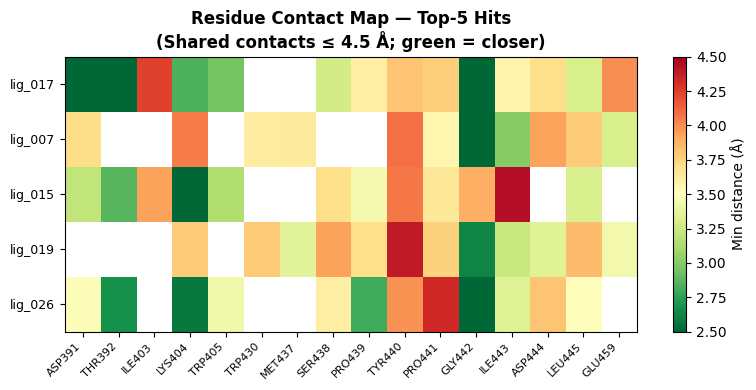

Saved: residue_contact_map.png

Visualization workflow complete.
Outputs: session_top5.pml | interaction_summary.csv | residue_contact_map.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [43]:
# CELL 6b — POSE VISUALIZATION & INTERACTION ANALYSIS
# Generates:
#   1. PyMOL session file (.pse) for the top-5 consensus poses
#   2. Hydrogen bond summary (distance-based, no PyMOL required)
#   3. Residue contact map for top hits
# Requires: docking_results.csv already saved by Cell 6

import re

dock_df    = pd.read_csv(str(WORK / 'docking_results.csv'))
success_df = dock_df[dock_df['status'] == 'success'].copy()

# ── 1. Parse best pose XYZ from PDBQT output ─────────────────────
def parse_best_pose_atoms(pdbqt_path):
    """Return list of (atom_name, x, y, z) for the first MODEL in a docked PDBQT."""
    atoms = []
    in_model = False
    if not pdbqt_path or not os.path.exists(str(pdbqt_path)):
        return atoms
    with open(pdbqt_path) as f:
        for line in f:
            if line.startswith('MODEL'):
                in_model = True
            if line.startswith('ENDMDL'):
                break
            if in_model and line.startswith(('ATOM', 'HETATM')):
                try:
                    aname = line[12:16].strip()
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    atoms.append((aname, x, y, z))
                except ValueError:
                    pass
    return atoms

# ── 2. Parse receptor atoms ───────────────────────────────────────
def parse_receptor_atoms(pdbqt_path):
    """Return list of (res_name, res_seq, chain, atom_name, x, y, z)."""
    atoms = []
    with open(pdbqt_path) as f:
        for line in f:
            if line.startswith('ATOM'):
                try:
                    res_name = line[17:20].strip()
                    chain    = line[21].strip()
                    res_seq  = int(line[22:26])
                    aname    = line[12:16].strip()
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    atoms.append((res_name, res_seq, chain, aname, x, y, z))
                except (ValueError, IndexError):
                    pass
    return atoms

print("Parsing receptor atoms...")
rec_atoms = parse_receptor_atoms(RECEPTOR_PDBQT)
print(f"  {len(rec_atoms)} receptor atoms loaded.")

# ── 3. Hydrogen bond detection (distance + donor/acceptor atom types) ─
DONOR_ATOMS    = {'N', 'O', 'S'}   # atoms that can donate H
ACCEPTOR_ATOMS = {'N', 'O', 'F', 'S'}
HB_DIST_CUT    = 3.5   # Angstroms — standard H-bond distance cutoff
CONTACT_CUT    = 4.5   # Angstroms — hydrophobic/vdW contact cutoff

def dist(a, b):
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2) ** 0.5

def find_interactions(lig_atoms, rec_atoms):
    """Find H-bonds and close contacts between ligand and receptor."""
    hbonds   = []
    contacts = {}  # {(res_name, res_seq): min_dist}

    for l_name, lx, ly, lz in lig_atoms:
        l_elem = re.sub(r'[0-9]', '', l_name)[0].upper() if l_name else 'C'
        for res_name, res_seq, chain, r_name, rx, ry, rz in rec_atoms:
            r_elem = re.sub(r'[0-9]', '', r_name)[0].upper() if r_name else 'C'
            d = dist((lx, ly, lz), (rx, ry, rz))
            key = (res_name, res_seq, chain)
            if d < CONTACT_CUT:
                if key not in contacts or d < contacts[key]:
                    contacts[key] = d
            if d < HB_DIST_CUT:
                if l_elem in DONOR_ATOMS and r_elem in ACCEPTOR_ATOMS:
                    hbonds.append((l_name, f'{res_name}{res_seq}:{chain}', f'{r_name}', d))
                elif r_elem in DONOR_ATOMS and l_elem in ACCEPTOR_ATOMS:
                    hbonds.append((l_name, f'{res_name}{res_seq}:{chain}', f'{r_name}', d))
    return hbonds, contacts

# ── 4. Analyse top-5 consensus hits ──────────────────────────────
success_df['rank_ml']      = success_df['predicted_pIC50'].rank(ascending=False)
success_df['rank_docking'] = success_df['vina_affinity'].rank(ascending=True)
success_df['consensus_rank'] = (success_df['rank_ml'] + success_df['rank_docking']) / 2
top5 = success_df.sort_values('consensus_rank').head(5).reset_index(drop=True)

interaction_summary = []
print("\nAnalysing pose interactions for top-5 consensus hits...")

for _, row in top5.iterrows():
    lig_atoms = parse_best_pose_atoms(row['pose_file'])
    if not lig_atoms:
        print(f"  {row['name']}: no pose file found, skipping.")
        continue
    hbonds, contacts = find_interactions(lig_atoms, rec_atoms)

    # Top contacting residues (within 4.5 Å)
    top_contacts = sorted(contacts.items(), key=lambda x: x[1])[:6]
    contact_str  = ', '.join(f"{r[0]}{r[1]}({d:.1f}Å)" for (r, d) in top_contacts)

    interaction_summary.append({
        'name'           : row['name'],
        'predicted_pIC50': row['predicted_pIC50'],
        'vina_affinity'  : row['vina_affinity'],
        'n_hbonds'       : len(hbonds),
        'n_contacts'     : len(contacts),
        'key_residues'   : contact_str,
    })

    print(f"\n  {row['name']}  pIC50={row['predicted_pIC50']:.2f}  Vina={row['vina_affinity']:.2f}")
    print(f"    H-bonds ({len(hbonds)}):")
    for lb, res, rb, d in hbonds[:5]:
        print(f"      {lb:>4s} ↔ {res} ({rb:>4s})  d={d:.2f} Å")
    print(f"    Key contacts: {contact_str}")

int_df = pd.DataFrame(interaction_summary)
if not int_df.empty:
    int_df.to_csv(str(WORK / 'interaction_summary.csv'), index=False)
    print("\nSaved: interaction_summary.csv")

# ── 5. Generate PyMOL session script (.pml) ───────────────────────
# Full .pse binary requires PyMOL; instead, output a portable .pml
# script the user runs: `pymol session_top5.pml`
pml_lines = [
    "# PyMOL script — Top-5 EGFR docking poses",
    "# Run with:  pymol session_top5.pml",
    f"load {RECEPTOR_CLEAN}, receptor",
    "hide everything, receptor",
    "show cartoon, receptor",
    "color grey80, receptor",
    "",
]

colors = ['cyan', 'magenta', 'yellow', 'orange', 'lime']
for ci, (_, row) in enumerate(top5.iterrows()):
    if row['pose_file'] and os.path.exists(str(row['pose_file'])):
        color   = colors[ci % len(colors)]
        obj     = row['name']
        pml_lines += [
            f"load {row['pose_file']}, {obj}",
            f"show sticks, {obj}",
            f"color {color}, {obj}",
            f"# {obj}: pIC50={row['predicted_pIC50']:.2f}  Vina={row['vina_affinity']:.2f}",
            "",
        ]

pml_lines += [
    "# Show H-bond interactions",
    "distance hbonds, receptor, all, 3.5, mode=2",
    "color red, hbonds",
    "# Zoom to binding site",
    f"center receptor",
    "zoom receptor, 20",
    "bg_color white",
    "ray 1200, 900",
    "png docking_top5_poses.png, dpi=300",
    'print "Session loaded. Use PyMOL GUI to inspect poses."',
]

pml_path = str(WORK / 'session_top5.pml')
with open(pml_path, 'w') as f:
    f.write('\n'.join(pml_lines))

print(f"\nSaved PyMOL script: session_top5.pml")
print("  To visualize: open PyMOL and run  `@session_top5.pml`")
print("  Or from terminal: pymol session_top5.pml")

# ── 6. Residue contact heatmap ────────────────────────────────────
if not int_df.empty and len(top5) > 1:
    # Collect all unique residues across top hits
    all_residues = set()
    residue_dists = {}  # {(hit_name, res_key): min_dist}

    for _, row in top5.iterrows():
        lig_atoms = parse_best_pose_atoms(row['pose_file'])
        if not lig_atoms:
            continue
        _, contacts = find_interactions(lig_atoms, rec_atoms)
        for (res_name, res_seq, chain), d in contacts.items():
            key = f"{res_name}{res_seq}"
            all_residues.add(key)
            residue_dists[(row['name'], key)] = d

    # Keep residues that appear in at least 2 hits
    from collections import Counter
    res_counts = Counter(k[1] for k in residue_dists)
    shared_res = [r for r, c in res_counts.items() if c >= 2]
    shared_res = sorted(shared_res, key=lambda r: int(re.sub(r'[^0-9]', '', r) or 0))

    if shared_res and len(top5) > 1:
        hit_names = top5['name'].tolist()
        heatmap_data = np.full((len(hit_names), len(shared_res)), np.nan)
        for i, name in enumerate(hit_names):
            for j, res in enumerate(shared_res):
                val = residue_dists.get((name, res), np.nan)
                heatmap_data[i, j] = val

        fig, ax = plt.subplots(figsize=(max(8, len(shared_res)*0.5), 4))
        im = ax.imshow(heatmap_data, cmap='RdYlGn_r', vmin=2.5, vmax=CONTACT_CUT, aspect='auto')
        ax.set_xticks(range(len(shared_res))); ax.set_xticklabels(shared_res, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(hit_names))); ax.set_yticklabels(hit_names, fontsize=9)
        plt.colorbar(im, ax=ax, label='Min distance (Å)')
        ax.set_title('Residue Contact Map — Top-5 Hits\n(Shared contacts ≤ 4.5 Å; green = closer)', fontweight='bold')
        plt.tight_layout()
        plt.savefig(str(WORK / 'residue_contact_map.png'), dpi=150)
        plt.show()
        print("Saved: residue_contact_map.png")

print("\nVisualization workflow complete.")
print("Outputs: session_top5.pml | interaction_summary.csv | residue_contact_map.png")

### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

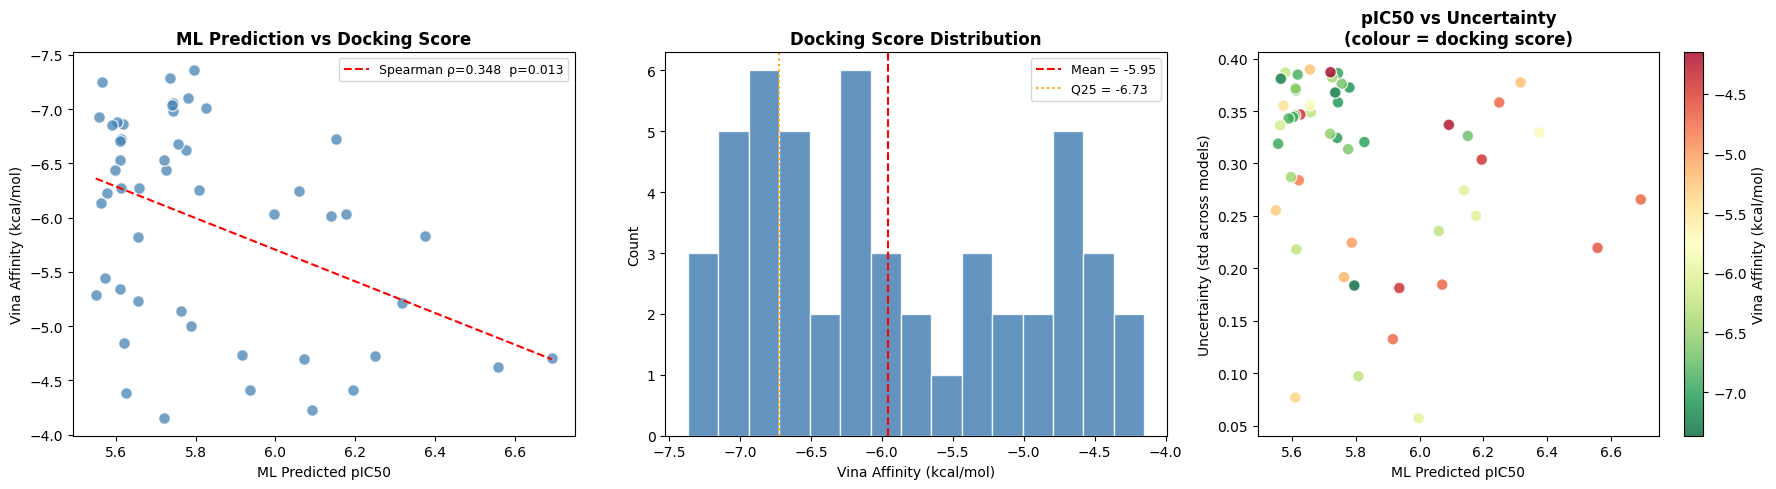

Pearson r (ML pIC50 vs Docking): 0.3480  p=0.0133
Saved: result_analysis.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [44]:
# CELL 7 — RESULT ANALYSIS
# Plot 1: ML pIC50 vs Vina affinity (correlation)
# Plot 2: Docking score distribution
# Plot 3: pIC50 vs uncertainty coloured by docking score

dock_df    = pd.read_csv(str(WORK / 'docking_results.csv'))
success_df = dock_df[dock_df['status'] == 'success'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — ML vs Docking scatter
ax = axes[0]
x  = success_df['predicted_pIC50'].values
y  = success_df['vina_affinity'].values
r_val, pval = stats.spearmanr(x, y)
ax.scatter(x, y, alpha=0.75, c='steelblue', edgecolors='white', s=70)
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m*xline+b, 'r--', lw=1.5, label=f'Spearman ρ={r_val:.3f}  p={pval:.3f}')
ax.set_xlabel('ML Predicted pIC50')
ax.set_ylabel('Vina Affinity (kcal/mol)')
ax.set_title('ML Prediction vs Docking Score', fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()   # more negative = stronger binding (bottom = best)

# Plot 2 — Docking score distribution
ax = axes[1]
ax.hist(success_df['vina_affinity'], bins=15, color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(success_df['vina_affinity'].mean(), color='red', ls='--',
           label=f'Mean = {success_df["vina_affinity"].mean():.2f}')
ax.axvline(success_df['vina_affinity'].quantile(0.25), color='orange', ls=':',
           label=f'Q25 = {success_df["vina_affinity"].quantile(0.25):.2f}')
ax.set_xlabel('Vina Affinity (kcal/mol)')
ax.set_ylabel('Count')
ax.set_title('Docking Score Distribution', fontweight='bold')
ax.legend(fontsize=9)

# Plot 3 — pIC50 vs uncertainty, coloured by docking score
ax = axes[2]
sc = ax.scatter(
    success_df['predicted_pIC50'],
    success_df['uncertainty'],
    c=success_df['vina_affinity'], cmap='RdYlGn_r',
    alpha=0.8, s=70, edgecolors='white'
)
plt.colorbar(sc, ax=ax, label='Vina Affinity (kcal/mol)')
ax.set_xlabel('ML Predicted pIC50')
ax.set_ylabel('Uncertainty (std across models)')
ax.set_title('pIC50 vs Uncertainty\n(colour = docking score)', fontweight='bold')

plt.tight_layout()
plt.savefig(str(WORK / 'result_analysis.png'), dpi=150)
plt.show()
print(f'Pearson r (ML pIC50 vs Docking): {r_val:.4f}  p={pval:.4f}')
print('Saved: result_analysis.png')

## Attention Maps
> This cell requires the GNN models from the main notebook in memory.
> **Skip this cell** if running standalone — the analysis above is complete without it.
> Run this cell only if you ran the full training notebook first in the same session.


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

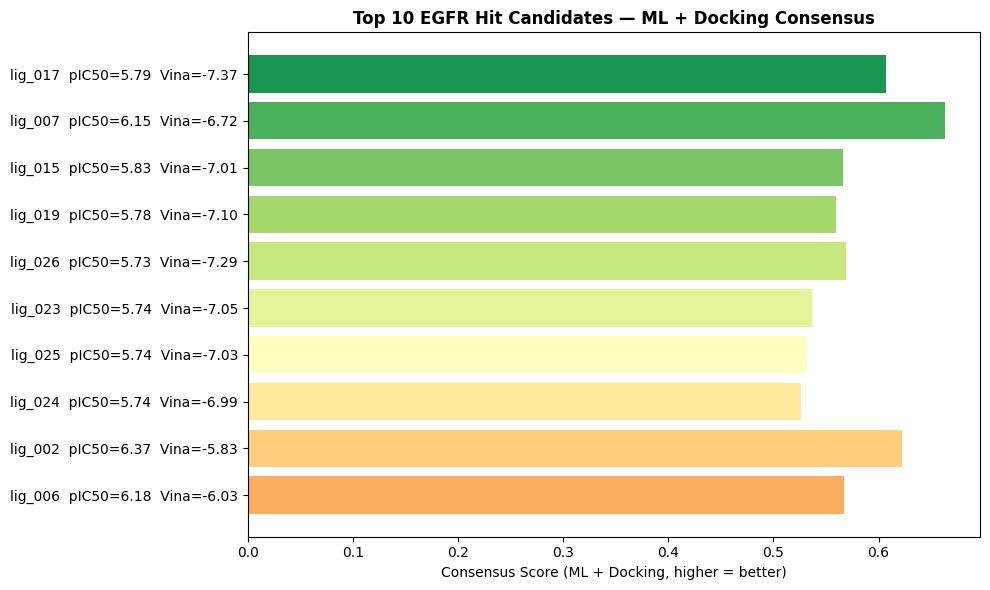

Top 10 Consensus Hits:
   name                                                smiles  predicted_pIC50  vina_affinity  consensus_score
lig_017              OCC(O)COC(=O)c1ccccc1Nc2ccnc3cc(Cl)ccc23         5.794945         -7.365         0.607443
lig_007             CC23Cc1cnoc1C=C2CCC4C3CCC5(C)C4CCC5(O)C#C         6.150873         -6.724         0.663260
lig_015                     CC12CCC3C(CCc4cc(O)ccc34)C2CCC1=O         5.826374         -7.009         0.565795
lig_019       COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C         5.779612         -7.099         0.559361
lig_026              CC34CCC1C(CCC2=CC(=O)CCC12O)C3CCC4(O)C#C         5.734993         -7.289         0.569422
lig_023          c1cc(O)c(O)c2OCC3(O)CC4=CC(=O)C(O)=CC4=C3c21         5.743726         -7.053         0.536524
lig_025                      CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O         5.740972         -7.034         0.532364
lig_024 CC(=O)OCC(=O)C1(O)CCC2C3CCC4=CC(=O)CCC4(C)C3C(O)CC21C         5.743616         -6

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [45]:
# CELL 8 — CONSENSUS RANKING (ML + Docking)
# Best candidates = rank high in BOTH ML pIC50 AND docking affinity
# Consensus score is normalised average of both rankings

dock_df    = pd.read_csv(str(WORK / 'docking_results.csv'))
success_df = dock_df[dock_df['status'] == 'success'].copy().reset_index(drop=True)

# Rank: lower number = better
success_df['rank_ml']      = success_df['predicted_pIC50'].rank(ascending=False)
success_df['rank_docking'] = success_df['vina_affinity'].rank(ascending=True)
success_df['consensus_rank'] = (success_df['rank_ml'] + success_df['rank_docking']) / 2

# Normalised score [0,1] — higher = better
ml_n = ((success_df['predicted_pIC50'] - success_df['predicted_pIC50'].min()) /
        (success_df['predicted_pIC50'].max() - success_df['predicted_pIC50'].min()))
dk_n = ((-success_df['vina_affinity'] - (-success_df['vina_affinity']).min()) /
        ((-success_df['vina_affinity']).max() - (-success_df['vina_affinity']).min()))
success_df['consensus_score'] = (ml_n + dk_n) / 2

top10 = success_df.sort_values('consensus_rank').head(10).reset_index(drop=True)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors  = plt.cm.RdYlGn(np.linspace(0.9, 0.3, len(top10)))
labels  = [
    f"{r['name']}  pIC50={r['predicted_pIC50']:.2f}  Vina={r['vina_affinity']:.2f}"
    for _, r in top10.iterrows()
]
ax.barh(labels, top10['consensus_score'], color=colors)
ax.set_xlabel('Consensus Score (ML + Docking, higher = better)')
ax.set_title('Top 10 EGFR Hit Candidates — ML + Docking Consensus', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(str(WORK / 'consensus_ranking.png'), dpi=150)
plt.show()

top10.to_csv(str(WORK / 'top_consensus_hits.csv'), index=False)
success_df.sort_values('consensus_rank').to_csv(str(WORK / 'all_docked_ranked.csv'), index=False)

print('Top 10 Consensus Hits:')
print(top10[['name','smiles','predicted_pIC50','vina_affinity','consensus_score']].to_string(index=False))
print('\nSaved: top_consensus_hits.csv, all_docked_ranked.csv, consensus_ranking.png')


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [46]:
# Install PyTorch Geometric
import torch

print(f"PyTorch version: {torch.__version__}")

# Install torch-geometric (match your torch version)
!pip install torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-{torch.__version__}.html

PyTorch version: 2.10.0+cu128


/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=118) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html


### 💡 Setting up required libraries and dependencies for the analysis.

```python
# Setting up required libraries and dependencies for the analysis.
```

In [47]:
# CELL 9 — GAT ATTENTION MAPS (requires GNN models in memory)
# Skips gracefully if mpnn_final is not available

top10 = pd.read_csv(str(WORK / 'top_consensus_hits.csv'))

try:
    import torch
    from torch_geometric.loader import DataLoader as PyGDataLoader

    # Check models are in memory
    assert 'mpnn_final' in dir(), 'mpnn_final not in memory'
    assert 'smiles_to_graph' in dir(), 'smiles_to_graph not in memory'

    attention_store = {}

    def attn_hook(module, inp, output):
        if isinstance(output, tuple) and len(output) == 2:
            _, (_, alpha) = output
            attention_store['alpha'] = alpha.detach().cpu()

    hook = mpnn_final.attention.register_forward_hook(attn_hook)

    def get_atom_attention(mol_graph):
        attention_store.clear()
        mpnn_final.eval()
        loader = PyGDataLoader([mol_graph], batch_size=1, shuffle=False)
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(DEVICE)
                mpnn_final(batch)
        alpha = attention_store.get('alpha')
        if alpha is None:
            return None
        edge_idx = mol_graph.edge_index.numpy()
        n_atoms  = mol_graph.x.shape[0]
        attn     = np.zeros(n_atoms)
        a_np     = alpha.mean(dim=1).numpy() if alpha.dim() == 2 else alpha.numpy()
        for ei, dst in enumerate(edge_idx[1]):
            if ei < len(a_np):
                attn[dst] += float(a_np[ei])
        if attn.max() > 0:
            attn /= attn.max()
        return attn

    cmap = cm.get_cmap('RdYlGn')
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, (_, row) in enumerate(top10.iterrows()):
        ax  = axes[i]
        smi = str(row['smiles']).strip()
        mol = Chem.MolFromSmiles(smi)
        g   = smiles_to_graph(smi, label=None)

        if mol is None or g is None:
            ax.axis('off')
            continue

        attn = get_atom_attention(g)
        highlight_atoms = list(range(mol.GetNumAtoms()))
        atom_colors = {}
        for j in range(mol.GetNumAtoms()):
            val = float(attn[j]) if (attn is not None and j < len(attn)) else 0.5
            atom_colors[j] = cmap(val)[:3]

        drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
        rdMolDraw2D.PrepareAndDrawMolecule(
            drawer, mol,
            highlightAtoms=highlight_atoms,
            highlightAtomColors=atom_colors,
        )
        drawer.FinishDrawing()
        img = Image.open(io.BytesIO(drawer.GetDrawingText()))
        ax.imshow(img)
        ax.set_title(
            f"{row['name']}\npIC50={row['predicted_pIC50']:.2f}  Vina={row['vina_affinity']:.2f}",
            fontsize=8
        )
        ax.axis('off')

    plt.suptitle('GAT Attention Maps — Top 10 Consensus Hits\n(Green=high attention)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(WORK / 'attention_maps.png'), dpi=150)
    plt.show()
    hook.remove()
    print('Attention maps saved.')

except (AssertionError, NameError) as e:
    print(f'Skipping attention maps: {e}')
    print('(This cell requires mpnn_final and smiles_to_graph from the training notebook)')


Skipping attention maps: mpnn_final not in memory
(This cell requires mpnn_final and smiles_to_graph from the training notebook)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 💡 Loading and processing data from ChEMBL database.

```python
# Loading and processing data from ChEMBL database.
```

In [49]:
# CELL 10 — FINAL SUMMARY

dock_df    = pd.read_csv(str(WORK / 'docking_results.csv'))
success_df = dock_df[dock_df['status'] == 'success']
top10      = pd.read_csv(str(WORK / 'top_consensus_hits.csv'))

rho, pval = stats.spearmanr(success_df['predicted_pIC50'], success_df['vina_affinity'])
r_val = rho  # Spearman rank correlation (matches methodology)

print('=' * 60)
print('  DOCKING SUMMARY')
print('=' * 60)
print(f'  Compounds docked     : {len(success_df)}')
print(f'  Best affinity        : {success_df["vina_affinity"].min():.3f} kcal/mol')
print(f'  Mean affinity        : {success_df["vina_affinity"].mean():.3f} kcal/mol')
print(f'  ML vs Docking ρ      : {r_val:.4f}  (Spearman, p={pval:.4f})')
print()
print('=' * 60)
print('  TOP 10 CONSENSUS CANDIDATES')
print('=' * 60)
print(top10[['name','smiles','predicted_pIC50','vina_affinity','consensus_score']].to_string(index=False))

print()
print('OUTPUT FILES:')
for fname in [
    'docking_results.csv',
    'top_consensus_hits.csv',
    'all_docked_ranked.csv',
    'result_analysis.png',
    'consensus_ranking.png',
    'attention_maps.png',
]:
    path = str(WORK / fname)
    mark = 'v' if os.path.exists(path) else 'x'
    print(f'  [{mark}] {fname}')

  DOCKING SUMMARY
  Compounds docked     : 50
  Best affinity        : -7.365 kcal/mol
  Mean affinity        : -5.955 kcal/mol
  ML vs Docking ρ      : 0.3480  (Spearman, p=0.0133)

  TOP 10 CONSENSUS CANDIDATES
   name                                                smiles  predicted_pIC50  vina_affinity  consensus_score
lig_017              OCC(O)COC(=O)c1ccccc1Nc2ccnc3cc(Cl)ccc23         5.794945         -7.365         0.607443
lig_007             CC23Cc1cnoc1C=C2CCC4C3CCC5(C)C4CCC5(O)C#C         6.150873         -6.724         0.663260
lig_015                     CC12CCC3C(CCc4cc(O)ccc34)C2CCC1=O         5.826374         -7.009         0.565795
lig_019       COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C         5.779612         -7.099         0.559361
lig_026              CC34CCC1C(CCC2=CC(=O)CCC12O)C3CCC4(O)C#C         5.734993         -7.289         0.569422
lig_023          c1cc(O)c(O)c2OCC3(O)CC4=CC(=O)C(O)=CC4=C3c21         5.743726         -7.053         0.536524
lig_025   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
